# Logic-Based AKI Classification

Due to overlap between AKI and non-AKI clusters, This section returns to the binary AKI classification (0 vs 1) but uses logic-based stratification to isolate patient cohorts with similar clinical profiles, reducing majority-class noise and highlighting critical AKI signals.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel(
    r"C:\Users\n1ck2\Downloads\TPxCGH Project\TPxCGH Project\Final Dataset\CIN_dataset_ALL_v3.xlsx",
    engine="openpyxl"
)

df.shape

c:\Users\n1ck2\anaconda3\envs\mldp\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(25296, 230)

## Patients aged ≥ 60

In [2]:
df_new = df.loc[df['Age'] >= 60]

### Feature Selection & Dimensionality Reduction

In [3]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [4]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean your remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_new.columns))
print("Not found in df_new.columns:", missing)

Not found in df_new.columns: []


In [5]:
df_new = df_new.drop(columns=remove_columns, errors="ignore")

In [6]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 16555 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              16555 non-null  int64  
 1   Patient Ethnicity Code                                           16555 non-null  int64  
 2   Patient Gender                                                   16555 non-null  int64  
 3   Weight                                                           13295 non-null  float64
 4   Height (m)                                                       10838 non-null  float64
 5   BMI                                                              10838 non-null  float64
 6   Procedure_code                                                   16555 non-null  int64  
 7   Contrast type_code                                      

### Preprocessing Data

In [7]:
df_new = df_new.drop_duplicates()

In [8]:
pd.set_option("display.max_columns", None)

df_new


,Age,Patient Ethnicity Code,Patient Gender,Weight,Height (m),BMI,Procedure_code,Contrast type_code,Volume Vial,Patient Type 1inpt 2OutptDaysx 3Emer,Elevated Cr or CKD before scan 0N1Y,"DM code, no DM-0, DM-1","HTN code, no HTN-0, HTN-1","Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1",History of Ca,"Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)","HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)","Hypoalbuminemia No-0, Yes-1, nd-9","Glucose_code: <4_2, 4-11_1, >11_3, nd9","High Lactate- No: 0, Yes:1",High Uric Acid_1,High Thyroxine >14.4_1,"Acidbase pH (<7.35=1, Normal2, >7.45=3, nd9)","Hb notdone9, 11.5-17=1, <8=2, 8-<11.5=3, >17=4)","WBC notdone9, 4-10=1, <4.0=2, >10=3","ProBNPmt300_1, nd9","Proteinuria <=0.5=1, >0.5=2, nd9","CRP <=10=1, >10=2, nd9",ACEi/ARB,Diuretics,NSAIDS,SGLT2i,Calculated baseline creatinine,AKI
0,86,1,1,51.2,1.49,23.1,1,2,65.0,1,0,1,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,65,0
1,88,1,2,42.3,1.60,16.5,1,2,65.0,3,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,88,0
2,72,9,2,NaN,NaN,NaN,1,2,70.0,3,1,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
3,78,3,1,56.3,NaN,NaN,1,2,70.0,1,0,0,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,64,0
5,74,1,2,64.8,1.68,23.0,1,2,70.0,1,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25289,71,3,1,NaN,NaN,NaN,4,2,45.0,3,0,1,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,63,0
25290,76,3,2,58.7,1.66,21.3,1,2,50.0,1,0,0,1,0,0,2,9,1,1,9,9,1,1,1,3,9,9,1,0,0,0,0,86,0
25291,69,1,2,55.0,1.67,19.7,1,2,50.0,2,0,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,84,0
25293,91,1,1,NaN,NaN,NaN,1,2,50.0,1,0,0,0,0,0,3,9,1,1,9,9,0,9,3,3,9,9,1,0,0,0,0,66,0


In [9]:
from sklearn.impute import SimpleImputer

cols = ['Height (m)', 'Weight', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

In [10]:
df_new


,Age,Patient Ethnicity Code,Patient Gender,Weight,Height (m),BMI,Procedure_code,Contrast type_code,Volume Vial,Patient Type 1inpt 2OutptDaysx 3Emer,Elevated Cr or CKD before scan 0N1Y,"DM code, no DM-0, DM-1","HTN code, no HTN-0, HTN-1","Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1",History of Ca,"Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)","HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)","Hypoalbuminemia No-0, Yes-1, nd-9","Glucose_code: <4_2, 4-11_1, >11_3, nd9","High Lactate- No: 0, Yes:1",High Uric Acid_1,High Thyroxine >14.4_1,"Acidbase pH (<7.35=1, Normal2, >7.45=3, nd9)","Hb notdone9, 11.5-17=1, <8=2, 8-<11.5=3, >17=4)","WBC notdone9, 4-10=1, <4.0=2, >10=3","ProBNPmt300_1, nd9","Proteinuria <=0.5=1, >0.5=2, nd9","CRP <=10=1, >10=2, nd9",ACEi/ARB,Diuretics,NSAIDS,SGLT2i,Calculated baseline creatinine,AKI
0,86,1,1,51.2,1.49,23.1,1,2,65.0,1,0,1,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,65,0
1,88,1,2,42.3,1.60,16.5,1,2,65.0,3,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,88,0
2,72,9,2,58.3,1.58,23.6,1,2,70.0,3,1,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
3,78,3,1,56.3,1.58,23.6,1,2,70.0,1,0,0,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,64,0
5,74,1,2,64.8,1.68,23.0,1,2,70.0,1,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25289,71,3,1,58.3,1.58,23.6,4,2,45.0,3,0,1,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,63,0
25290,76,3,2,58.7,1.66,21.3,1,2,50.0,1,0,0,1,0,0,2,9,1,1,9,9,1,1,1,3,9,9,1,0,0,0,0,86,0
25291,69,1,2,55.0,1.67,19.7,1,2,50.0,2,0,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,84,0
25293,91,1,1,58.3,1.58,23.6,1,2,50.0,1,0,0,0,0,0,3,9,1,1,9,9,0,9,3,3,9,9,1,0,0,0,0,66,0


In [ ]:
# Create a new column 'AKI_Risk_Score' based on columns such as creatinine, age, chronic kidney disease, diabetes, hypertension, high cholestrol

'''def calculate_aki_risk_score(row):
    
    score = 0
    gender = str(row.get('Patient Gender', '')) # looks up the gender value, defaulting to an empty string if the key doesn't exist
    baseline_cr = row.get('Calculated baseline creatinine', 0)
    male_creatinine_threshold = 115
    female_creatinine_threshold = 97
    
    
    if (gender == '1' and baseline_cr >= male_creatinine_threshold) or (gender == '2' and baseline_cr >= female_creatinine_threshold):
        score += 20

    if row.get('Elevated Cr or CKD before scan 0N1Y') == 1:
        score += 20
    
    if row.get('DM code, no DM-0, DM-1') == 1:
        score += 15

    if row.get('HTN code, no HTN-0, HTN-1') == 1:
        score += 15

    if row.get('Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1') == 1:
        score += 20

   
    if row.get('HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)') == 3:
        score += 15
    
    return score'''


In [ ]:
'''df_new['AKI_Risk_Score (%)'] = df_new.apply(calculate_aki_risk_score, axis=1)
df_new'''

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, average_precision_score

X_array = X.to_numpy()
y_array = y.to_numpy()


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


fold_no = 1
for train_idx, val_idx in skf.split(X_array, y_array):
    print(f"\n--- Training Fold {fold_no} ---")
    
    # Isolate fold-specific splits
    X_train_fold, X_val_fold = X_array[train_idx], X_array[val_idx]
    y_train_fold, y_val_fold = y_array[train_idx], y_array[val_idx]
    
    
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)
    X_train_fold = np.expand_dims(X_train_fold, axis=-1)
    X_val_fold = np.expand_dims(X_val_fold, axis=-1)
    
    
    # This automatically assigns a higher weight multiplier to Class 1
    classes = np.unique(y_train_fold)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_fold)
    class_weight_dict = dict(zip(classes, weights))
    print(f"Applying Class Weights: {class_weight_dict}")
    
    
    model = Sequential([
        LSTM(64, input_shape=(X_train_fold.shape[1], 1), return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR'), 'accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    
    
    model.fit(X_train_fold, y_train_fold,epochs=30,batch_size=64,validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop],
        class_weight=class_weight_dict,  # Enforces penalty on missed AKI cases
        verbose=1
    )
    
   
    probs = model.predict(X_val_fold).flatten()

    OPTIMAL_THRESHOLD = 0.40  # Fallback boundary
   
    preds = (probs >= OPTIMAL_THRESHOLD).astype(int)
    
    print(f"\nResults for Fold {fold_no}:")
    print(classification_report(y_val_fold, preds))
    print(f"Fold PR-AUC: {average_precision_score(y_val_fold, probs):.4f}")
    
    fold_no += 1




--- Training Fold 1 ---
Applying Class Weights: {np.int64(0): np.float64(0.5363451363451364), np.int64(1): np.float64(7.378499440089586)}
Epoch 1/30


C:\Users\n1ck2\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6388 - loss: 0.6746 - pr_auc: 0.1032 - val_accuracy: 0.6801 - val_loss: 0.6232 - val_pr_auc: 0.1935
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6045 - loss: 0.6562 - pr_auc: 0.1189 - val_accuracy: 0.6719 - val_loss: 0.6134 - val_pr_auc: 0.1920
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6326 - loss: 0.6499 - pr_auc: 0.1266 - val_accuracy: 0.5903 - val_loss: 0.6828 - val_pr_auc: 0.1793
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6343 - loss: 0.6533 - pr_auc: 0.1246 - val_accuracy: 0.6310 - val_loss: 0.6501 - val_pr_auc: 0.1758
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6279 - loss: 0.6509 - pr_auc: 0.1246 - val_accuracy: 0.6270 - val_loss: 0.6578 - val_pr_auc: 0.1867
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6223 - loss: 0.6487 - pr_auc: 0.1227 - val_accuracy: 0.6146 - val_loss: 0.6459 - val_pr_auc: 0.1586
103/103 ━

C:\Users\n1ck2\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6197 - loss: 0.6633 - pr_auc: 0.1183 - val_accuracy: 0.6780 - val_loss: 0.6059 - val_pr_auc: 0.1269
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6452 - loss: 0.6522 - pr_auc: 0.1257 - val_accuracy: 0.6061 - val_loss: 0.6604 - val_pr_auc: 0.1320
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6542 - loss: 0.6473 - pr_auc: 0.1352 - val_accuracy: 0.6522 - val_loss: 0.6428 - val_pr_auc: 0.1308
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6477 - loss: 0.6465 - pr_auc: 0.1359 - val_accuracy: 0.6206 - val_loss: 0.6788 - val_pr_auc: 0.1252
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6355 - loss: 0.6453 - pr_auc: 0.1373 - val_accuracy: 0.7077 - val_loss: 0.6137 - val_pr_auc: 0.1247
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Results for Fold 2:
              precision    recall  f1-score   support

           0       0.97      0.51      0.67      3072
     

...

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5823 - loss: 0.6618 - pr_auc: 0.1162 - val_accuracy: 0.6659 - val_loss: 0.6343 - val_pr_auc: 0.1251
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6342 - loss: 0.6506 - pr_auc: 0.1267 - val_accuracy: 0.6546 - val_loss: 0.6468 - val_pr_auc: 0.1268
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6437 - loss: 0.6468 - pr_auc: 0.1332 - val_accuracy: 0.6476 - val_loss: 0.6706 - val_pr_auc: 0.1213
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6723 - loss: 0.6426 - pr_auc: 0.1341 - val_accuracy: 0.6425 - val_loss: 0.6334 - val_pr_auc: 0.1303
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6553 - loss: 0.6422 - pr_auc: 0.1388 - val_accuracy: 0.6231 - val_loss: 0.6841 - val_pr_auc: 0.1191
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6666 - loss: 0.6421 - pr_auc: 0.1373 - val_accuracy: 0.6255 - val_loss: 0.6648 - val_pr_auc: 0.130

C:\Users\n1ck2\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6116 - loss: 0.6682 - pr_auc: 0.1098 - val_accuracy: 0.6779 - val_loss: 0.6234 - val_pr_auc: 0.1226
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6554 - loss: 0.6534 - pr_auc: 0.1259 - val_accuracy: 0.6029 - val_loss: 0.6878 - val_pr_auc: 0.1345
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6428 - loss: 0.6523 - pr_auc: 0.1251 - val_accuracy: 0.6806 - val_loss: 0.6350 - val_pr_auc: 0.1286
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6425 - loss: 0.6495 - pr_auc: 0.1311 - val_accuracy: 0.6958 - val_loss: 0.6049 - val_pr_auc: 0.1272
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6641 - loss: 0.6497 - pr_auc: 0.1314 - val_accuracy: 0.6415 - val_loss: 0.6599 - val_pr_auc: 0.1404
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6695 - loss: 0.6434 - pr_auc: 0.1420 - val_accuracy: 0.6363 - val_loss: 0.6563 - val_pr_auc: 0.1322
Epoch 7/3

C:\Users\n1ck2\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5945 - loss: 0.6677 - pr_auc: 0.1102 - val_accuracy: 0.6072 - val_loss: 0.7037 - val_pr_auc: 0.1281
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6328 - loss: 0.6527 - pr_auc: 0.1249 - val_accuracy: 0.6661 - val_loss: 0.6295 - val_pr_auc: 0.1312
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6385 - loss: 0.6454 - pr_auc: 0.1379 - val_accuracy: 0.6318 - val_loss: 0.6546 - val_pr_auc: 0.1305
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6366 - loss: 0.6447 - pr_auc: 0.1324 - val_accuracy: 0.6263 - val_loss: 0.6499 - val_pr_auc: 0.1340
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6317 - loss: 0.6453 - pr_auc: 0.1330 - val_accuracy: 0.5914 - val_loss: 0.6582 - val_pr_auc: 0.1306
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6343 - loss: 0.6423 - pr_auc: 0.1337 - val_accuracy: 0.6491 - val_loss: 0.6300 - val_pr_auc: 0.1317
103/103 ━

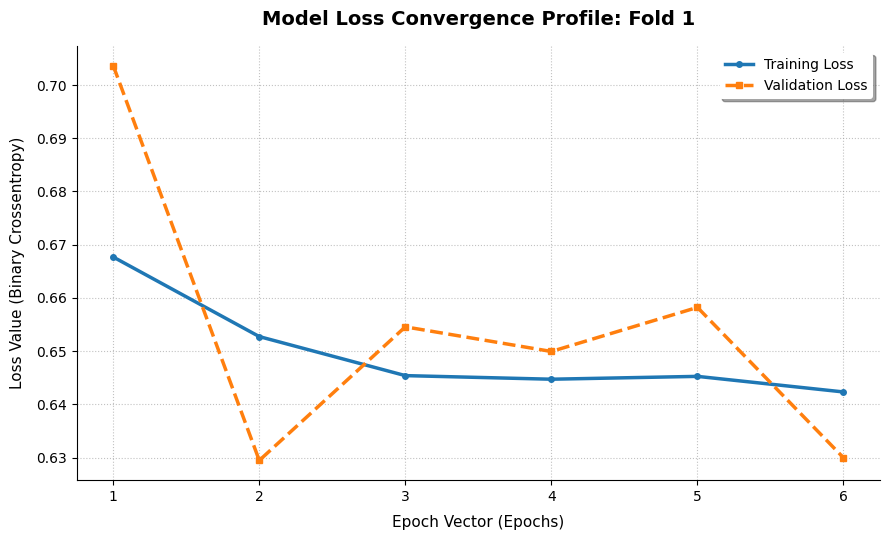

In [ ]:
all_histories = [model.history.history for model in [model]]  # Assuming you have a list of models or histories


for i, hist in enumerate(all_histories, start=1):
    # 1. Initialize a clean, modern figure layout
    plt.figure(figsize=(9, 5.5))
    
    # 2. Extract the actual number of epochs executed (handles Early Stopping)
    epochs_range = range(1, len(hist['loss']) + 1)
    
    # 3. Plot Training and Validation curves with professional visual styling
    plt.plot(epochs_range, hist['loss'], 
             color='#1f77b4', linestyle='-', linewidth=2.5, marker='o', markersize=4,
             label='Training Loss')
    
    plt.plot(epochs_range, hist['val_loss'], 
             color='#ff7f0e', linestyle='--', linewidth=2.5, marker='s', markersize=4,
             label='Validation Loss')
    
    # 4. Enhance typography and layout labels
    plt.title(f'Model Loss Convergence Profile: Fold {i}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epoch Vector (Epochs)', fontsize=11, labelpad=8)
    plt.ylabel('Loss Value (Binary Crossentropy)', fontsize=11, labelpad=8)
    
    # 5. Force precise x-axis integer ticks matching your true epoch count
    plt.xticks(epochs_range)
    
    # 6. Add clean visual anchors (Legend, Grid, and structural spine trimming)
    plt.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True, fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6, color='#999999')
    
    # Remove top and right borders for a cleaner aesthetic
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 7. Render and automatically fix overlapping padding
    plt.tight_layout()
    plt.show()


In [ ]:
# Generate a summary of 5 features (CKD, SGLT2i, NSAIDS, Acei/ARB, Diuretics) with 32 permutations

columns = ['Elevated Cr or CKD before scan 0N1Y', 'SGLT2i', 'NSAIDS', 'ACEi/ARB', 'Diuretics']

#Make a new dataframe like Excel pivot table for patients with AKI and no AKI

summary_df = df_new.groupby(columns)['AKI'].value_counts().unstack(fill_value=0).reset_index() # Unstack the AKI counts into AKI columns (0 and 1)
summary_df

AKI,Elevated Cr or CKD before scan 0N1Y,SGLT2i,NSAIDS,ACEi/ARB,Diuretics,0,1
0,0,0,0,0,0,7873,308
1,0,0,0,0,1,124,15
2,0,0,0,1,0,2253,153
3,0,0,0,1,1,168,30
4,0,0,1,0,0,728,31
5,0,0,1,0,1,5,1
6,0,0,1,1,0,210,10
7,0,0,1,1,1,15,2
8,0,1,0,0,0,100,3
9,0,1,0,0,1,12,1


In [ ]:
# Create a second summary with CKD, hypertension, diabetes, high cholestrol, and cardiovascular disease

# Slide right to see the full code

# The aggregate function calculates sum and count of AKI, reset_index() is used to convert the groupby object to a DataFrame

summary_df_2 = df_new.groupby(['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'HTN code, no HTN-0, HTN-1', 
                               'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']).agg({'AKI':['sum', 'count']}).reset_index()


summary_df_2

Elevated Cr or CKD before scan 0N1Y DM code, no DM-0, DM-1  \
                                                                
0                                    0                      0   
1                                    0                      0   
2                                    0                      0   
3                                    0                      0   
4                                    0                      0   
5                                    0                      0   
6                                    0                      0   
7                                    0                      0   
8                                    0                      0   
9                                    0                      0   
10                                   0                      0   
11                                   0                      0   
12                                   0                      0   
13                                   0                      0   
14                                   0                      0   
15                                   0                      0   
16                                   0                      1   
17                                   0                      1   
18                                   0                      1   
19                                   0                      1   
20                                   0                      1   
21                                   0                      1   
22                                   0                      1   
23                                   0                      1   
24                                   0                      1   
25                                   0                      1   
26                                   0                      1   
27                                   0                      1   
28                                   0                      1   
29                                   0                      1   
30                                   1                      0   
31                                   1                      0   
32                                   1                      0   
33                                   1                      0   
34                                   1                      0   
35                                   1                      0   
36                                   1                      0   
37                                   1                      0   
38                                   1                      0   
39                                   1                      0   
40                                   1                      0   
41                                   1                      0   
42                                   1                      0   
43                                   1                      0   
44                                   1                      0   
45                                   1                      1   
46                                   1                      1   
47                                   1                      1   
48                                   1                      1   
49                                   1                      1   
50                                   1                      1   
51                                   1                      1   
52                                   1                      1   
53                                   1                      1   
54                                   1                      1   
55                                   1                      1   
56                                   1                      1   
57                                   1                      1   
58                                   1                      1   

   HTN code, no HTN-0, HTN-1  \
     

### Baseline Model

In [11]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_new['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_new.drop(columns=['AKI'])

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [13]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_new.columns if col != target_col]

In [14]:
import tabpfn_client
from tabpfn_client import set_access_token, TabPFNClassifier # init to hide API key
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, average_precision_score

API_TOKEN = "tabpfn_sk_5oVSyolIgBSgi0PHoB6ybSSU0ZFMp3sm6BSbcfgdxWw"
tabpfn_client.set_access_token(API_TOKEN)

tabpfn_model = TabPFNClassifier(balance_probabilities=True, n_estimators=8)
tabpfn_model.fit(X_train, y_train)

predictions = tabpfn_model.predict(X_test)
probabilities = tabpfn_model.predict_proba(X_test)
tabpfn_pr_auc = average_precision_score(y_test, probabilities[:, 1])

print("TabPFN Classification Report:")
print(classification_report(y_test, predictions))
print(f"TabPFN PR-AUC: {tabpfn_pr_auc:.4f}")

00:00 Fitting... |

The provided train set hashes match previously uploaded train sets.


00:04 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
TabPFN Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      1536
           1       0.15      0.54      0.23       112

    accuracy                           0.75      1648
   macro avg       0.55      0.65      0.54      1648
weighted avg       0.90      0.75      0.81      1648

TabPFN PR-AUC: 0.1604


00:00 Predicting... -

00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!


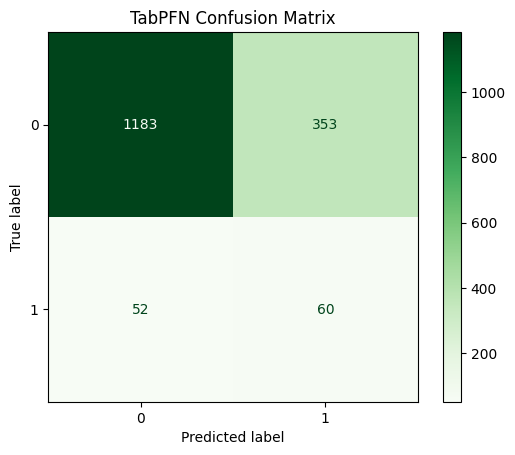

In [15]:
tabpfn_cm = ConfusionMatrixDisplay.from_estimator(tabpfn_model, X_test, y_test, display_labels=[0, 1], cmap=plt.cm.Greens)
plt.title("TabPFN Confusion Matrix")
plt.show()

In [16]:
import numpy as np
from sklearn.metrics import fbeta_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

base_tabpfn = tabpfn_model 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# This calculates probabilities for every sample when it was in the test fold
y_probas = cross_val_predict(base_tabpfn, X, y, cv=skf, method='predict_proba')

# Isolate the probabilities for the positive minority class (column 1)
positive_probs = y_probas[:, 1]

# Find the threshold that yields the best F2 score
# On imbalanced data, the default 0.5 threshold rarely yields the best F2 score
best_threshold = 0.5
best_f2_score = 0.0

for threshold in np.linspace(0.01, 0.99, 100):
    # Convert probabilities to binary predictions based on the shifting threshold
    current_preds = (positive_probs >= threshold).astype(int)
    current_f2 = fbeta_score(y, current_preds, beta=2, average='binary')
    
    if current_f2 > best_f2_score:
        best_f2_score = current_f2
        best_threshold = threshold


default_preds = (positive_probs >= 0.5).astype(int)
default_f2 = fbeta_score(y, default_preds, beta=2, average='binary') # average='binary' is used for binary classification

print(f"\n--- TabPFN Base Model Validation Results ---")
print(f"Default Threshold (0.50) F2 Score: {default_f2:.4f}")
print(f"Optimised Threshold ({best_threshold:.2f}) F2 Score: {best_f2_score:.4f}")



00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:04 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:04 Predicting... Done!
00:00 Fitting... \

...

00:03 Predicting... Done!
00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:02 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!

--- TabPFN Base Model Validation Results ---
Default Threshold (0.50) F2 Score: 0.3719
Optimised Threshold (0.45) F2 Score: 0.3772


In [17]:
from sklearn.base import BaseEstimator, ClassifierMixin # these are the base classes for scikit-learn estimators

class ThresholdOptimizedTabPFN(BaseEstimator, ClassifierMixin):
    def __init__(self, base_model, threshold=0.5):
        self.base_model = base_model
        self.threshold = threshold
        self.classes_ = np.array([0, 1])
        
    def fit(self, X, y):
        # Fit the TabPFN client model on the full training set
        self.base_model.fit(X, y)
        return self
        
    def predict_proba(self, X):
        # Return standard raw probabilities from the client
        return self.base_model.predict_proba(X)
        
    def predict(self, X):
        # Extract positive class probabilities
        probas = self.predict_proba(X)[:, 1]
        # Apply the optimized decision boundary instead of 0.5
        return (probas >= self.threshold).astype(int)


In [18]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, average_precision_score


# Instantiate the newly developed model with your optimal threshold
optimized_tabpfn = ThresholdOptimizedTabPFN(base_model=tabpfn_model, threshold=best_threshold)

X_new = df_new.drop(columns=[target_col])
Y_new = df_new[target_col]

#Fit the final model on your ENTIRE training dataset 
print("Training the final optimized model on full dataset...")
optimized_tabpfn.fit(X_new, Y_new)


new_predictions = optimized_tabpfn.predict(X_test)
new_probabilities = optimized_tabpfn.predict_proba(X_test)
pr_auc = average_precision_score(y_test, new_probabilities[:, 1], pos_label=1)

print(f"\n--- New TabPFN Classifer Model Classification Report ---")
print(classification_report(y_test, new_predictions))
print(f"Precision Recall Score (AUC): {pr_auc:.4f}")


Training the final optimized model on full dataset...
00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:04 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
00:00 Predicting... |

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!

--- New TabPFN Classifer Model Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1536
           1       0.18      0.79      0.30       112

    accuracy                           0.75      1648
   macro avg       0.58      0.77      0.57      1648
weighted avg       0.93      0.75      0.81      1648

Precision Recall Score (AUC): 0.4524


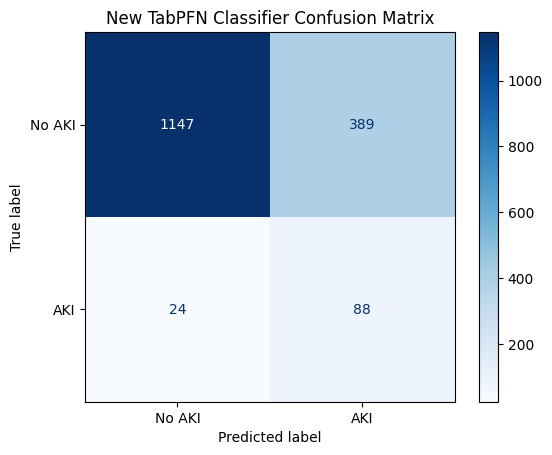

In [19]:
conf_matrix = ConfusionMatrixDisplay.from_predictions(y_test, new_predictions, display_labels=["No AKI", "AKI"], cmap="Blues")
plt.title("New TabPFN Classifier Confusion Matrix")
plt.show()

In [20]:
import joblib

joblib.dump(optimized_tabpfn, "optimized_tabpfn_model.pkl")
print("Saved fitted TabPFN model and optimised threshold!")


Saved fitted TabPFN model and optimised threshold!


In [20]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


# Undersample the majority class to balance the dataset

X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X, y)

under_cv_pipeline = Pipeline([
    ('under', RandomUnderSampler(random_state=42)),
    ('tabpfn', TabPFNClassifier())
])

under_cv_pipeline.fit(X_under, y_under)

new_under_predictions = under_cv_pipeline.predict(X_test)
new_under_probabilities = under_cv_pipeline.predict_proba(X_test)
new_under_pr_auc = average_precision_score(y_test, new_under_predictions, pos_label=1)

print(f"\n--- New Under-sampled TabPFN Classifer Model Classification Report ---")
print(classification_report(y_test, new_under_predictions))
print(f"Precision Recall Score (AUC): {new_under_pr_auc:.4f}")


00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:02 Fitting... Done!
00:04 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!

--- New Under-sampled TabPFN Classifer Model Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.69      0.81      1536
           1       0.15      0.73      0.25       112

    accuracy                           0.69      1648
   macro avg       0.56      0.71      0.53      1648
weighted avg       0.92      0.69      0.77      1648

Precision Recall Score (AUC): 0.1260


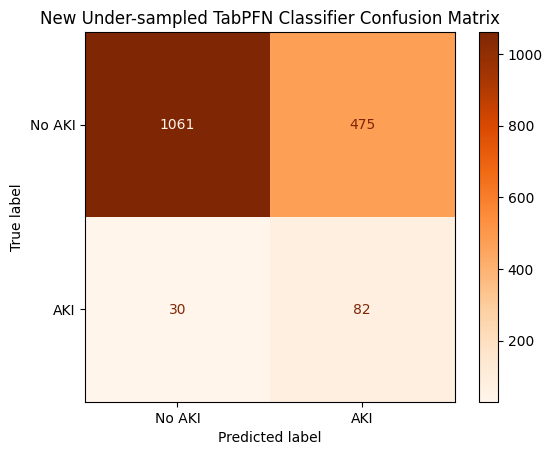

In [22]:
under_conf_matrix = ConfusionMatrixDisplay.from_predictions(y_test, new_under_predictions, display_labels=["No AKI", "AKI"], cmap="Oranges")
plt.title("New Under-sampled TabPFN Classifier Confusion Matrix")
plt.show()

In [ ]:
from itertools import combinations

features = ['Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'NSAIDS', 'SGLT2i', 'Diuretics']

feature_subsets = []

for col in range(1, len(features) + 1):
    for subset in combinations(features, col):
        feature_subsets.append(subset)


print("Number of subsets:", len(feature_subsets))

for i, subset in enumerate(feature_subsets, 1):
    print(i, subset)

Number of subsets: 31
1 ('Elevated Cr or CKD before scan 0N1Y',)
2 ('ACEi/ARB',)
3 ('NSAIDS',)
4 ('SGLT2i',)
5 ('Diuretics',)
6 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB')
7 ('Elevated Cr or CKD before scan 0N1Y', 'NSAIDS')
8 ('Elevated Cr or CKD before scan 0N1Y', 'SGLT2i')
9 ('Elevated Cr or CKD before scan 0N1Y', 'Diuretics')
10 ('ACEi/ARB', 'NSAIDS')
11 ('ACEi/ARB', 'SGLT2i')
12 ('ACEi/ARB', 'Diuretics')
13 ('NSAIDS', 'SGLT2i')
14 ('NSAIDS', 'Diuretics')
15 ('SGLT2i', 'Diuretics')
16 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'NSAIDS')
17 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'SGLT2i')
18 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'Diuretics')
19 ('Elevated Cr or CKD before scan 0N1Y', 'NSAIDS', 'SGLT2i')
20 ('Elevated Cr or CKD before scan 0N1Y', 'NSAIDS', 'Diuretics')
21 ('Elevated Cr or CKD before scan 0N1Y', 'SGLT2i', 'Diuretics')
22 ('ACEi/ARB', 'NSAIDS', 'SGLT2i')
23 ('ACEi/ARB', 'NSAIDS', 'Diuretics')
24 ('ACEi/ARB', 'SGLT2i', 'Diureti

<b> Logistic Regression </b>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = ["Age", "Weight", "Height (m)", "BMI", "Volume Vial", "Calculated baseline creatinine"]
categorical_features = [col for col in features_list if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [ ]:
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Weight',
                                                   'Height (m)', 'BMI',
                                                   'Volume Vial',
                                                   'Calculated baseline '
                                                   'creatinine']),
                                                 ('cat', 'passthrough',
                                                  ['Patient Ethnicity Code',
                                                   'Patient Gender',
                                                   'Procedure_code',
                                                   'Contrast type_code',
                                                   'Patient Ty...
                                                   'High Thyroxine >14.4_1',
                                                   'Acidbase pH (<7.35=1, '
                                                   'Normal2, >7.45=3, nd9)',
                                                   'Hb notdone9, 11.5-17=1, '
                                                   '<8=2, 8-<11.5=3, >17=4)',
                                                   'WBC notdone9, 4-10=1, '
                                                   '<4.0=2, >10=3',
                                                   'ProBNPmt300_1, nd9',
                                                   'Proteinuria <=0.5=1, '
                                                   '>0.5=2, nd9',
                                                   'CRP <=10=1, >10=2, nd9',
                                                   'ACEi/ARB', 'Diuretics',
                                                   'NSAIDS', 'SGLT2i'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report

def show_cm(model, X, y, title="Confusion Matrix"):
    cm = confusion_matrix(y, model.predict(X))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("LogReg (VAL)")
print(classification_report(y_val, logreg_pipe.predict(X_val)))

LogReg (VAL)
              precision    recall  f1-score   support

           0       0.97      0.70      0.81      2150
           1       0.14      0.65      0.22       156

    accuracy                           0.69      2306
   macro avg       0.55      0.68      0.52      2306
weighted avg       0.91      0.69      0.77      2306



In [ ]:
from sklearn.metrics import classification_report

print("LogReg (TEST)")
print(classification_report(y_test, logreg_pipe.predict(X_test)))

LogReg (TEST)
              precision    recall  f1-score   support

           0       0.96      0.69      0.80       922
           1       0.13      0.63      0.21        67

    accuracy                           0.68       989
   macro avg       0.54      0.66      0.51       989
weighted avg       0.91      0.68      0.76       989



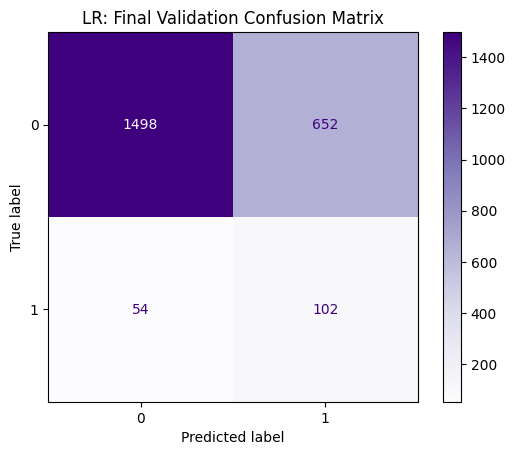

In [ ]:
y_pred_val = logreg_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Validation Confusion Matrix")
plt.show()

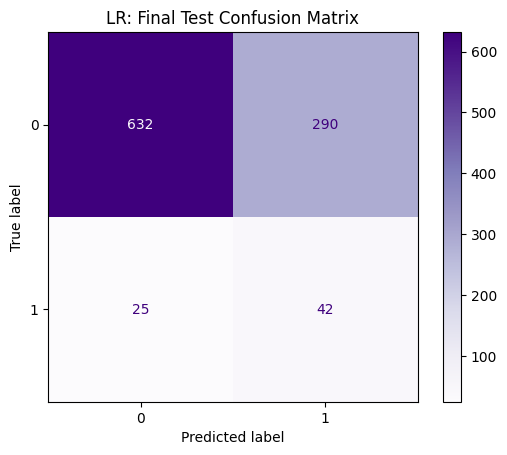

In [ ]:
y_pred_test = logreg_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Test Confusion Matrix")
plt.show()

<b> Decision Tree </b>

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    # Encode categories (1, 2, 3) as numbers for the tree logic
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("dt", DecisionTreeClassifier(
        criterion="gini",          # Or "entropy" to measure information gain
        max_depth=5,               # Keep it shallow so you can read the rules
        min_samples_leaf=10,       # Prevents the tree from creating a rule for 1-2 patients
        class_weight="balanced",   # CRITICAL: Fixes the 0.02 recall issue
        random_state=42
    ))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("DT (VAL)")
print(classification_report(y_val, dt_pipe.predict(X_val)))

DT (VAL)
              precision    recall  f1-score   support

           0       0.96      0.72      0.82      2150
           1       0.13      0.58      0.21       156

    accuracy                           0.71      2306
   macro avg       0.54      0.65      0.52      2306
weighted avg       0.90      0.71      0.78      2306



In [ ]:
from sklearn.metrics import classification_report

print("DT (TEST)")
print(classification_report(y_test, dt_pipe.predict(X_test)))

DT (TEST)
              precision    recall  f1-score   support

           0       0.95      0.70      0.81       922
           1       0.11      0.52      0.18        67

    accuracy                           0.69       989
   macro avg       0.53      0.61      0.49       989
weighted avg       0.90      0.69      0.76       989



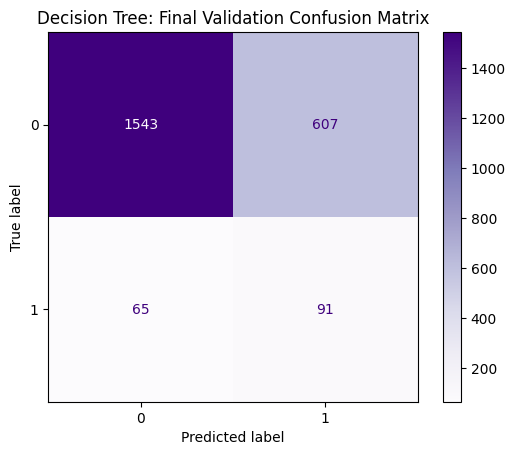

In [ ]:
y_pred_val = dt_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Validation Confusion Matrix")
plt.show()

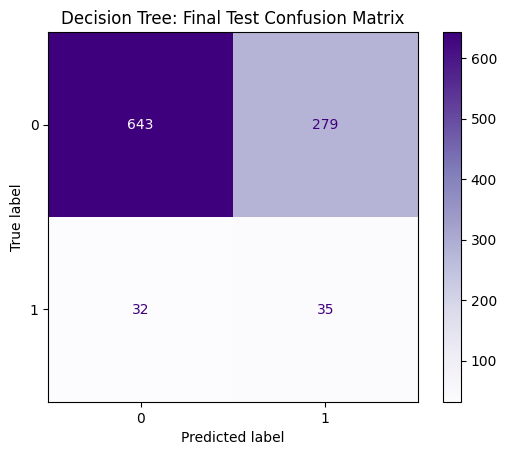

In [ ]:
y_pred_test = dt_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Test Confusion Matrix")
plt.show()

<b> Gradient Boosting </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()


continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 27 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Identify which columns need encoding (the cat_features we found earlier)
# Ensure these match your "cleaned" column names (lt_, gt_)
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'category' or X_train[col].dtype == 'object']

gb_pipe = Pipeline([
    # Encode clinical categories (1, 2, 3) so GBM can read them
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,         # Increased slightly to capture medical complexity
        subsample=0.8,       # Helps prevent overfitting
        random_state=42
    ))
])

# Calculate weights to force the model to care about Moderate/Severe classes
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit the pipeline using the weights
# Note: 'model__' prefix tells the pipeline to pass weights to the GBM stage
gb_pipe.fit(X_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, gb_pipe.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      1536
           1       0.17      0.53      0.26       111

    accuracy                           0.80      1647
   macro avg       0.57      0.67      0.57      1647
weighted avg       0.91      0.80      0.84      1647



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, gb_pipe.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      1536
           1       0.13      0.38      0.20       112

    accuracy                           0.79      1648
   macro avg       0.54      0.60      0.54      1648
weighted avg       0.89      0.79      0.83      1648



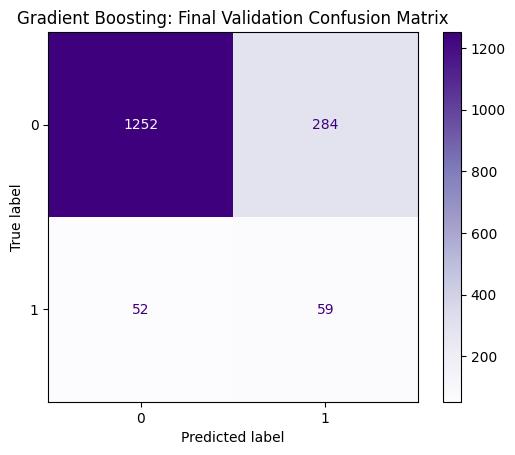

In [ ]:
y_pred_val = gb_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Validation Confusion Matrix")
plt.show()

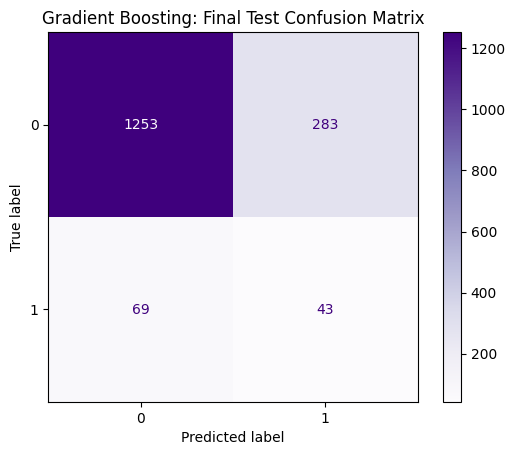

In [ ]:
y_pred_test = gb_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Test Confusion Matrix")
plt.show()

<b> XGB </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 27 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Calculate weights for each row in the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the XGBoost Classifier for BINARY tasks
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',  # Changed for Binary Logic
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

# 3. Fit with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

print("XGB (VAL)")
print(classification_report(y_val, xgb_model.predict(X_val)))

XGB (VAL)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1536
           1       0.16      0.17      0.17       111

    accuracy                           0.89      1647
   macro avg       0.55      0.55      0.55      1647
weighted avg       0.89      0.89      0.89      1647



In [ ]:
from sklearn.metrics import classification_report

print("XGB (TEST)")
print(classification_report(y_test, xgb_model.predict(X_test)))

XGB (TEST)
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1536
           1       0.18      0.15      0.16       112

    accuracy                           0.89      1648
   macro avg       0.56      0.55      0.55      1648
weighted avg       0.89      0.89      0.89      1648



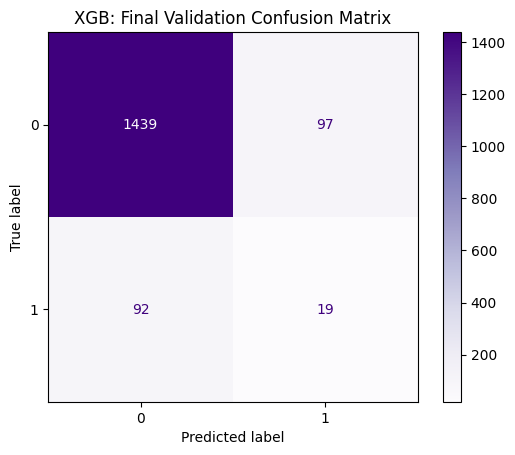

In [ ]:
y_pred_val = xgb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Validation Confusion Matrix")
plt.show()

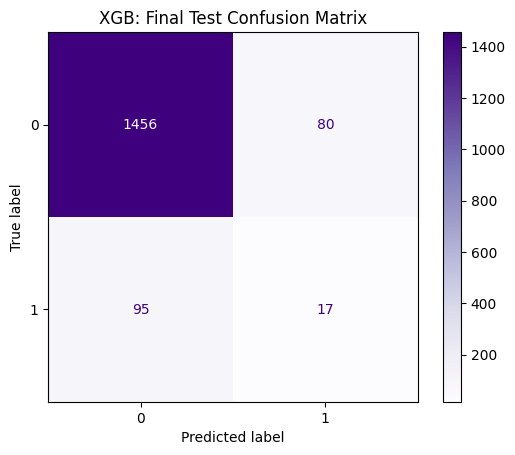

In [ ]:
y_pred_test = xgb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Test Confusion Matrix")
plt.show()

<b> CatBoost </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 27 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.97      0.71      0.82      1536
           1       0.14      0.66      0.23       111

    accuracy                           0.71      1647
   macro avg       0.55      0.68      0.53      1647
weighted avg       0.91      0.71      0.78      1647



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.96      0.68      0.80      1536
           1       0.12      0.57      0.19       112

    accuracy                           0.67      1648
   macro avg       0.54      0.63      0.49      1648
weighted avg       0.90      0.67      0.75      1648



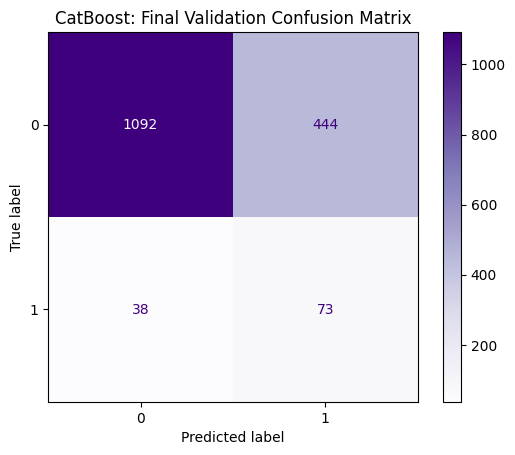

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

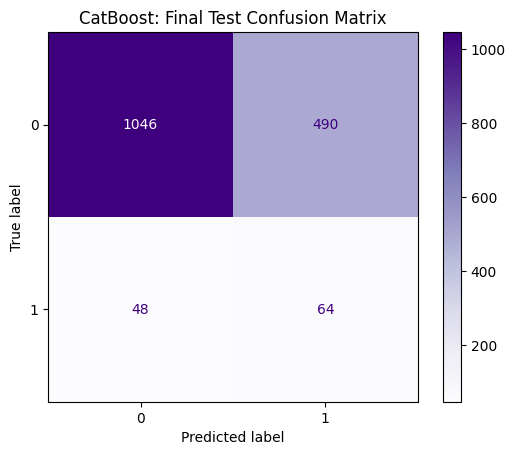

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

<b> Traditional Correlation and Mutual Information </b>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Prepare a copy to avoid modifying original data
df_imputed = df_new.copy()

# 2. Define column groups
continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

# 3. Apply Imputation ONLY to Continuous Columns
# This replaces NaN with the Median, but ignores 'nd9' in categorical columns
cont_imputer = SimpleImputer(strategy='median')
df_imputed[continuous_cols] = cont_imputer.fit_transform(df_imputed[continuous_cols])

# 4. Prepare X and y
X = df_imputed.drop(columns=['AKI'])
y = df_imputed['AKI']

# 5. Update Discrete Mask based on X columns
# This tells MI which columns are labels (Categorical)
discrete_mask = [col not in continuous_cols for col in X.columns]

# 6. Calculate MI Scores
mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 7. Rank MI Results
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

# 8. Rank Correlation Results
correlations = X.corrwith(y).abs()
corr_results = pd.DataFrame({
    'Feature': X.columns,
    'Absolute Correlation': correlations.values
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

# --- Results ---
print("--- MI RESULTS (Imputed Continuous, Original Categorical) ---")
pd.set_option("display.max_rows", None)
print(mi_results)
print('\n')

print("--- Corr RESULTS (Imputed Continuous, Original Categorical) ---")
pd.set_option("display.max_rows", None)  
print(corr_results)

--- MI RESULTS (Imputed Continuous, Original Categorical) ---
                                              Feature  MI Score
0                 Elevated Cr or CKD before scan 0N1Y  0.009475
1   Cardiovascular disease (PVD or IHD or CVA): Ab...  0.004501
2                                  ProBNPmt300_1, nd9  0.004450
3        Acidbase pH (<7.35=1, Normal2, >7.45=3, nd9)  0.003511
4                                          Height (m)  0.003009
5                                                 BMI  0.002820
6                              DM code, no DM-0, DM-1  0.002699
7                                         Volume Vial  0.002571
8     Hb notdone9, 11.5-17=1, <8=2, 8-<11.5=3, >17=4)  0.002529
9   Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=1...  0.002354
10                                          Diuretics  0.001669
11                                     Procedure_code  0.001665
12                                           ACEi/ARB  0.001644
13                          HTN code, no H

In [ ]:
from sklearn.metrics import classification_report, average_precision_score, precision_score
from sklearn.model_selection import cross_val_predict

# Feature selection and index alignment 
selected_feature_list = list(set(mi_results['Feature'].head(20).tolist() + corr_results['Feature'].head(20).tolist()))
X_selected = X[selected_feature_list]
Y_selected = y[X_selected.index]

# Use custom threshold wrapper model
tabpfn_model_selected = optimized_tabpfn  

# Use cross_val_predict to get clean out-of-fold predictions
print("Generating out-of-fold cross-validated predictions...")
cv_predictions = cross_val_predict(tabpfn_model_selected, X_selected, Y_selected, cv=skf, method='predict')
cv_probabilities = cross_val_predict(tabpfn_model_selected, X_selected, Y_selected, cv=skf, method='predict_proba')
pr_auc_selected = average_precision_score(Y_selected, cv_probabilities[:, 1])

print(f"\n--- TabPFN Selected Features Model CV Report ---")
print(classification_report(Y_selected, cv_predictions))
print(f"Precision Recall Score (AUC): {pr_auc_selected:.4f}")


Generating out-of-fold cross-validated predictions...
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:04 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
00:00 Fitting... \

...

00:04 Predicting... Done!
00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:04 Fitting... Done!
00:00 Predicting... |

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!

--- TabPFN Selected Features Model CV Report ---
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     15357
           1       0.14      0.61      0.23      1116

    accuracy                           0.72     16473
   macro avg       0.55      0.67      0.53     16473
weighted avg       0.91      0.72      0.79     16473

Precision Recall Score (AUC): 0.1740


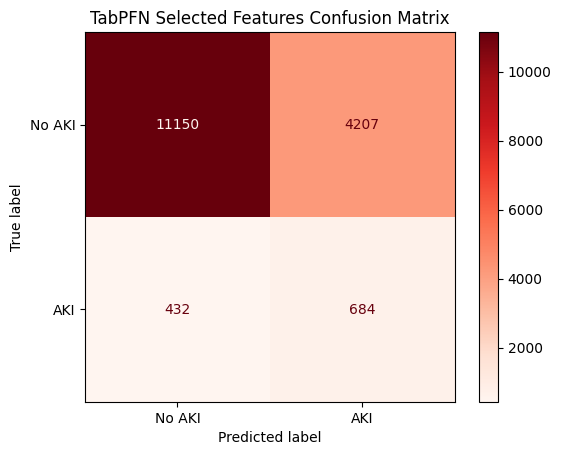

In [ ]:
selected_tabpfn_conf_matrix = ConfusionMatrixDisplay.from_predictions(Y_selected, cv_predictions, display_labels=["No AKI", "AKI"], cmap="Reds")
plt.title("TabPFN Selected Features Confusion Matrix")
plt.show()

### Experiment b: Null-Equivalent Placeholder Removal

<b>Description:</b> This test focuses on the "label noise" generated by medical placeholders that do not represent true physiological measurements.

<b>Methodology:</b> Features containing '9' (indicating unknown values) were excluded from the dataset to ensure the model was trained exclusively on the two newly engineered, logic-based clinical datasets.

In [ ]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 16473 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              16473 non-null  int64  
 1   Patient Ethnicity Code                                           16473 non-null  int64  
 2   Patient Gender                                                   16473 non-null  int64  
 3   Weight                                                           16473 non-null  float64
 4   Height (m)                                                       16473 non-null  float64
 5   BMI                                                              16473 non-null  float64
 6   Procedure_code                                                   16473 non-null  int64  
 7   Contrast type_code                                      

In [ ]:
nd9_percentage = (df_new == 9).mean() * 100

# Filter for only those columns that contain any 'nd9' codes
nd9_report = nd9_percentage[nd9_percentage > 0].sort_values(ascending=False)

print("Percentage of 'nd9' codes per column:")
print(nd9_report)

Percentage of 'nd9' codes per column:
High Uric Acid_1                                                 96.655133
Proteinuria lt_=0.5=1, gt_0.5=2, nd9                             94.275481
High Lactate- No: 0, Yes:1                                       90.208220
Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)                 82.662539
ProBNPmt300_1, nd9                                               81.970497
HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)               77.071572
High Thyroxine gt_14.4_1                                         60.632550
Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)    52.716567
CRP lt_=10=1, gt_10=2, nd9                                       45.225521
Hypoalbuminemia No-0, Yes-1, nd-9                                29.150732
Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)            20.312026
WBC notdone9, 4-10=1, lt_4.0=2, gt_10=3                          20.312026
Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9                    

In [ ]:
# List the columns you want to remove
cols_to_drop = [
    'High Uric Acid_1', 
    'High Lactate- No: 0, Yes:1', 
    'ProBNPmt300_1, nd9', 
    'Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)' , 
    'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)',
    'Proteinuria lt_=0.5=1, gt_0.5=2, nd9'
]



# Drop them from your dataframe
df_experiment = df_new.drop(columns=cols_to_drop)

print(f"Remaining columns: {df_experiment.shape[1]}")

Remaining columns: 28


In [ ]:
df_experiment.info()

<class 'pandas.DataFrame'>
Index: 16473 entries, 0 to 25294
Data columns (total 28 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              16473 non-null  int64  
 1   Patient Ethnicity Code                                           16473 non-null  int64  
 2   Patient Gender                                                   16473 non-null  int64  
 3   Weight                                                           16473 non-null  float64
 4   Height (m)                                                       16473 non-null  float64
 5   BMI                                                              16473 non-null  float64
 6   Procedure_code                                                   16473 non-null  int64  
 7   Contrast type_code                                      

### Model Development and Evaluation

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_experiment['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_experiment.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_experiment.columns if col != target_col]

<b> Logistic Regression </b>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = ["Age", "Weight", "Height (m)", "BMI", "Volume Vial", 'Calculated baseline creatinine']
categorical_features = [col for col in features_list if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [ ]:
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Weight',
                                                   'Height (m)', 'BMI',
                                                   'Volume Vial',
                                                   'Calculated baseline '
                                                   'creatinine']),
                                                 ('cat', 'passthrough',
                                                  ['Patient Ethnicity Code',
                                                   'Patient Gender',
                                                   'Procedure_code',
                                                   'Contrast type_code',
                                                   'Patient Type 1inpt '
                                                   '2OutptDaysx 3Emer',
                                                   'Elevated Cr or CKD be...
                                                   'Hypoalbuminemia No-0, '
                                                   'Yes-1, nd-9',
                                                   'Glucose_code: lt_4_2, '
                                                   '4-11_1, gt_11_3, nd9',
                                                   'High Thyroxine gt_14.4_1',
                                                   'Hb notdone9, 11.5-17=1, '
                                                   'lt_8=2, 8-lt_11.5=3, '
                                                   'gt_17=4)',
                                                   'WBC notdone9, 4-10=1, '
                                                   'lt_4.0=2, gt_10=3',
                                                   'CRP lt_=10=1, gt_10=2, nd9',
                                                   'ACEi/ARB', 'Diuretics',
                                                   'NSAIDS', 'SGLT2i'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("LogReg (VAL)")
print(classification_report(y_val, logreg_pipe.predict(X_val)))

LogReg (VAL)
              precision    recall  f1-score   support

           0       0.96      0.70      0.81      1536
           1       0.13      0.65      0.22       111

    accuracy                           0.70      1647
   macro avg       0.55      0.67      0.52      1647
weighted avg       0.91      0.70      0.77      1647



In [ ]:
from sklearn.metrics import classification_report

print("LogReg (TEST)")
print(classification_report(y_test, logreg_pipe.predict(X_test)))

LogReg (TEST)
              precision    recall  f1-score   support

           0       0.96      0.67      0.79      1536
           1       0.12      0.59      0.19       112

    accuracy                           0.67      1648
   macro avg       0.54      0.63      0.49      1648
weighted avg       0.90      0.67      0.75      1648



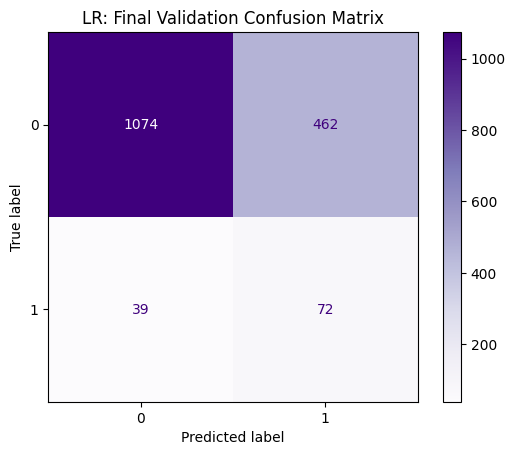

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_val = logreg_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Validation Confusion Matrix")
plt.show()

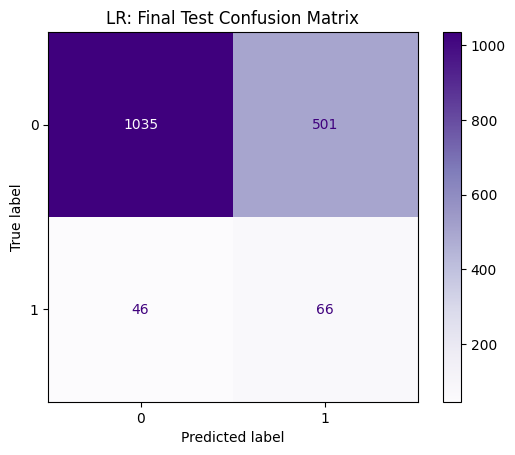

In [ ]:
y_pred_test = logreg_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Test Confusion Matrix")
plt.show()

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_experiment['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_experiment.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

<b> Decision Tree </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_experiment['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_experiment.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    # Encode categories (1, 2, 3) as numbers for the tree logic
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("dt", DecisionTreeClassifier(
        criterion="gini",          # Or "entropy" to measure information gain
        max_depth=5,               # Keep it shallow so you can read the rules
        min_samples_leaf=10,       # Prevents the tree from creating a rule for 1-2 patients
        class_weight="balanced",   # CRITICAL: Fixes the 0.02 recall issue
        random_state=42
    ))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("DT (VAL)")
print(classification_report(y_val, dt_pipe.predict(X_val)))

DT (VAL)
              precision    recall  f1-score   support

           0       0.96      0.74      0.83      1536
           1       0.14      0.59      0.23       111

    accuracy                           0.73      1647
   macro avg       0.55      0.66      0.53      1647
weighted avg       0.91      0.73      0.79      1647



In [ ]:
from sklearn.metrics import classification_report

print("DT (TEST)")
print(classification_report(y_test, dt_pipe.predict(X_test)))

DT (TEST)
              precision    recall  f1-score   support

           0       0.95      0.71      0.81      1536
           1       0.11      0.52      0.19       112

    accuracy                           0.69      1648
   macro avg       0.53      0.61      0.50      1648
weighted avg       0.90      0.69      0.77      1648



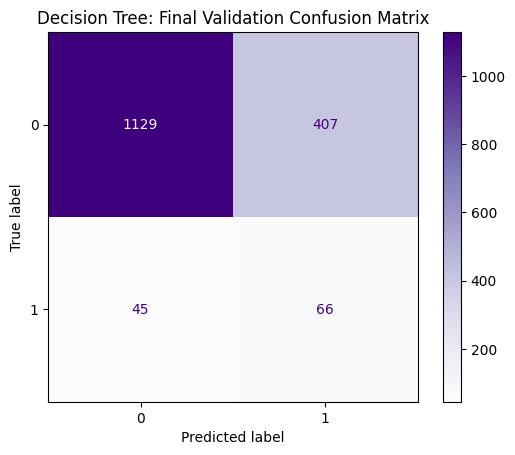

In [ ]:
y_pred_val = dt_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Validation Confusion Matrix")
plt.show()

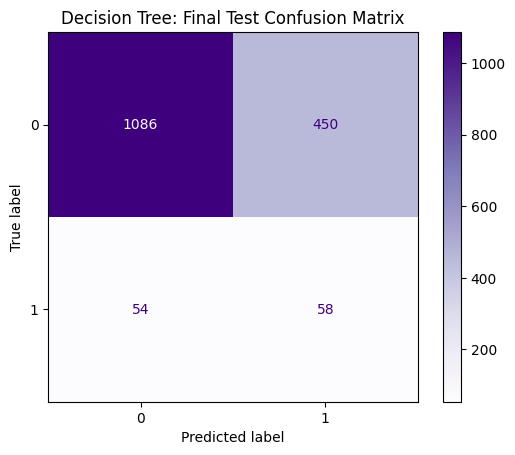

In [ ]:
y_pred_test = dt_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Test Confusion Matrix")
plt.show()

<b> Gradient Boosting </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_experiment)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 21 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Identify which columns need encoding (the cat_features we found earlier)
# Ensure these match your "cleaned" column names (lt_, gt_)
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'category' or X_train[col].dtype == 'object']

gb_pipe = Pipeline([
    # Encode clinical categories (1, 2, 3) so GBM can read them
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,         # Increased slightly to capture medical complexity
        subsample=0.8,       # Helps prevent overfitting
        random_state=42
    ))
])

# Calculate weights to force the model to care about Moderate/Severe classes
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit the pipeline using the weights
# Note: 'model__' prefix tells the pipeline to pass weights to the GBM stage
gb_pipe.fit(X_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, gb_pipe.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      1536
           1       0.15      0.46      0.23       111

    accuracy                           0.79      1647
   macro avg       0.55      0.64      0.55      1647
weighted avg       0.90      0.79      0.83      1647



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, gb_pipe.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      1536
           1       0.13      0.40      0.20       112

    accuracy                           0.78      1648
   macro avg       0.54      0.61      0.54      1648
weighted avg       0.89      0.78      0.83      1648



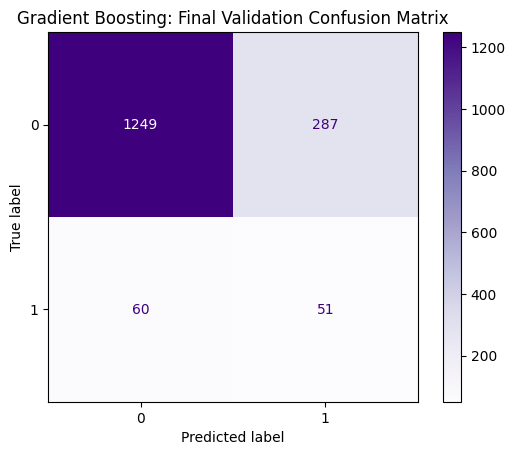

In [ ]:
y_pred_val = gb_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Validation Confusion Matrix")
plt.show()

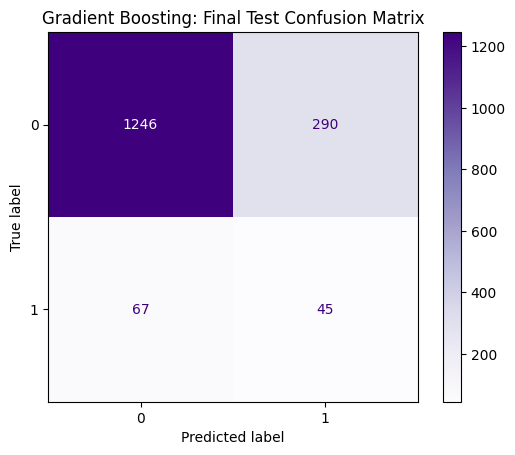

In [ ]:
y_pred_test = gb_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Test Confusion Matrix")
plt.show()

<b> XGB </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_experiment)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 21 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Calculate weights for each row in the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the XGBoost Classifier for BINARY tasks
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',  # Changed for Binary Logic
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

# 3. Fit with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

print("XGB (VAL)")
print(classification_report(y_val, xgb_model.predict(X_val)))

XGB (VAL)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1536
           1       0.14      0.14      0.14       111

    accuracy                           0.88      1647
   macro avg       0.54      0.54      0.54      1647
weighted avg       0.88      0.88      0.88      1647



In [ ]:
from sklearn.metrics import classification_report

print("XGB (TEST)")
print(classification_report(y_test, xgb_model.predict(X_test)))

XGB (TEST)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1536
           1       0.12      0.12      0.12       112

    accuracy                           0.88      1648
   macro avg       0.53      0.53      0.53      1648
weighted avg       0.88      0.88      0.88      1648



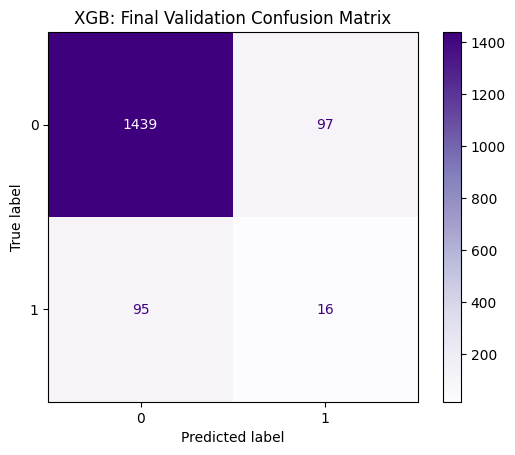

In [ ]:
y_pred_val = xgb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Validation Confusion Matrix")
plt.show()

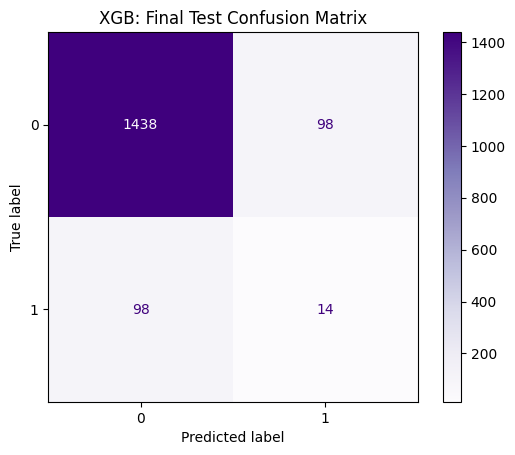

In [ ]:
y_pred_test = xgb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Test Confusion Matrix")
plt.show()

<b> CatBoost </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_experiment)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 21 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6899751	best: 0.6899751 (0)	total: 128ms	remaining: 2m 8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7369791667
bestIteration = 15

Shrink model to first 16 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      1536
           1       0.14      0.54      0.22       111

    accuracy                           0.75      1647
   macro avg       0.55      0.65      0.54      1647
weighted avg       0.90      0.75      0.81      1647



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1536
           1       0.12      0.47      0.19       112

    accuracy                           0.73      1648
   macro avg       0.54      0.61      0.51      1648
weighted avg       0.89      0.73      0.79      1648



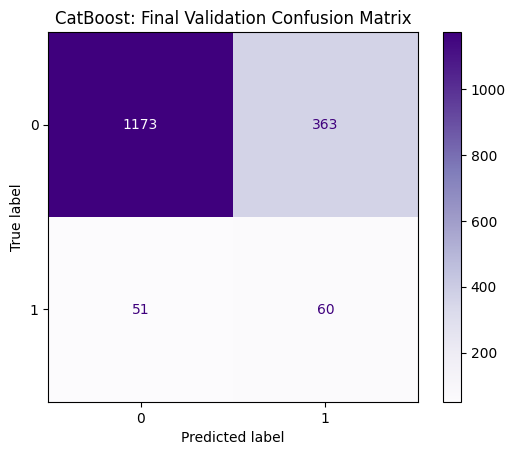

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

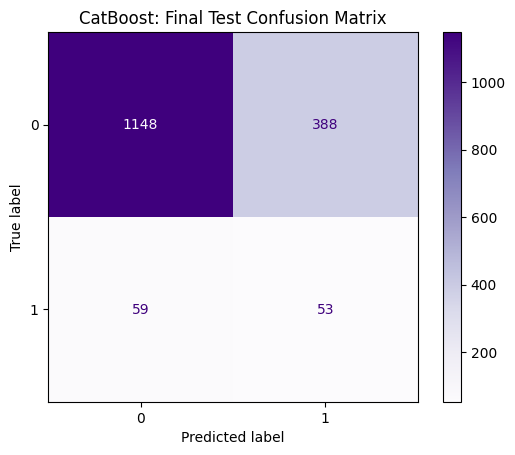

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

### Experiment c: Multi-Stage Feature Engineering

<b>Description:</b> This experiment aims to refine the input space by systematically removing low-signal and redundant clinical variables.

<b>Methodology:</b> A four-stage pruning strategy was implemented: removing columns with at least 70% of '9' (unknown) placeholders, dropping features with low Pearson correlation (< 0.01), filtering low Mutual Information (MI) scores (< 0.001), and resolving pairwise MI redundancies (> 0.1).


In [ ]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 16473 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              16473 non-null  int64  
 1   Patient Ethnicity Code                                           16473 non-null  int64  
 2   Patient Gender                                                   16473 non-null  int64  
 3   Weight                                                           16473 non-null  float64
 4   Height (m)                                                       16473 non-null  float64
 5   BMI                                                              16473 non-null  float64
 6   Procedure_code                                                   16473 non-null  int64  
 7   Contrast type_code                                      

In [ ]:
nd9_percentage = (df_new == 9).mean() * 100

# Filter for only those columns that contain any 'nd9' codes
nd9_report = nd9_percentage[nd9_percentage > 0].sort_values(ascending=False)

print("Percentage of 'nd9' codes per column:")
print(nd9_report)

# Find columns exceeding your 70% threshold
drop_candidates = nd9_report[nd9_report > 70].index.tolist()
print(f"\nCandidates to drop (>70% nd9): {drop_candidates}")

Percentage of 'nd9' codes per column:
High Uric Acid_1                                                 96.655133
Proteinuria lt_=0.5=1, gt_0.5=2, nd9                             94.275481
High Lactate- No: 0, Yes:1                                       90.208220
Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)                 82.662539
ProBNPmt300_1, nd9                                               81.970497
HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)               77.071572
High Thyroxine gt_14.4_1                                         60.632550
Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)    52.716567
CRP lt_=10=1, gt_10=2, nd9                                       45.225521
Hypoalbuminemia No-0, Yes-1, nd-9                                29.150732
Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)            20.312026
WBC notdone9, 4-10=1, lt_4.0=2, gt_10=3                          20.312026
Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9                    

In [ ]:
# List the columns you want to remove
cols_to_drop = [
    'High Uric Acid_1', 
    'High Lactate- No: 0, Yes:1', 
    'ProBNPmt300_1, nd9', 
    'Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)' , 
    'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)',
    'Proteinuria lt_=0.5=1, gt_0.5=2, nd9'
]



# Drop them from your dataframe
df_filtered = df_new.drop(columns=cols_to_drop)

print(f"Remaining columns: {df_filtered.shape[1]}")

Remaining columns: 28


In [ ]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data (Ensure no NaNs; fill 'nd9' as a specific category)
X = df_filtered.drop(columns=['AKI'])
y = df_filtered['AKI']

continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

discrete_mask = [col not in continuous_cols for col in X.columns]

mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask,
    random_state=42
)

correlations = X.corrwith(y).abs() # Absolute value to see strength regardless of direction

feature_comparison = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores,
    'Correlation': correlations.values
}).sort_values(by='MI Score', ascending=False)

print(feature_comparison)

                                              Feature  MI Score  Correlation
10                Elevated Cr or CKD before scan 0N1Y  0.009475     0.146521
13  Cardiovascular disease (PVD or IHD or CVA): Ab...  0.004501     0.096218
4                                          Height (m)  0.003009     0.013390
5                                                 BMI  0.002820     0.042619
11                             DM code, no DM-0, DM-1  0.002699     0.075361
8                                         Volume Vial  0.002571     0.041404
19  Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.002529     0.007344
15  Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.002354     0.053648
23                                          Diuretics  0.001669     0.064979
6                                      Procedure_code  0.001665     0.050630
22                                           ACEi/ARB  0.001644     0.058965
12                          HTN code, no HTN-0, HTN-1  0.001624     0.056042

In [ ]:
# Define your thresholds
corr_threshold = 0.01
mi_threshold = 0.001

# Create the groups
stars = feature_comparison[(feature_comparison['Correlation'] >= corr_threshold) & (feature_comparison['MI Score'] >= mi_threshold)]
hidden_gems = feature_comparison[(feature_comparison['Correlation'] < corr_threshold) & (feature_comparison['MI Score'] >= mi_threshold)]
trash = feature_comparison[(feature_comparison['MI Score'] < mi_threshold)]

print("=== STAR FEATURES (Keep: Hisgh Linear & Non-Linear Info) ===")
print(stars[['Feature', 'MI Score', 'Correlation']].to_string(index=False))

print("\n=== HIDDEN GEMS (Keep: Complex/Non-Linear Relationships) ===")
print(hidden_gems[['Feature', 'MI Score', 'Correlation']].to_string(index=False))

print("\n=== TRASH FEATURES (Candidate for Removal: Low/No Info) ===")
print(trash[['Feature', 'MI Score', 'Correlation']].to_string(index=False))

=== STAR FEATURES (Keep: Hisgh Linear & Non-Linear Info) ===
                                                        Feature  MI Score  Correlation
                            Elevated Cr or CKD before scan 0N1Y  0.009475     0.146521
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1  0.004501     0.096218
                                                     Height (m)  0.003009     0.013390
                                                            BMI  0.002820     0.042619
                                         DM code, no DM-0, DM-1  0.002699     0.075361
                                                    Volume Vial  0.002571     0.041404
  Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)  0.002354     0.053648
                                                      Diuretics  0.001669     0.064979
                                                 Procedure_code  0.001665     0.050630
                                                       ACEi/ARB  0.00

In [ ]:
to_drop = [
    "ACEi/ARB",
    "CRP lt_=10=1, gt_10=2, nd9",
    "Hypoalbuminemia No-0, Yes-1, nd-9",
    "High Thyroxine gt_14.4_1",
    "WBC notdone9, 4-10=1, lt_4.0=2, gt_10=3",
    "SGLT2i",
    "NSAIDS",
    "Patient Type 1inpt 2OutptDaysx 3Emer",
    "History of Ca",
    "Age",
    "Height (m)",
    "Calculated baseline creatinine"
]

# 2. Execute the drop
df_filtered = df_filtered.drop(columns=to_drop)

# 3. Verify the final list
print("=== Final Feature Set ===")
print(df_filtered.columns.tolist())

=== Final Feature Set ===
['Patient Ethnicity Code', 'Patient Gender', 'Weight', 'BMI', 'Procedure_code', 'Contrast type_code', 'Volume Vial', 'Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)', 'Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9', 'Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)', 'Diuretics', 'AKI']


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression


def pairwise_mi_matrix(
    df: pd.DataFrame,
    cols: list,
    discrete_cols: list = None,
    missing_codes: set = None,   # e.g., {9, -9}
    random_state: int = 42
) -> pd.DataFrame:
    """
    Compute pairwise mutual information MI(X_i ; X_j) for all columns in `cols`.

    - discrete-discrete: uses sklearn.metrics.mutual_info_score (exact for discrete)
    - continuous-continuous: uses mutual_info_regression (kNN estimator)
    - mixed: uses mutual_info_classif or mutual_info_regression depending on target type

    Returns: symmetric DataFrame (cols x cols) with MI values, diagonal = 0.
    """
    X = df[cols].copy()

    # Optional: remove rows with missing codes in any of the selected columns
    if missing_codes is not None:
        mask = ~X.isin(missing_codes).any(axis=1)
        X = X.loc[mask].copy()

    # Decide which columns are discrete
    if discrete_cols is None:
        # simple default: ints are treated as discrete, floats as continuous
        discrete_cols = [c for c in cols if pd.api.types.is_integer_dtype(X[c])]
    discrete_set = set(discrete_cols)

    mi_mat = np.zeros((len(cols), len(cols)), dtype=float)

    # pre-extract arrays for speed
    arrays = {c: X[c].to_numpy() for c in cols}

    for i, ci in enumerate(cols):
        xi = arrays[ci].reshape(-1, 1)
        ci_is_discrete = ci in discrete_set

        for j in range(i + 1, len(cols)):
            cj = cols[j]
            yj = arrays[cj]
            cj_is_discrete = cj in discrete_set

            if ci_is_discrete and cj_is_discrete:
                # discrete-discrete (symmetric, exact)
                mij = mutual_info_score(arrays[ci], yj)

            else:
                # one or both continuous: estimate MI using kNN estimators
                # Choose estimator based on whether "target" is discrete
                if cj_is_discrete:
                    mij = mutual_info_classif(
                        xi, yj, discrete_features=[ci_is_discrete], random_state=random_state
                    )[0]
                else:
                    mij = mutual_info_regression(
                        xi, yj, discrete_features=[ci_is_discrete], random_state=random_state
                    )[0]

            mi_mat[i, j] = mij
            mi_mat[j, i] = mij  # symmetry

    np.fill_diagonal(mi_mat, 0.0)
    return pd.DataFrame(mi_mat, index=cols, columns=cols)

In [ ]:
# 1. Define your final columns (the 13-15 finalists)
final_cols = df_filtered.drop(columns=['AKI']).columns.tolist()

# 2. Define which of these are continuous
continuous_final = ['Weight', 'BMI', 'Volume Vial']
discrete_final = [c for c in final_cols if c not in continuous_final]

# 3. Run your function
# We treat '9' as a missing code here so the MI isn't artificially inflated by shared 'nd9s'
mi_pair_df = pairwise_mi_matrix(
    df=df_filtered, 
    cols=final_cols, 
    discrete_cols=discrete_final,
    missing_codes={9, 'nd9', -9} 
)

# 4. Filter for high redundancy pairs
# We want to find pairs where MI > 0.1 (or whatever is high for your dataset)
stacked = mi_pair_df.stack().reset_index()
stacked.columns = ['Feature_A', 'Feature_B', 'Pairwise_MI']
redundant_pairs = stacked[stacked['Feature_A'] < stacked['Feature_B']].sort_values(by='Pairwise_MI', ascending=False)

print("=== Top Redundant Pairs (Shared Information) ===")
redundant_pairs.head(10)

=== Top Redundant Pairs (Shared Information) ===


,Feature_A,Feature_B,Pairwise_MI
47,BMI,Weight,0.645639
92,Volume Vial,Weight,0.148525
66,Procedure_code,Volume Vial,0.112661
51,BMI,Volume Vial,0.085261
132,"DM code, no DM-0, DM-1","Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9",0.084014
17,Patient Gender,Weight,0.040989
21,Patient Gender,Volume Vial,0.030914
54,BMI,"HTN code, no HTN-0, HTN-1",0.030781
53,BMI,"DM code, no DM-0, DM-1",0.024796
137,"HTN code, no HTN-0, HTN-1",Weight,0.021230


In [ ]:
# A. Calculate Target MI for all features
target_mi_scores = mutual_info_classif(
    df_filtered[final_cols], 
    df_filtered['AKI'], 
    discrete_features=[(c in discrete_final) for c in final_cols], 
    random_state=42
)
target_mi_dict = dict(zip(final_cols, target_mi_scores))

# B. Apply Pruning Logic (Threshold 0.5)
threshold = 0.1
to_drop = set()

print("=== Redundancy Decision Log ===")
for _, row in redundant_pairs.iterrows():
    f_a, f_b, mi_val = row['Feature_A'], row['Feature_B'], row['Pairwise_MI']
    
    if mi_val > threshold:
        # Check if neither has been dropped yet
        if f_a not in to_drop and f_b not in to_drop:
            mi_a = target_mi_dict[f_a]
            mi_b = target_mi_dict[f_b]
            
            # Keep the one with the HIGHER Target MI
            if mi_a >= mi_b:
                to_drop.add(f_b)
                print(f"MI={mi_val:.2f}: DROPPED '{f_b}' (Target MI: {mi_b:.4f}) | KEPT '{f_a}' (Target MI: {mi_a:.4f})")
            else:
                to_drop.add(f_a)
                print(f"MI={mi_val:.2f}: DROPPED '{f_a}' (Target MI: {mi_a:.4f}) | KEPT '{f_b}' (Target MI: {mi_b:.4f})")

# 5. Create final dataset
final_feature_set = [c for c in final_cols if c not in to_drop]
X_pruned = df_filtered[final_feature_set]

print("\n=== Final Pruned Feature Set ===")
print(final_feature_set)

=== Redundancy Decision Log ===
MI=0.65: DROPPED 'Weight' (Target MI: 0.0009) | KEPT 'BMI' (Target MI: 0.0020)
MI=0.11: DROPPED 'Volume Vial' (Target MI: 0.0016) | KEPT 'Procedure_code' (Target MI: 0.0017)

=== Final Pruned Feature Set ===
['Patient Ethnicity Code', 'Patient Gender', 'BMI', 'Procedure_code', 'Contrast type_code', 'Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)', 'Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9', 'Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)', 'Diuretics']


In [ ]:
# Combine features and target into one cleaned DataFrame
df_final_pruned = pd.concat([X_pruned, df_filtered['AKI']], axis=1)

print(f"Final dataset shape: {df_final_pruned.shape}")
print(f"Features kept: {len(final_feature_set)}")
print(f"Target column: AKI")

Final dataset shape: (16473, 14)
Features kept: 13
Target column: AKI


In [ ]:
df_final_pruned.info()

<class 'pandas.DataFrame'>
Index: 16473 entries, 0 to 25294
Data columns (total 14 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Patient Ethnicity Code                                           16473 non-null  int64  
 1   Patient Gender                                                   16473 non-null  int64  
 2   BMI                                                              16473 non-null  float64
 3   Procedure_code                                                   16473 non-null  int64  
 4   Contrast type_code                                               16473 non-null  int64  
 5   Elevated Cr or CKD before scan 0N1Y                              16473 non-null  int64  
 6   DM code, no DM-0, DM-1                                           16473 non-null  int64  
 7   HTN code, no HTN-0, HTN-1                               

In [ ]:
import numpy as np
import pandas as pd

def find_similar_rows_by_match_fraction(df, feature_cols, match_fraction=1.0):
    """
    Returns:
      pairs_df: row index pairs that are similar + their match fraction
      groups: list of lists of indices (connected components of similarity graph)
    """
    X = df[feature_cols].to_numpy()

    pairs = []
    n = len(df)

    # O(n^2) approach (fine for a few thousand rows; for huge data use method B)
    for i in range(n):
        # compare row i to rows i+1..end
        matches = (X[i] == X[i+1:]).mean(axis=1)  # fraction of matching columns
        js = np.where(matches >= match_fraction)[0]
        for j_rel in js:
            j = i + 1 + j_rel
            pairs.append((df.index[i], df.index[j], matches[j_rel]))

    pairs_df = pd.DataFrame(pairs, columns=["idx1", "idx2", "match_fraction"]).sort_values(
        "match_fraction", ascending=False
    )

    # Build groups (connected components)
    parent = {}

    def find(a):
        parent.setdefault(a, a)
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b, _ in pairs:
        union(a, b)

    # collect groups
    comp = {}
    for idx in set(pairs_df["idx1"]).union(set(pairs_df["idx2"])):
        r = find(idx)
        comp.setdefault(r, []).append(idx)

    groups = list(comp.values())
    return pairs_df, groups

feature_cols = [c for c in df_final_pruned.columns if c != "Cr_change_code"]

pairs_df, groups = find_similar_rows_by_match_fraction(
    df_final_pruned, feature_cols, match_fraction=1.0
)

print(pairs_df)

        idx1   idx2  match_fraction
52539  25198  25270             1.0
0          0  13495             1.0
1          2  10584             1.0
2          2  17866             1.0
3          3    152             1.0
4          6     26             1.0
5          6    132             1.0
6          6    242             1.0
7          6    311             1.0
8          6    491             1.0
9          6    582             1.0
10         6    790             1.0
52523  24741  24926             1.0
52522  24731  25035             1.0
52521  24731  24764             1.0
52520  24722  24926             1.0
52519  24722  24741             1.0
52518  24697  24787             1.0
52517  24695  24755             1.0
52516  24695  24752             1.0
52515  24689  24703             1.0
52514  24675  24755             1.0
52513  24675  24752             1.0
52512  24675  24695             1.0
52511  24623  25119             1.0
52510  24606  25153             1.0
52509  24569  24954         

In [ ]:
feature_cols = [c for c in df_final_pruned.columns if c != "AKI"]

# 1) Find feature-patterns that appear in BOTH classes (AKI differs)
mixed_mask = df_final_pruned.groupby(feature_cols)["AKI"].transform("nunique") > 1

# 2) Drop only the AKI==0 rows in those mixed groups
to_drop = df_final_pruned.index[mixed_mask & (df_final_pruned["AKI"] == 0)]

df_new_final = df_final_pruned.drop(index=to_drop).copy()

print("Dropped rows:", len(to_drop))
print("Original shape:", df_final_pruned.shape)
print("New shape:", df_new_final.shape)

Dropped rows: 1687
Original shape: (16473, 14)
New shape: (14786, 14)


### Model Development and Evaluation

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_new_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_new_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

<b> Logistic Regression </b>

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_new_final.columns if col != target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = ["BMI"]
categorical_features = [col for col in features_list if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [ ]:
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['BMI']),
                                                 ('cat', 'passthrough',
                                                  ['Patient Ethnicity Code',
                                                   'Patient Gender',
                                                   'Procedure_code',
                                                   'Contrast type_code',
                                                   'Elevated Cr or CKD before '
                                                   'scan 0N1Y',
                                                   'DM code, no DM-0, DM-1',
                                                   'HTN code, no HTN-0, HTN-1',
                                                   'Cardiovascular disease '
                                                   '(PVD or IHD or CVA): '
                                                   'Absent-0, Present-1',
                                                   'Procal_code (Grp 1-4: '
                                                   'lt_0.5, 0.5-lt_2, 2-lt_10, '
                                                   'gt_=10, nd9)',
                                                   'Glucose_code: lt_4_2, '
                                                   '4-11_1, gt_11_3, nd9',
                                                   'Hb notdone9, 11.5-17=1, '
                                                   'lt_8=2, 8-lt_11.5=3, '
                                                   'gt_17=4)',
                                                   'Diuretics'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("LogReg (VAL)")
print(classification_report(y_val, logreg_pipe.predict(X_val)))

LogReg (VAL)
              precision    recall  f1-score   support

           0       0.95      0.67      0.79      1367
           1       0.12      0.55      0.20       112

    accuracy                           0.66      1479
   macro avg       0.54      0.61      0.49      1479
weighted avg       0.89      0.66      0.74      1479



In [ ]:
from sklearn.metrics import classification_report

print("LogReg (TEST)")
print(classification_report(y_test, logreg_pipe.predict(X_test)))

LogReg (TEST)
              precision    recall  f1-score   support

           0       0.96      0.67      0.79      1368
           1       0.13      0.63      0.22       111

    accuracy                           0.67      1479
   macro avg       0.55      0.65      0.50      1479
weighted avg       0.90      0.67      0.74      1479



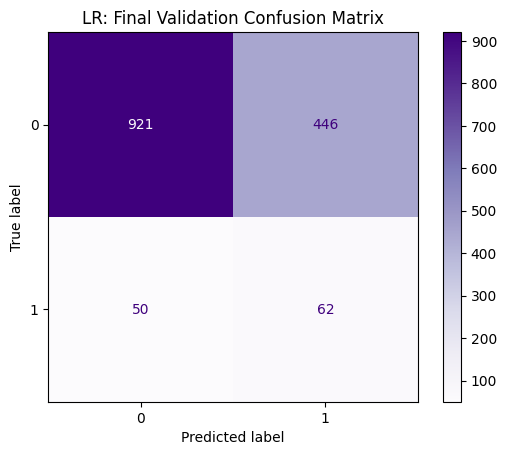

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_val = logreg_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Validation Confusion Matrix")
plt.show()

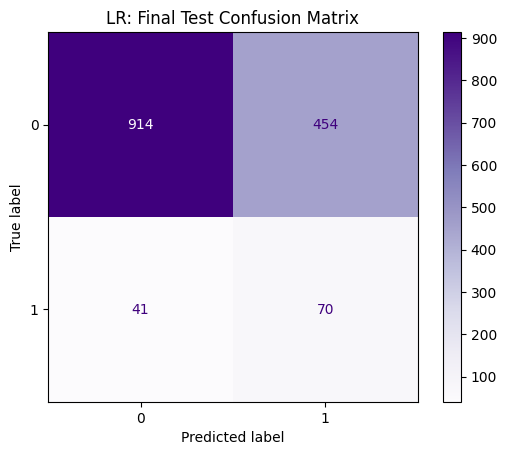

In [ ]:
y_pred_test = logreg_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Test Confusion Matrix")
plt.show()

<b> Random Forest </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_new_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_new_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_new_final.columns if col != target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=4, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("RF (VAL)")
print(classification_report(y_val, rf_pipe.predict(X_val)))

RF (VAL)
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1367
           1       0.24      0.28      0.26       112

    accuracy                           0.88      1479
   macro avg       0.59      0.60      0.59      1479
weighted avg       0.89      0.88      0.88      1479



In [ ]:
from sklearn.metrics import classification_report

print("RF(TEST)")
print(classification_report(y_test, rf_pipe.predict(X_test)))

RF(TEST)
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1368
           1       0.23      0.27      0.25       111

    accuracy                           0.88      1479
   macro avg       0.58      0.60      0.59      1479
weighted avg       0.89      0.88      0.88      1479



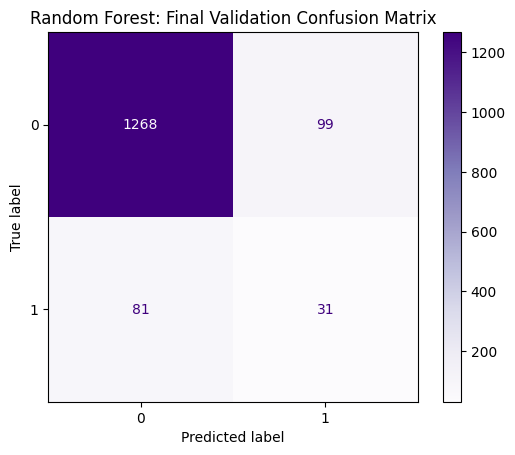

In [ ]:
y_pred_val = rf_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Validation Confusion Matrix")
plt.show()

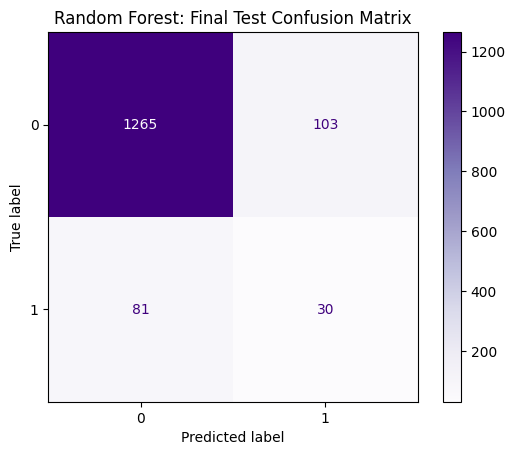

In [ ]:
y_pred_test = rf_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Test Confusion Matrix")
plt.show()

<b> Decision Tree </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_new_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_new_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    # Encode categories (1, 2, 3) as numbers for the tree logic
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("dt", DecisionTreeClassifier(
        criterion="gini",          # Or "entropy" to measure information gain
        max_depth=5,               # Keep it shallow so you can read the rules
        min_samples_leaf=10,       # Prevents the tree from creating a rule for 1-2 patients
        class_weight="balanced",   # CRITICAL: Fixes the 0.02 recall issue
        random_state=42
    ))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("DT (VAL)")
print(classification_report(y_val, dt_pipe.predict(X_val)))

DT (VAL)
              precision    recall  f1-score   support

           0       0.95      0.77      0.85      1367
           1       0.15      0.49      0.23       112

    accuracy                           0.75      1479
   macro avg       0.55      0.63      0.54      1479
weighted avg       0.89      0.75      0.80      1479



In [ ]:
from sklearn.metrics import classification_report

print("DT (TEST)")
print(classification_report(y_test, dt_pipe.predict(X_test)))

DT (TEST)
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      1368
           1       0.16      0.56      0.25       111

    accuracy                           0.75      1479
   macro avg       0.56      0.66      0.55      1479
weighted avg       0.90      0.75      0.81      1479



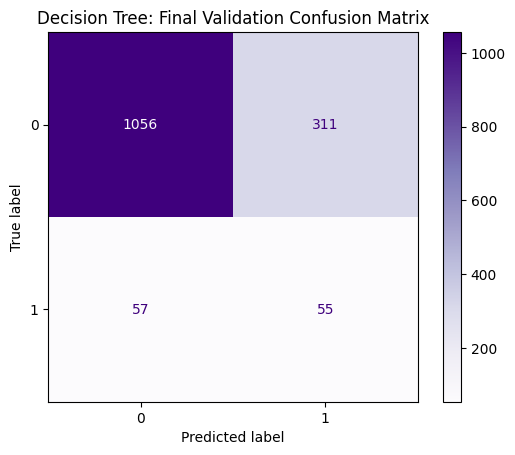

In [ ]:
y_pred_val = dt_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Validation Confusion Matrix")
plt.show()

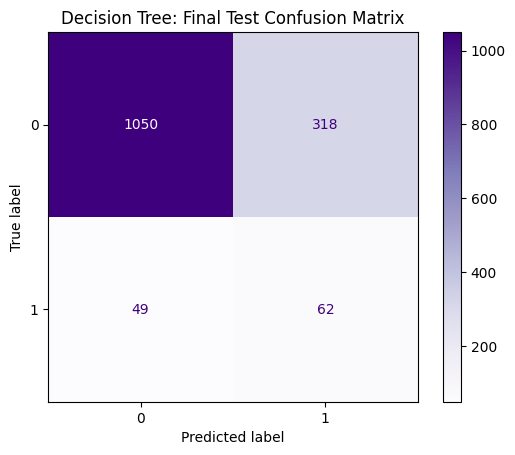

In [ ]:
y_pred_test = dt_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Test Confusion Matrix")
plt.show()

<b> Gradient Boosting </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_new_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

continuous_features = ['Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 12 features
Final Numerical List: 1 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Identify which columns need encoding (the cat_features we found earlier)
# Ensure these match your "cleaned" column names (lt_, gt_)
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'category' or X_train[col].dtype == 'object']

gb_pipe = Pipeline([
    # Encode clinical categories (1, 2, 3) so GBM can read them
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,         # Increased slightly to capture medical complexity
        subsample=0.8,       # Helps prevent overfitting
        random_state=42
    ))
])

# Calculate weights to force the model to care about Moderate/Severe classes
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit the pipeline using the weights
# Note: 'model__' prefix tells the pipeline to pass weights to the GBM stage
gb_pipe.fit(X_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, gb_pipe.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      1367
           1       0.15      0.52      0.23       112

    accuracy                           0.74      1479
   macro avg       0.55      0.64      0.54      1479
weighted avg       0.89      0.74      0.80      1479



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, gb_pipe.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.77      0.85      1368
           1       0.16      0.54      0.24       111

    accuracy                           0.75      1479
   macro avg       0.56      0.65      0.55      1479
weighted avg       0.89      0.75      0.80      1479



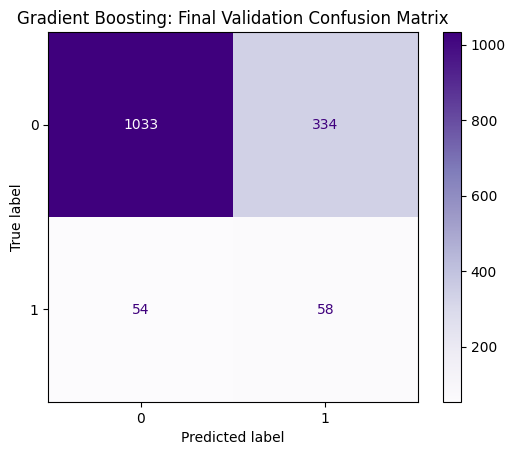

In [ ]:
y_pred_val = gb_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Validation Confusion Matrix")
plt.show()

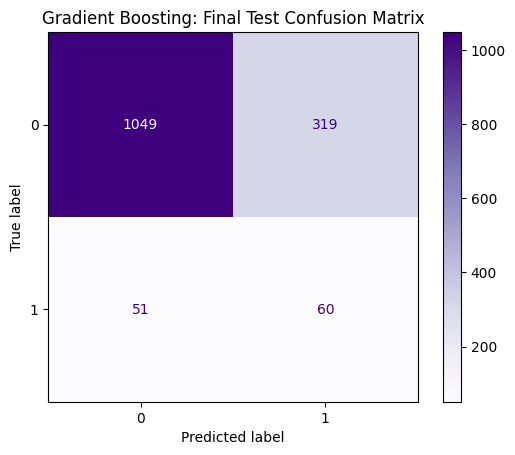

In [ ]:
y_pred_test = gb_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Test Confusion Matrix")
plt.show()

<b> XGB </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_new_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 12 features
Final Numerical List: 1 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Calculate weights for each row in the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the XGBoost Classifier for BINARY tasks
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',  # Changed for Binary Logic
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

# 3. Fit with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

print("XGB (VAL)")
print(classification_report(y_val, xgb_model.predict(X_val)))

XGB (VAL)
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1367
           1       0.14      0.27      0.19       112

    accuracy                           0.82      1479
   macro avg       0.54      0.57      0.54      1479
weighted avg       0.88      0.82      0.85      1479



In [ ]:
from sklearn.metrics import classification_report

print("XGB (TEST)")
print(classification_report(y_test, xgb_model.predict(X_test)))

XGB (TEST)
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1368
           1       0.16      0.30      0.21       111

    accuracy                           0.83      1479
   macro avg       0.55      0.58      0.55      1479
weighted avg       0.88      0.83      0.85      1479



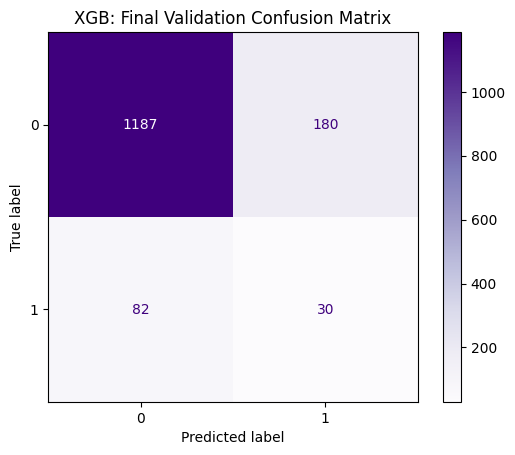

In [ ]:
y_pred_val = xgb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Validation Confusion Matrix")
plt.show()

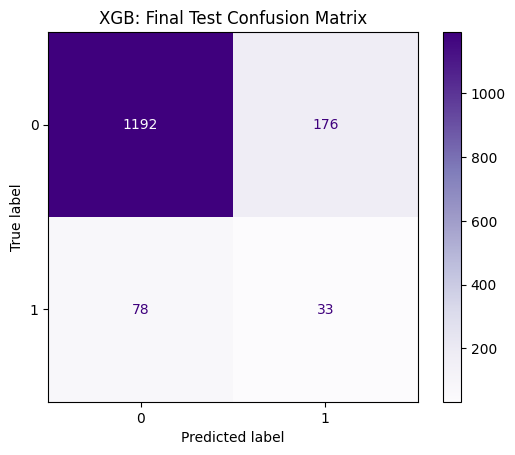

In [ ]:
y_pred_test = xgb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Test Confusion Matrix")
plt.show()

<b> CatBoost </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_new_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 12 features
Final Numerical List: 1 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6106829	best: 0.6106829 (0)	total: 160ms	remaining: 2m 39s
100:	test: 0.6499471	best: 0.6519327 (76)	total: 15.2s	remaining: 2m 15s
200:	test: 0.6541828	best: 0.6561292 (178)	total: 31.6s	remaining: 2m 5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6585654196
bestIteration = 226

Shrink model to first 227 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      1367
           1       0.14      0.55      0.22       112

    accuracy                           0.71      1479
   macro avg       0.55      0.64      0.52      1479
weighted avg       0.89      0.71      0.78      1479



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      1368
           1       0.15      0.59      0.24       111

    accuracy                           0.72      1479
   macro avg       0.55      0.66      0.53      1479
weighted avg       0.90      0.72      0.78      1479



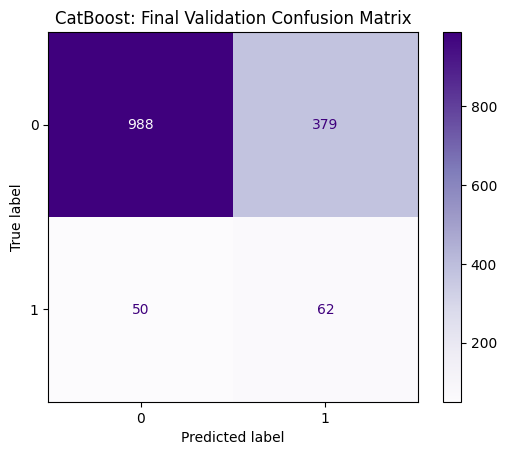

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

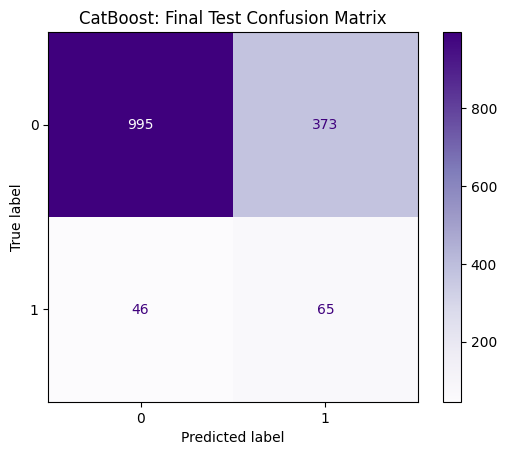

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

## Patients aged ≥ 60 and have at least one disease

In [ ]:
df_new = df.loc[df['Age'] >= 60]

In [ ]:
disease_cols = ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'History of Ca']

df_with_diseases = df_new[df_new[disease_cols].sum(axis=1) > 0]

In [ ]:
df_with_diseases.info()

<class 'pandas.DataFrame'>
Index: 12904 entries, 0 to 25294
Columns: 230 entries, RecordNo. to Baseline Cr ltet350_1
dtypes: float64(27), int64(131), object(17), str(55)
memory usage: 27.6+ MB


### Feature Selection & Dimensionality Reduction

In [ ]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [ ]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_with_diseases.columns = (
    df_with_diseases.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean your remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_with_diseases.columns))
print("Not found in df_with_diseases.columns:", missing)

Not found in df_with_diseases.columns: []


In [ ]:
df_new = df_with_diseases.drop(columns=remove_columns, errors="ignore")

In [ ]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 12904 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              12904 non-null  int64  
 1   Patient Ethnicity Code                                           12904 non-null  int64  
 2   Patient Gender                                                   12904 non-null  int64  
 3   Weight                                                           11089 non-null  float64
 4   Height (m)                                                       9122 non-null   float64
 5   BMI                                                              9122 non-null   float64
 6   Procedure_code                                                   12904 non-null  int64  
 7   Contrast type_code                                      

### Preprocessing Data

In [ ]:
#Displays the total sum of duplicated data rows
df_new.duplicated().sum()

np.int64(12)

In [ ]:
#To treat this process, I will drop the dulplicates from the DataFrame.
df_new = df_new.drop_duplicates()

In [ ]:
df_new.shape

(12892, 34)

In [ ]:
df_new.isnull().sum()

Age                                                                   0
Patient Ethnicity Code                                                0
Patient Gender                                                        0
Weight                                                             1803
Height (m)                                                         3770
BMI                                                                3770
Procedure_code                                                        0
Contrast type_code                                                    0
Volume Vial                                                           0
Patient Type 1inpt 2OutptDaysx 3Emer                                  0
Elevated Cr or CKD before scan 0N1Y                                   0
DM code, no DM-0, DM-1                                                0
HTN code, no HTN-0, HTN-1                                             0
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1 

In [ ]:
# Calculate percentage of missing values per class
missing_pct_by_aki = df_new.groupby('AKI').apply(lambda x: x.isnull().mean() * 100)

print("Percentage of missing values per column, grouped by AKI:")
print(missing_pct_by_aki.T) # .

Percentage of missing values per column, grouped by AKI:
AKI                                                         0          1
Age                                                  0.000000   0.000000
Patient Ethnicity Code                               0.000000   0.000000
Patient Gender                                       0.000000   0.000000
Weight                                              14.410480   8.841463
Height (m)                                          29.543164  25.609756
BMI                                                 29.543164  25.609756
Procedure_code                                       0.000000   0.000000
Contrast type_code                                   0.000000   0.000000
Volume Vial                                          0.000000   0.000000
Patient Type 1inpt 2OutptDaysx 3Emer                 0.000000   0.000000
Elevated Cr or CKD before scan 0N1Y                  0.000000   0.000000
DM code, no DM-0, DM-1                               0.000000   0.0

In [ ]:
from sklearn.impute import SimpleImputer

cols = ['Height (m)', 'Weight', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

In [ ]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 12892 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              12892 non-null  int64  
 1   Patient Ethnicity Code                                           12892 non-null  int64  
 2   Patient Gender                                                   12892 non-null  int64  
 3   Weight                                                           12892 non-null  float64
 4   Height (m)                                                       12892 non-null  float64
 5   BMI                                                              12892 non-null  float64
 6   Procedure_code                                                   12892 non-null  int64  
 7   Contrast type_code                                      

In [ ]:
df_new['AKI'].value_counts()

AKI
0    11908
1      984
Name: count, dtype: int64

### Baseline Model

In [ ]:
df_new.head()

,Age,Patient Ethnicity Code,Patient Gender,Weight,Height (m),BMI,Procedure_code,Contrast type_code,Volume Vial,Patient Type 1inpt 2OutptDaysx 3Emer,Elevated Cr or CKD before scan 0N1Y,"DM code, no DM-0, DM-1","HTN code, no HTN-0, HTN-1","Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1",History of Ca,"Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)","HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)","Hypoalbuminemia No-0, Yes-1, nd-9","Glucose_code: <4_2, 4-11_1, >11_3, nd9","High Lactate- No: 0, Yes:1",High Uric Acid_1,High Thyroxine >14.4_1,"Acidbase pH (<7.35=1, Normal2, >7.45=3, nd9)","Hb notdone9, 11.5-17=1, <8=2, 8-<11.5=3, >17=4)","WBC notdone9, 4-10=1, <4.0=2, >10=3","ProBNPmt300_1, nd9","Proteinuria <=0.5=1, >0.5=2, nd9","CRP <=10=1, >10=2, nd9",ACEi/ARB,Diuretics,NSAIDS,SGLT2i,Calculated baseline creatinine,AKI
0,86,1,1,51.2,1.49,23.1,1,2,65.0,1,0,1,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,65,0
1,88,1,2,42.3,1.60,16.5,1,2,65.0,3,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,88,0
2,72,9,2,58.9,1.58,23.8,1,2,70.0,3,1,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
3,78,3,1,56.3,1.58,23.8,1,2,70.0,1,0,0,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,64,0
5,74,1,2,64.8,1.68,23.0,1,2,70.0,1,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0


In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_new['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_new.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

<b> Logistic Regression </b>

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_new.columns if col != target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = ["Age", "Weight", "Height (m)", "BMI", "Volume Vial", "Calculated baseline creatinine"]
categorical_features = [col for col in features_list if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        multi_class="multinomial",
        max_iter=1000
    ))
])

In [ ]:
logreg_pipe.fit(X_train, y_train)

c:\Users\n1ck2\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Weight',
                                                   'Height (m)', 'BMI',
                                                   'Volume Vial',
                                                   'Calculated baseline '
                                                   'creatinine']),
                                                 ('cat', 'passthrough',
                                                  ['Patient Ethnicity Code',
                                                   'Patient Gender',
                                                   'Procedure_code',
                                                   'Contrast type_code',
                                                   'Patient Ty...
                                                   'Acidbase pH (<7.35=1, '
                                                   'Normal2, >7.45=3, nd9)',
                                                   'Hb notdone9, 11.5-17=1, '
                                                   '<8=2, 8-<11.5=3, >17=4)',
                                                   'WBC notdone9, 4-10=1, '
                                                   '<4.0=2, >10=3',
                                                   'ProBNPmt300_1, nd9',
                                                   'Proteinuria <=0.5=1, '
                                                   '>0.5=2, nd9',
                                                   'CRP <=10=1, >10=2, nd9',
                                                   'ACEi/ARB', 'Diuretics',
                                                   'NSAIDS', 'SGLT2i'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    multi_class='multinomial',
                                    random_state=42))])

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report

def show_cm(model, X, y, title="Confusion Matrix"):
    cm = confusion_matrix(y, model.predict(X))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("LogReg (VAL)")
print(classification_report(y_val, logreg_pipe.predict(X_val)))

LogReg (VAL)
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      1191
           1       0.14      0.59      0.22        98

    accuracy                           0.68      1289
   macro avg       0.54      0.64      0.51      1289
weighted avg       0.89      0.68      0.76      1289



In [ ]:
from sklearn.metrics import classification_report

print("LogReg (TEST)")
print(classification_report(y_test, logreg_pipe.predict(X_test)))

LogReg (TEST)
              precision    recall  f1-score   support

           0       0.96      0.68      0.79      1191
           1       0.14      0.64      0.23        99

    accuracy                           0.67      1290
   macro avg       0.55      0.66      0.51      1290
weighted avg       0.89      0.67      0.75      1290



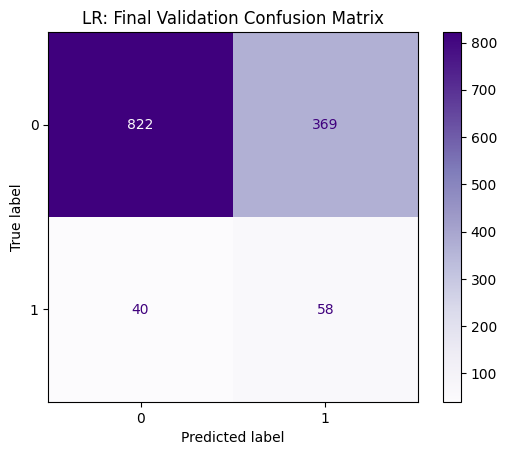

In [ ]:
y_pred_val = logreg_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Validation Confusion Matrix")
plt.show()

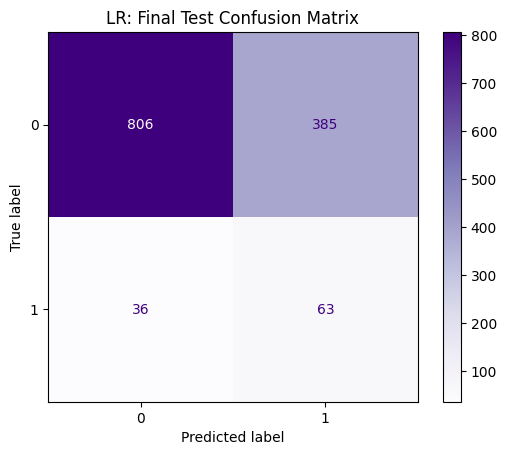

In [ ]:
y_pred_test = logreg_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Test Confusion Matrix")
plt.show()

<b> Random Forest </b>

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("RF (VAL)")
print(classification_report(y_val, rf_pipe.predict(X_val)))

RF (VAL)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1191
           1       0.21      0.19      0.20        98

    accuracy                           0.88      1289
   macro avg       0.57      0.57      0.57      1289
weighted avg       0.88      0.88      0.88      1289



In [ ]:
from sklearn.metrics import classification_report

print("RF(TEST)")
print(classification_report(y_test, rf_pipe.predict(X_test)))

RF(TEST)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1191
           1       0.28      0.27      0.28        99

    accuracy                           0.89      1290
   macro avg       0.61      0.61      0.61      1290
weighted avg       0.89      0.89      0.89      1290



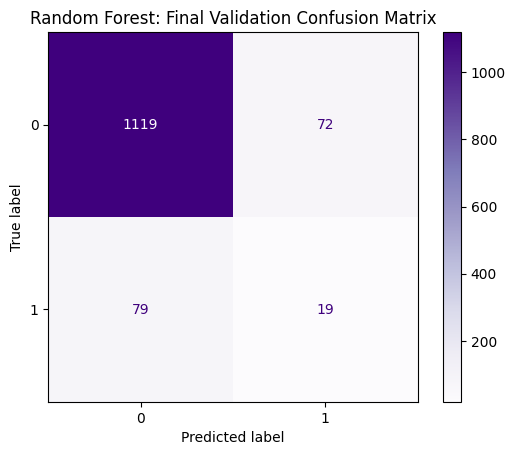

In [ ]:
y_pred_val = rf_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Validation Confusion Matrix")
plt.show()

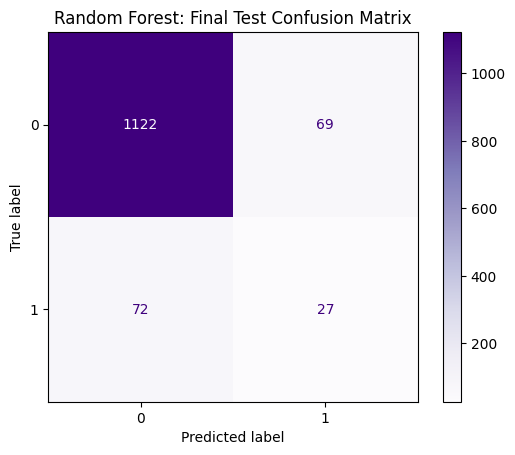

In [ ]:
y_pred_test = rf_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Test Confusion Matrix")
plt.show()

<b> Decision Tree </b>

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    # Encode categories (1, 2, 3) as numbers for the tree logic
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("dt", DecisionTreeClassifier(
        criterion="gini",          # Or "entropy" to measure information gain
        max_depth=5,               # Keep it shallow so you can read the rules
        min_samples_leaf=10,       # Prevents the tree from creating a rule for 1-2 patients
        class_weight="balanced",   # CRITICAL: Fixes the 0.02 recall issue
        random_state=42
    ))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("DT (VAL)")
print(classification_report(y_val, dt_pipe.predict(X_val)))

DT (VAL)
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      1191
           1       0.14      0.60      0.22        98

    accuracy                           0.68      1289
   macro avg       0.55      0.64      0.51      1289
weighted avg       0.89      0.68      0.75      1289



In [ ]:
from sklearn.metrics import classification_report

print("DT (TEST)")
print(classification_report(y_test, dt_pipe.predict(X_test)))

DT (TEST)
              precision    recall  f1-score   support

           0       0.95      0.65      0.77      1191
           1       0.13      0.62      0.21        99

    accuracy                           0.65      1290
   macro avg       0.54      0.63      0.49      1290
weighted avg       0.89      0.65      0.73      1290



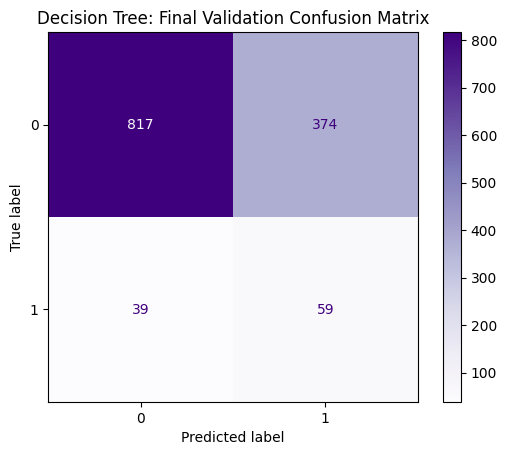

In [ ]:
y_pred_val = dt_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Validation Confusion Matrix")
plt.show()

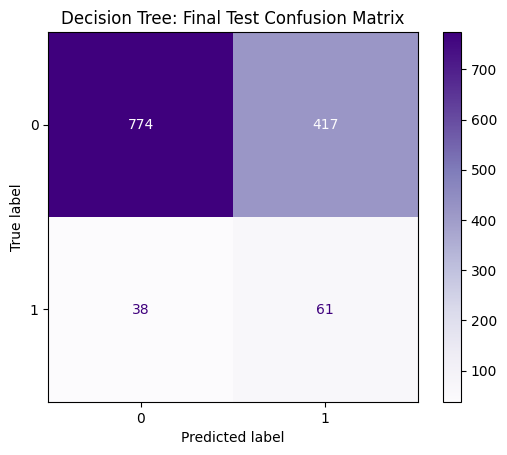

In [ ]:
y_pred_test = dt_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Test Confusion Matrix")
plt.show()

<b> Gradient Boosting </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()


continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 27 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Identify which columns need encoding (the cat_features we found earlier)
# Ensure these match your "cleaned" column names (lt_, gt_)
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'category' or X_train[col].dtype == 'object']

gb_pipe = Pipeline([
    # Encode clinical categories (1, 2, 3) so GBM can read them
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,         # Increased slightly to capture medical complexity
        subsample=0.8,       # Helps prevent overfitting
        random_state=42
    ))
])

# Calculate weights to force the model to care about Moderate/Severe classes
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit the pipeline using the weights
# Note: 'model__' prefix tells the pipeline to pass weights to the GBM stage
gb_pipe.fit(X_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, gb_pipe.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      1191
           1       0.17      0.47      0.25        98

    accuracy                           0.79      1289
   macro avg       0.56      0.64      0.56      1289
weighted avg       0.89      0.79      0.83      1289



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, gb_pipe.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1191
           1       0.16      0.47      0.24        99

    accuracy                           0.77      1290
   macro avg       0.56      0.64      0.56      1290
weighted avg       0.89      0.77      0.82      1290



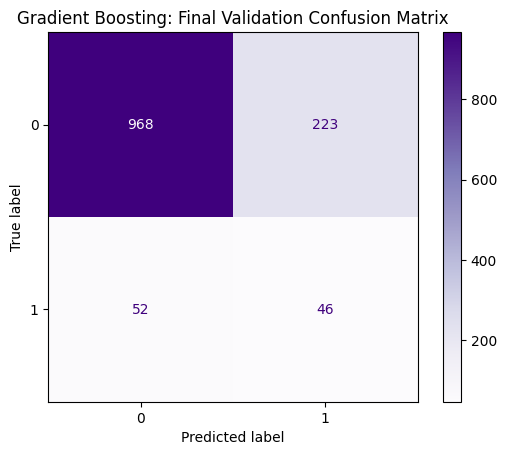

In [ ]:
y_pred_val = gb_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Validation Confusion Matrix")
plt.show()

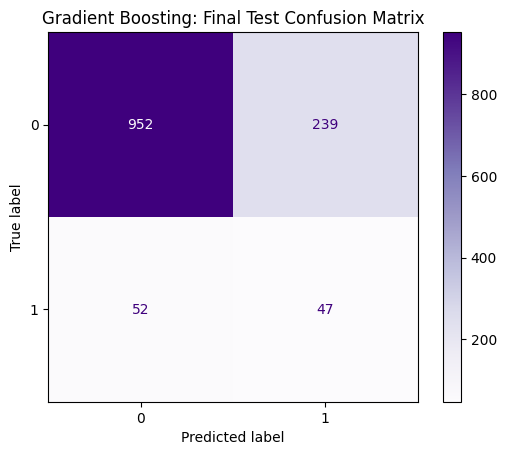

In [ ]:
y_pred_test = gb_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Test Confusion Matrix")
plt.show()

<b> XGB </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 27 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Calculate weights for each row in the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the XGBoost Classifier for BINARY tasks
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',  # Changed for Binary Logic
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

# 3. Fit with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

print("XGB (VAL)")
print(classification_report(y_val, xgb_model.predict(X_val)))

XGB (VAL)
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1191
           1       0.16      0.12      0.14        98

    accuracy                           0.88      1289
   macro avg       0.54      0.53      0.54      1289
weighted avg       0.87      0.88      0.88      1289



In [ ]:
from sklearn.metrics import classification_report

print("XGB (TEST)")
print(classification_report(y_test, xgb_model.predict(X_test)))

XGB (TEST)
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1191
           1       0.12      0.11      0.11        99

    accuracy                           0.87      1290
   macro avg       0.52      0.52      0.52      1290
weighted avg       0.86      0.87      0.87      1290



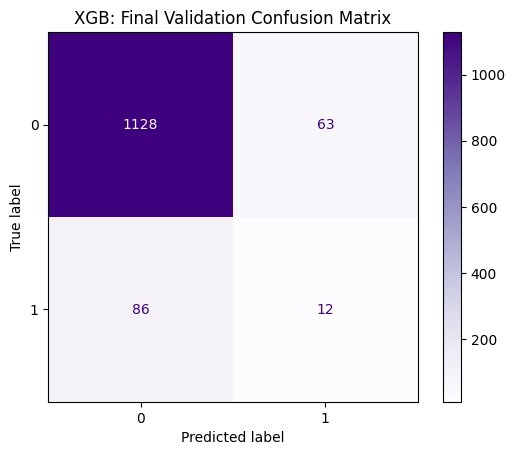

In [ ]:
y_pred_val = xgb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Validation Confusion Matrix")
plt.show()

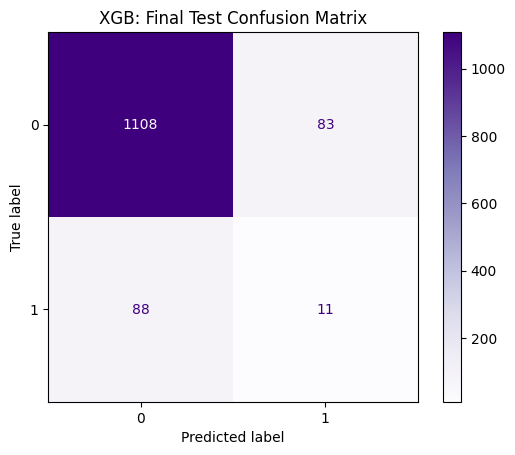

In [ ]:
y_pred_test = xgb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Test Confusion Matrix")
plt.show()

<b> CatBoost </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 27 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6935605	best: 0.6935605 (0)	total: 164ms	remaining: 2m 43s
100:	test: 0.7207800	best: 0.7211227 (99)	total: 15.7s	remaining: 2m 20s
200:	test: 0.7318066	best: 0.7318066 (200)	total: 31.4s	remaining: 2m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7322777978
bestIteration = 202

Shrink model to first 203 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1191
           1       0.15      0.54      0.24        98

    accuracy                           0.74      1289
   macro avg       0.55      0.65      0.54      1289
weighted avg       0.89      0.74      0.80      1289



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.96      0.71      0.82      1191
           1       0.15      0.62      0.24        99

    accuracy                           0.70      1290
   macro avg       0.55      0.66      0.53      1290
weighted avg       0.90      0.70      0.77      1290



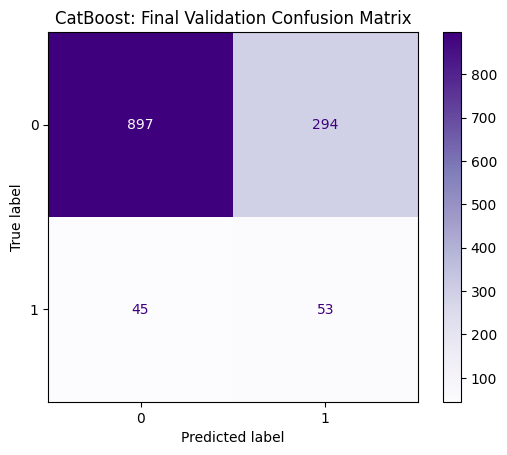

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

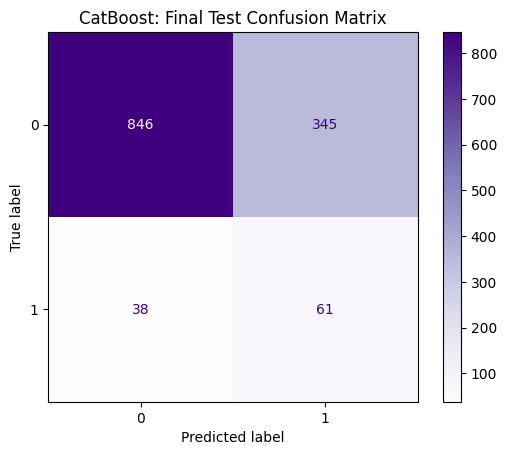

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Prepare a copy to avoid modifying original data
df_imputed = df_new.copy()

# 2. Define column groups
continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

# 3. Apply Imputation ONLY to Continuous Columns
# This replaces NaN with the Median, but ignores 'nd9' in categorical columns
cont_imputer = SimpleImputer(strategy='median')
df_imputed[continuous_cols] = cont_imputer.fit_transform(df_imputed[continuous_cols])

# 4. Prepare X and y
X = df_imputed.drop(columns=['AKI'])
y = df_imputed['AKI']

# 5. Update Discrete Mask based on X columns
# This tells MI which columns are labels (Categorical)
discrete_mask = [col not in continuous_cols for col in X.columns]

# 6. Calculate MI Scores
mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 7. Rank MI Results
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

# 8. Rank Correlation Results
correlations = X.corrwith(y).abs()
corr_results = pd.DataFrame({
    'Feature': X.columns,
    'Absolute Correlation': correlations.values
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

# --- Results ---
print("--- MI RESULTS (Imputed Continuous, Original Categorical) ---")
print(mi_results)
print('\n')
print("--- Corr RESULTS (Imputed Continuous, Original Categorical) ---")
print(corr_results)

--- MI RESULTS (Imputed Continuous, Original Categorical) ---
                                              Feature  MI Score
0                 Elevated Cr or CKD before scan 0N1Y  0.009454
1                                  ProBNPmt300_1, nd9  0.004720
2                                         Volume Vial  0.004241
3                                                 Age  0.003580
4                                                 BMI  0.003488
5   Cardiovascular disease (PVD or IHD or CVA): Ab...  0.003343
6    Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)  0.003014
7   Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.002634
8                                              Weight  0.002442
9   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.002075
10                             DM code, no DM-0, DM-1  0.001742
11                                     Procedure_code  0.001670
12                                          Diuretics  0.001604
13                             Patient Eth

### Experiment b: Null-Equivalent Placeholder Removal

<b>Description:</b> This test focuses on the "label noise" generated by medical placeholders that do not represent true physiological measurements.

<b>Methodology:</b> Features containing '9' (indicating unknown values) were excluded from the dataset to ensure the model was trained exclusively on the two newly engineered, logic-based clinical datasets.


In [ ]:
df_new.info()

<class 'pandas.DataFrame'>
Index: 12892 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              12892 non-null  int64  
 1   Patient Ethnicity Code                                           12892 non-null  int64  
 2   Patient Gender                                                   12892 non-null  int64  
 3   Weight                                                           12892 non-null  float64
 4   Height (m)                                                       12892 non-null  float64
 5   BMI                                                              12892 non-null  float64
 6   Procedure_code                                                   12892 non-null  int64  
 7   Contrast type_code                                      

In [ ]:
nd9_percentage = (df_new == 9).mean() * 100

# Filter for only those columns that contain any 'nd9' codes
nd9_report = nd9_percentage[nd9_percentage > 0].sort_values(ascending=False)

print("Percentage of 'nd9' codes per column:")
print(nd9_report)

Percentage of 'nd9' codes per column:
High Uric Acid_1                                                 96.230220
Proteinuria lt_=0.5=1, gt_0.5=2, nd9                             92.700900
High Lactate- No: 0, Yes:1                                       88.729445
Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)                 79.747130
ProBNPmt300_1, nd9                                               79.242941
HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)               75.581756
High Thyroxine gt_14.4_1                                         56.407074
Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)    47.587651
CRP lt_=10=1, gt_10=2, nd9                                       40.614334
Hypoalbuminemia No-0, Yes-1, nd-9                                24.565622
Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)            16.211604
WBC notdone9, 4-10=1, lt_4.0=2, gt_10=3                          16.211604
Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9                    

In [ ]:
# List the columns you want to remove
cols_to_drop = [
    'High Uric Acid_1', 
    'High Lactate- No: 0, Yes:1', 
    'ProBNPmt300_1, nd9', 
    'Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)' , 
    'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)',
    'Proteinuria lt_=0.5=1, gt_0.5=2, nd9'
]



# Drop them from your dataframe
df_experiment = df_new.drop(columns=cols_to_drop)

print(f"Remaining columns: {df_experiment.shape[1]}")

Remaining columns: 28


In [ ]:
df_experiment.info()

<class 'pandas.DataFrame'>
Index: 12892 entries, 0 to 25294
Data columns (total 28 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              12892 non-null  int64  
 1   Patient Ethnicity Code                                           12892 non-null  int64  
 2   Patient Gender                                                   12892 non-null  int64  
 3   Weight                                                           12892 non-null  float64
 4   Height (m)                                                       12892 non-null  float64
 5   BMI                                                              12892 non-null  float64
 6   Procedure_code                                                   12892 non-null  int64  
 7   Contrast type_code                                      

In [ ]:
import numpy as np
import pandas as pd

def find_similar_rows_by_match_fraction(df, feature_cols, match_fraction=1.0):
    """
    Returns:
      pairs_df: row index pairs that are similar + their match fraction
      groups: list of lists of indices (connected components of similarity graph)
    """
    X = df[feature_cols].to_numpy()

    pairs = []
    n = len(df)

    # O(n^2) approach (fine for a few thousand rows; for huge data use method B)
    for i in range(n):
        # compare row i to rows i+1..end
        matches = (X[i] == X[i+1:]).mean(axis=1)  # fraction of matching columns
        js = np.where(matches >= match_fraction)[0]
        for j_rel in js:
            j = i + 1 + j_rel
            pairs.append((df.index[i], df.index[j], matches[j_rel]))

    pairs_df = pd.DataFrame(pairs, columns=["idx1", "idx2", "match_fraction"]).sort_values(
        "match_fraction", ascending=False
    )

    # Build groups (connected components)
    parent = {}

    def find(a):
        parent.setdefault(a, a)
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b, _ in pairs:
        union(a, b)

    # collect groups
    comp = {}
    for idx in set(pairs_df["idx1"]).union(set(pairs_df["idx2"])):
        r = find(idx)
        comp.setdefault(r, []).append(idx)

    groups = list(comp.values())
    return pairs_df, groups

feature_cols = [c for c in df_experiment.columns if c != "AKI"]

pairs_df, groups = find_similar_rows_by_match_fraction(
    df_experiment, feature_cols, match_fraction=1.0
)

print(pairs_df)

Empty DataFrame
Columns: [idx1, idx2, match_fraction]
Index: []


In [ ]:
# 1) Find feature-patterns that appear in BOTH classes (AKI differs)
mixed_mask = df_experiment.groupby(feature_cols)["AKI"].transform("nunique") > 1

# 2) Drop only the AKI==0 rows in those mixed groups
to_drop = df_experiment.index[mixed_mask & (df_experiment["AKI"] == 0)]

df_final = df_experiment.drop(index=to_drop).copy()

print("Dropped rows:", len(to_drop))
print("Original shape:", df_experiment.shape)
print("New shape:", df_final.shape)

Dropped rows: 0
Original shape: (12892, 28)
New shape: (12892, 28)


### Model Development and Evaluation

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

<b> Logistic Regression </b>

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_final.columns if col != target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = ["Age", "Weight", "Height (m)", "BMI", "Volume Vial", 'Calculated baseline creatinine']
categorical_features = [col for col in features_list if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [ ]:
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Weight',
                                                   'Height (m)', 'BMI',
                                                   'Volume Vial',
                                                   'Calculated baseline '
                                                   'creatinine']),
                                                 ('cat', 'passthrough',
                                                  ['Patient Ethnicity Code',
                                                   'Patient Gender',
                                                   'Procedure_code',
                                                   'Contrast type_code',
                                                   'Patient Type 1inpt '
                                                   '2OutptDaysx 3Emer',
                                                   'Elevated Cr or CKD be...
                                                   'Hypoalbuminemia No-0, '
                                                   'Yes-1, nd-9',
                                                   'Glucose_code: lt_4_2, '
                                                   '4-11_1, gt_11_3, nd9',
                                                   'High Thyroxine gt_14.4_1',
                                                   'Hb notdone9, 11.5-17=1, '
                                                   'lt_8=2, 8-lt_11.5=3, '
                                                   'gt_17=4)',
                                                   'WBC notdone9, 4-10=1, '
                                                   'lt_4.0=2, gt_10=3',
                                                   'CRP lt_=10=1, gt_10=2, nd9',
                                                   'ACEi/ARB', 'Diuretics',
                                                   'NSAIDS', 'SGLT2i'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("LogReg (VAL)")
print(classification_report(y_val, logreg_pipe.predict(X_val)))

LogReg (VAL)
              precision    recall  f1-score   support

           0       0.96      0.68      0.79      1191
           1       0.14      0.64      0.23        98

    accuracy                           0.67      1289
   macro avg       0.55      0.66      0.51      1289
weighted avg       0.90      0.67      0.75      1289



In [ ]:
from sklearn.metrics import classification_report

print("LogReg (TEST)")
print(classification_report(y_test, logreg_pipe.predict(X_test)))

LogReg (TEST)
              precision    recall  f1-score   support

           0       0.95      0.67      0.78      1191
           1       0.13      0.62      0.22        99

    accuracy                           0.66      1290
   macro avg       0.54      0.64      0.50      1290
weighted avg       0.89      0.66      0.74      1290



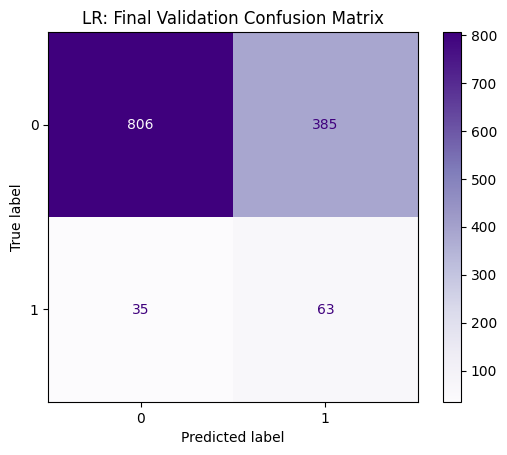

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_val = logreg_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Validation Confusion Matrix")
plt.show()

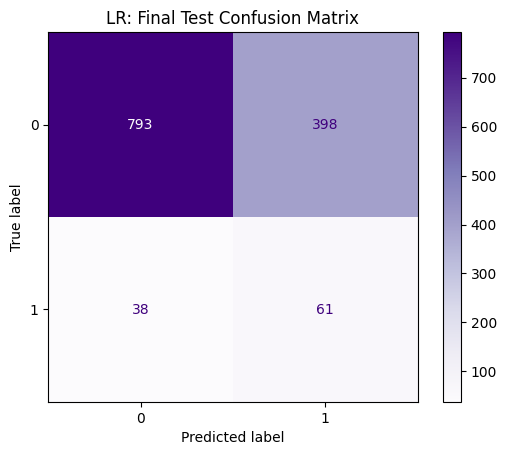

In [ ]:
y_pred_test = logreg_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Test Confusion Matrix")
plt.show()

<b> Random Forest </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_final.columns if col != target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=4, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("RF (VAL)")
print(classification_report(y_val, rf_pipe.predict(X_val)))

RF (VAL)
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      1191
           1       0.21      0.05      0.08        98

    accuracy                           0.91      1289
   macro avg       0.57      0.52      0.52      1289
weighted avg       0.87      0.91      0.89      1289



In [ ]:
from sklearn.metrics import classification_report

print("RF(TEST)")
print(classification_report(y_test, rf_pipe.predict(X_test)))

RF(TEST)
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      1191
           1       0.18      0.05      0.08        99

    accuracy                           0.91      1290
   macro avg       0.55      0.52      0.52      1290
weighted avg       0.87      0.91      0.89      1290



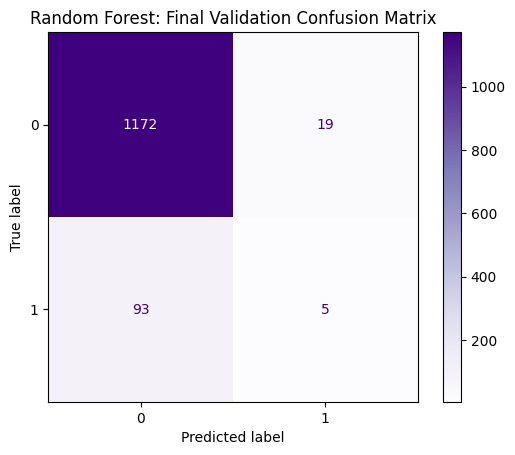

In [ ]:
y_pred_val = rf_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Validation Confusion Matrix")
plt.show()

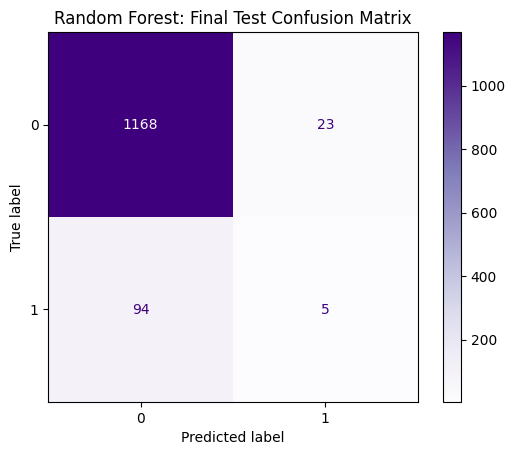

In [ ]:
y_pred_test = rf_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Test Confusion Matrix")
plt.show()

<b> Decision Tree </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    # Encode categories (1, 2, 3) as numbers for the tree logic
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("dt", DecisionTreeClassifier(
        criterion="gini",          # Or "entropy" to measure information gain
        max_depth=5,               # Keep it shallow so you can read the rules
        min_samples_leaf=10,       # Prevents the tree from creating a rule for 1-2 patients
        class_weight="balanced",   # CRITICAL: Fixes the 0.02 recall issue
        random_state=42
    ))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("DT (VAL)")
print(classification_report(y_val, dt_pipe.predict(X_val)))

DT (VAL)
              precision    recall  f1-score   support

           0       0.95      0.73      0.83      1191
           1       0.14      0.53      0.22        98

    accuracy                           0.72      1289
   macro avg       0.55      0.63      0.53      1289
weighted avg       0.89      0.72      0.78      1289



In [ ]:
from sklearn.metrics import classification_report

print("DT (TEST)")
print(classification_report(y_test, dt_pipe.predict(X_test)))

DT (TEST)
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      1191
           1       0.14      0.58      0.22        99

    accuracy                           0.69      1290
   macro avg       0.55      0.64      0.52      1290
weighted avg       0.89      0.69      0.76      1290



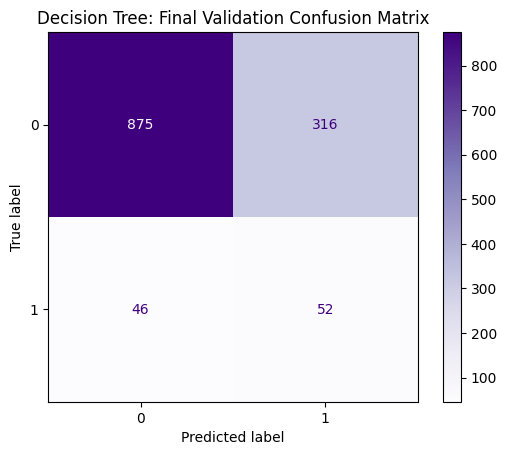

In [ ]:
y_pred_val = dt_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Validation Confusion Matrix")
plt.show()

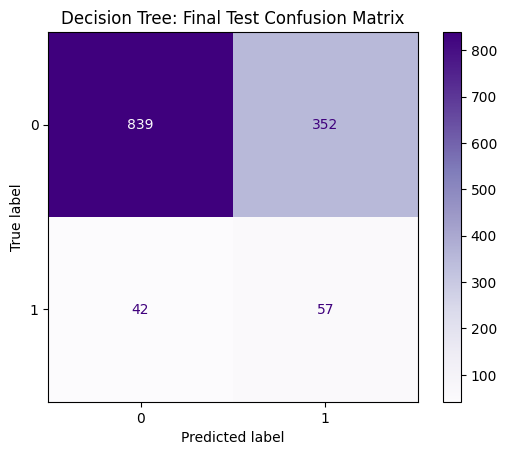

In [ ]:
y_pred_test = dt_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Test Confusion Matrix")
plt.show()

<b> Gradient Boosting </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 21 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Identify which columns need encoding (the cat_features we found earlier)
# Ensure these match your "cleaned" column names (lt_, gt_)
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'category' or X_train[col].dtype == 'object']

gb_pipe = Pipeline([
    # Encode clinical categories (1, 2, 3) so GBM can read them
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,         # Increased slightly to capture medical complexity
        subsample=0.8,       # Helps prevent overfitting
        random_state=42
    ))
])

# Calculate weights to force the model to care about Moderate/Severe classes
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit the pipeline using the weights
# Note: 'model__' prefix tells the pipeline to pass weights to the GBM stage
gb_pipe.fit(X_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, gb_pipe.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      1191
           1       0.16      0.44      0.23        98

    accuracy                           0.78      1289
   macro avg       0.55      0.62      0.55      1289
weighted avg       0.89      0.78      0.82      1289



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, gb_pipe.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.78      0.86      1191
           1       0.16      0.49      0.24        99

    accuracy                           0.76      1290
   macro avg       0.55      0.64      0.55      1290
weighted avg       0.89      0.76      0.81      1290



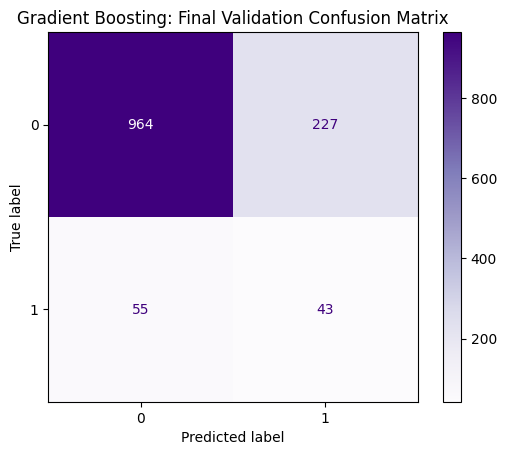

In [ ]:
y_pred_val = gb_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Validation Confusion Matrix")
plt.show()

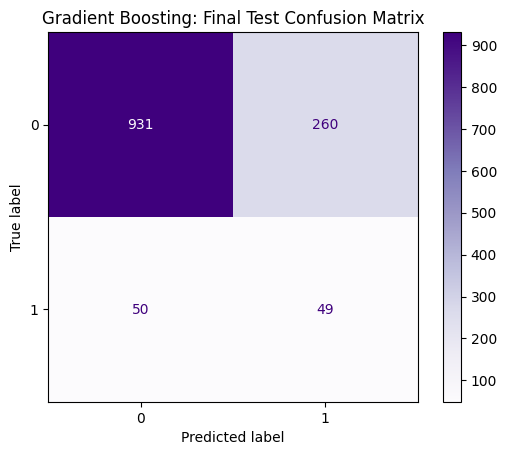

In [ ]:
y_pred_test = gb_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Test Confusion Matrix")
plt.show()

<b> XGB </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 21 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Calculate weights for each row in the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the XGBoost Classifier for BINARY tasks
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',  # Changed for Binary Logic
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

# 3. Fit with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

print("XGB (VAL)")
print(classification_report(y_val, xgb_model.predict(X_val)))

XGB (VAL)
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1191
           1       0.20      0.16      0.18        98

    accuracy                           0.89      1289
   macro avg       0.57      0.56      0.56      1289
weighted avg       0.88      0.89      0.88      1289



In [ ]:
from sklearn.metrics import classification_report

print("XGB (TEST)")
print(classification_report(y_test, xgb_model.predict(X_test)))

XGB (TEST)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1191
           1       0.20      0.18      0.19        99

    accuracy                           0.88      1290
   macro avg       0.57      0.56      0.56      1290
weighted avg       0.88      0.88      0.88      1290



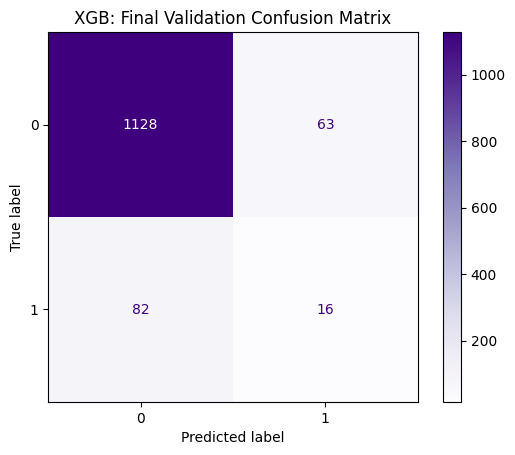

In [ ]:
y_pred_val = xgb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Validation Confusion Matrix")
plt.show()

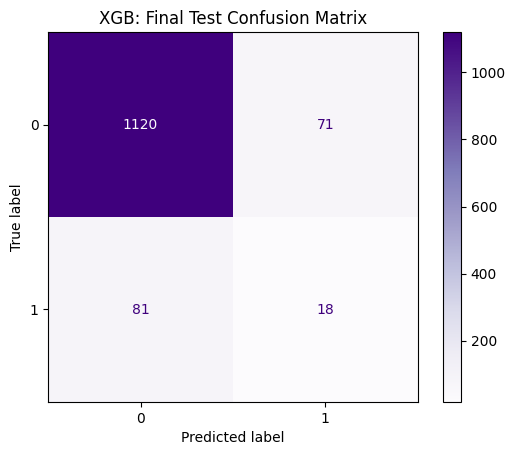

In [ ]:
y_pred_test = xgb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Test Confusion Matrix")
plt.show()

<b> CatBoost </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 21 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6493214	best: 0.6493214 (0)	total: 79.8ms	remaining: 1m 19s


In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.96      0.72      0.82      1191
           1       0.15      0.60      0.24        98

    accuracy                           0.71      1289
   macro avg       0.55      0.66      0.53      1289
weighted avg       0.90      0.71      0.78      1289



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      1191
           1       0.14      0.61      0.22        99

    accuracy                           0.68      1290
   macro avg       0.55      0.65      0.51      1290
weighted avg       0.89      0.68      0.75      1290



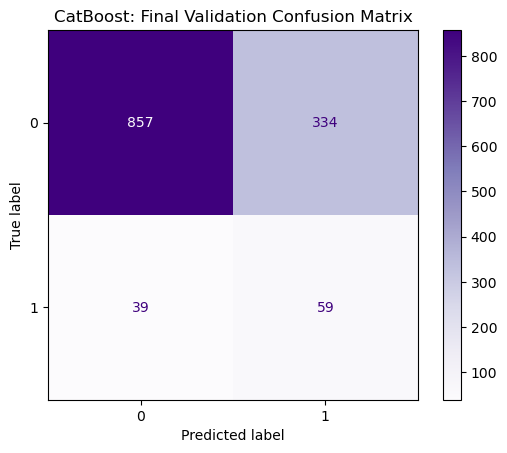

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

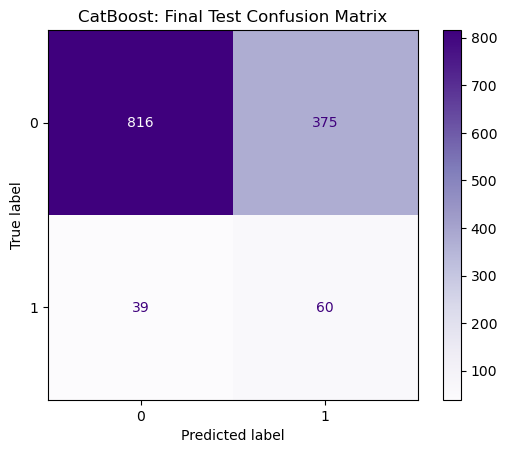

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

### Experiment c: Multi-Stage Feature Engineering

<b>Description:</b> This experiment aims to refine the input space by systematically removing low-signal and redundant clinical variables.
    
<b>Methodology:</b> A four-stage pruning strategy was implemented: removing columns with at least 70% of '9' (unknown) placeholders, dropping features with low Pearson correlation (< 0.01), filtering low Mutual Information (MI) scores (< 0.001), and resolving pairwise MI redundancies (> 0.1).


In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12892 entries, 0 to 25294
Data columns (total 34 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              12892 non-null  int64  
 1   Patient Ethnicity Code                                           12892 non-null  int64  
 2   Patient Gender                                                   12892 non-null  int64  
 3   Weight                                                           12892 non-null  float64
 4   Height (m)                                                       12892 non-null  float64
 5   BMI                                                              12892 non-null  float64
 6   Procedure_code                                                   12892 non-null  int64  
 7   Contrast type_code                           

In [ ]:
nd9_percentage = (df_new == 9).mean() * 100

# Filter for only those columns that contain any 'nd9' codes
nd9_report = nd9_percentage[nd9_percentage > 0].sort_values(ascending=False)

print("Percentage of 'nd9' codes per column:")
print(nd9_report)

# Find columns exceeding your 70% threshold
drop_candidates = nd9_report[nd9_report > 70].index.tolist()
print(f"\nCandidates to drop (>70% nd9): {drop_candidates}")

Percentage of 'nd9' codes per column:
High Uric Acid_1                                                 96.230220
Proteinuria lt_=0.5=1, gt_0.5=2, nd9                             92.700900
High Lactate- No: 0, Yes:1                                       88.729445
Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)                 79.747130
ProBNPmt300_1, nd9                                               79.242941
HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)               75.581756
High Thyroxine gt_14.4_1                                         56.407074
Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)    47.587651
CRP lt_=10=1, gt_10=2, nd9                                       40.614334
Hypoalbuminemia No-0, Yes-1, nd-9                                24.565622
Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)            16.211604
WBC notdone9, 4-10=1, lt_4.0=2, gt_10=3                          16.211604
Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9                    

In [ ]:
# List the columns you want to remove
cols_to_drop = [
    'High Uric Acid_1', 
    'High Lactate- No: 0, Yes:1', 
    'ProBNPmt300_1, nd9', 
    'Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)' , 
    'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)',
    'Proteinuria lt_=0.5=1, gt_0.5=2, nd9'
]



# Drop them from your dataframe
df_filtered = df_new.drop(columns=cols_to_drop)

print(f"Remaining columns: {df_filtered.shape[1]}")

Remaining columns: 28


In [ ]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data (Ensure no NaNs; fill 'nd9' as a specific category)
X = df_filtered.drop(columns=['AKI'])
y = df_filtered['AKI']

continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

discrete_mask = [col not in continuous_cols for col in X.columns]

mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask,
    random_state=42
)

correlations = X.corrwith(y).abs() # Absolute value to see strength regardless of direction

feature_comparison = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores,
    'Correlation': correlations.values
}).sort_values(by='MI Score', ascending=False)

print(feature_comparison)

                                              Feature  MI Score  Correlation
10                Elevated Cr or CKD before scan 0N1Y  0.009454     0.142288
8                                         Volume Vial  0.004241     0.037327
0                                                 Age  0.003580     0.051015
5                                                 BMI  0.003488     0.045951
13  Cardiovascular disease (PVD or IHD or CVA): Ab...  0.003343     0.081223
19  Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.002634     0.003211
3                                              Weight  0.002442     0.059488
15  Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.002075     0.047734
11                             DM code, no DM-0, DM-1  0.001742     0.059494
6                                      Procedure_code  0.001670     0.052636
23                                          Diuretics  0.001604     0.062405
1                              Patient Ethnicity Code  0.001375     0.023350

In [ ]:
# Define your thresholds
corr_threshold = 0.01
mi_threshold = 0.001

# Create the groups
stars = feature_comparison[(feature_comparison['Correlation'] >= corr_threshold) & (feature_comparison['MI Score'] >= mi_threshold)]
hidden_gems = feature_comparison[(feature_comparison['Correlation'] < corr_threshold) & (feature_comparison['MI Score'] >= mi_threshold)]
trash = feature_comparison[(feature_comparison['MI Score'] < mi_threshold)]

print("=== STAR FEATURES (Keep: Hisgh Linear & Non-Linear Info) ===")
print(stars[['Feature', 'MI Score', 'Correlation']].to_string(index=False))

print("\n=== HIDDEN GEMS (Keep: Complex/Non-Linear Relationships) ===")
print(hidden_gems[['Feature', 'MI Score', 'Correlation']].to_string(index=False))

print("\n=== TRASH FEATURES (Candidate for Removal: Low/No Info) ===")
print(trash[['Feature', 'MI Score', 'Correlation']].to_string(index=False))

=== STAR FEATURES (Keep: Hisgh Linear & Non-Linear Info) ===
                                                        Feature  MI Score  Correlation
                            Elevated Cr or CKD before scan 0N1Y  0.009454     0.142288
                                                    Volume Vial  0.004241     0.037327
                                                            Age  0.003580     0.051015
                                                            BMI  0.003488     0.045951
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1  0.003343     0.081223
                                                         Weight  0.002442     0.059488
  Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)  0.002075     0.047734
                                         DM code, no DM-0, DM-1  0.001742     0.059494
                                                 Procedure_code  0.001670     0.052636
                                                      Diuretics  0.00

In [ ]:
to_drop = [
    "CRP lt_=10=1, gt_10=2, nd9",
    "Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9",
    "Patient Type 1inpt 2OutptDaysx 3Emer",
    "Hypoalbuminemia No-0, Yes-1, nd-9",
    "ACEi/ARB",
    "High Thyroxine gt_14.4_1",
    "SGLT2i",
    "WBC notdone9, 4-10=1, lt_4.0=2, gt_10=3",
    "NSAIDS",
    "BMI",
    "History of Ca",
    "HTN code, no HTN-0, HTN-1"
]

# 2. Execute the drop
df_filtered = df_filtered.drop(columns=to_drop)

# 3. Verify the final list
print("=== Final Feature Set ===")
print(df_filtered.columns.tolist())

=== Final Feature Set ===
['Age', 'Patient Ethnicity Code', 'Patient Gender', 'Weight', 'Height (m)', 'Procedure_code', 'Contrast type_code', 'Volume Vial', 'Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)', 'Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)', 'Diuretics', 'Calculated baseline creatinine', 'AKI']


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression


def pairwise_mi_matrix(
    df: pd.DataFrame,
    cols: list,
    discrete_cols: list = None,
    missing_codes: set = None,   # e.g., {9, -9}
    random_state: int = 42
) -> pd.DataFrame:
    """
    Compute pairwise mutual information MI(X_i ; X_j) for all columns in `cols`.

    - discrete-discrete: uses sklearn.metrics.mutual_info_score (exact for discrete)
    - continuous-continuous: uses mutual_info_regression (kNN estimator)
    - mixed: uses mutual_info_classif or mutual_info_regression depending on target type

    Returns: symmetric DataFrame (cols x cols) with MI values, diagonal = 0.
    """
    X = df[cols].copy()

    # Optional: remove rows with missing codes in any of the selected columns
    if missing_codes is not None:
        mask = ~X.isin(missing_codes).any(axis=1)
        X = X.loc[mask].copy()

    # Decide which columns are discrete
    if discrete_cols is None:
        # simple default: ints are treated as discrete, floats as continuous
        discrete_cols = [c for c in cols if pd.api.types.is_integer_dtype(X[c])]
    discrete_set = set(discrete_cols)

    mi_mat = np.zeros((len(cols), len(cols)), dtype=float)

    # pre-extract arrays for speed
    arrays = {c: X[c].to_numpy() for c in cols}

    for i, ci in enumerate(cols):
        xi = arrays[ci].reshape(-1, 1)
        ci_is_discrete = ci in discrete_set

        for j in range(i + 1, len(cols)):
            cj = cols[j]
            yj = arrays[cj]
            cj_is_discrete = cj in discrete_set

            if ci_is_discrete and cj_is_discrete:
                # discrete-discrete (symmetric, exact)
                mij = mutual_info_score(arrays[ci], yj)

            else:
                # one or both continuous: estimate MI using kNN estimators
                # Choose estimator based on whether "target" is discrete
                if cj_is_discrete:
                    mij = mutual_info_classif(
                        xi, yj, discrete_features=[ci_is_discrete], random_state=random_state
                    )[0]
                else:
                    mij = mutual_info_regression(
                        xi, yj, discrete_features=[ci_is_discrete], random_state=random_state
                    )[0]

            mi_mat[i, j] = mij
            mi_mat[j, i] = mij  # symmetry

    np.fill_diagonal(mi_mat, 0.0)
    return pd.DataFrame(mi_mat, index=cols, columns=cols)

In [ ]:
# 1. Define your final columns (the 13-15 finalists)
final_cols = df_filtered.drop(columns=['AKI']).columns.tolist()

# 2. Define which of these are continuous
continuous_final = ['Weight', 'Age', 'Height (m)', 'Calculated baseline creatinine', 'Volume Vial']
discrete_final = [c for c in final_cols if c not in continuous_final]

# 3. Run your function
# We treat '9' as a missing code here so the MI isn't artificially inflated by shared 'nd9s'
mi_pair_df = pairwise_mi_matrix(
    df=df_filtered, 
    cols=final_cols, 
    discrete_cols=discrete_final,
    missing_codes={9, 'nd9', -9} 
)

# 4. Filter for high redundancy pairs
# We want to find pairs where MI > 0.1 (or whatever is high for your dataset)
stacked = mi_pair_df.stack().reset_index()
stacked.columns = ['Feature_A', 'Feature_B', 'Pairwise_MI']
redundant_pairs = stacked[stacked['Feature_A'] < stacked['Feature_B']].sort_values(by='Pairwise_MI', ascending=False)

print("=== Top Redundant Pairs (Shared Information) ===")
redundant_pairs.head(10)

=== Top Redundant Pairs (Shared Information) ===


,Feature_A,Feature_B,Pairwise_MI
14,Age,Calculated baseline creatinine,1.979972
212,Calculated baseline creatinine,Patient Gender,0.692427
214,Calculated baseline creatinine,Height (m),0.272919
62,Height (m),Patient Gender,0.226623
63,Height (m),Weight,0.176825
108,Volume Vial,Weight,0.144820
82,Procedure_code,Volume Vial,0.119846
213,Calculated baseline creatinine,Weight,0.096915
3,Age,Weight,0.062297
217,Calculated baseline creatinine,Volume Vial,0.046318


In [ ]:
import pandas as pd
import numpy as np

# 1. Define your final columns
final_cols = df_filtered.drop(columns=['AKI']).columns.tolist()

# 2. Use your custom pairwise_mi_matrix function from earlier
# This ensures discrete and continuous variables are handled correctly
mi_matrix_df = pairwise_mi_matrix(
    df=df_filtered, 
    cols=final_cols,
    missing_codes={9, 'nd9'} # Exclude 'nd9' to get real informational overlap
)

# 3. Format the table for display (rounding to 6 decimal places for precision)
mi_matrix_formatted = mi_matrix_df.round(6)

# Display the result
mi_matrix_formatted

,Age,Patient Ethnicity Code,Patient Gender,Weight,Height (m),Procedure_code,Contrast type_code,Volume Vial,Elevated Cr or CKD before scan 0N1Y,"DM code, no DM-0, DM-1","Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1","Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)","Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)",Diuretics,Calculated baseline creatinine
Age,0.000000,0.029671,0.021686,0.062451,0.046512,0.012581,0.006503,0.021366,0.012301,0.027645,0.004084,0.012460,0.014943,0.006055,2.000384
Patient Ethnicity Code,0.029671,0.000000,0.000614,0.022358,0.008954,0.000394,0.000156,0.011240,0.004027,0.009934,0.001345,0.000723,0.000442,0.002173,0.027237
Patient Gender,0.021686,0.000614,0.000000,0.039162,0.226623,0.000960,0.000134,0.024937,0.009472,0.000338,0.002365,0.000648,0.007789,0.000540,0.692347
Weight,0.062451,0.022358,0.039162,0.000000,0.176825,0.000000,0.000320,0.144820,0.013001,0.008850,0.000000,0.011516,0.000000,0.002574,0.098116
Height (m),0.046512,0.008954,0.226623,0.176825,0.000000,0.000000,0.001616,0.008862,0.003391,0.005277,0.002497,0.000000,0.000152,0.000000,0.276722
Procedure_code,0.012581,0.000394,0.000960,0.000000,0.000000,0.000000,0.004355,0.119846,0.002470,0.000182,0.003432,0.004534,0.003437,0.003677,0.006815
Contrast type_code,0.006503,0.000156,0.000134,0.000320,0.001616,0.004355,0.000000,0.003750,0.003223,0.000124,0.000056,0.001644,0.002839,0.000693,0.002660
Volume Vial,0.021366,0.011240,0.024937,0.144820,0.008862,0.119846,0.003750,0.000000,0.011153,0.010128,0.006739,0.000000,0.000000,0.003987,0.051916
Elevated Cr or CKD before scan 0N1Y,0.012301,0.004027,0.009472,0.013001,0.003391,0.002470,0.003223,0.011153,0.000000,0.004681,0.000722,0.008939,0.017802,0.004933,0.018159
"DM code, no DM-0, DM-1",0.027645,0.009934,0.000338,0.008850,0.005277,0.000182,0.000124,0.010128,0.004681,0.000000,0.002776,0.000762,0.004376,0.002793,0.027004


In [ ]:
# A. Calculate Target MI for all features
target_mi_scores = mutual_info_classif(
    df_filtered[final_cols], 
    df_filtered['AKI'], 
    discrete_features=[(c in discrete_final) for c in final_cols], 
    random_state=42
)
target_mi_dict = dict(zip(final_cols, target_mi_scores))

# B. Apply Pruning Logic (Threshold 0.5)
threshold = 0.1
to_drop = set()

print("=== Redundancy Decision Log ===")
for _, row in redundant_pairs.iterrows():
    f_a, f_b, mi_val = row['Feature_A'], row['Feature_B'], row['Pairwise_MI']
    
    if mi_val > threshold:
        # Check if neither has been dropped yet
        if f_a not in to_drop and f_b not in to_drop:
            mi_a = target_mi_dict[f_a]
            mi_b = target_mi_dict[f_b]
            
            # Keep the one with the HIGHER Target MI
            if mi_a >= mi_b:
                to_drop.add(f_b)
                print(f"MI={mi_val:.2f}: DROPPED '{f_b}' (Target MI: {mi_b:.4f}) | KEPT '{f_a}' (Target MI: {mi_a:.4f})")
            else:
                to_drop.add(f_a)
                print(f"MI={mi_val:.2f}: DROPPED '{f_a}' (Target MI: {mi_a:.4f}) | KEPT '{f_b}' (Target MI: {mi_b:.4f})")

# 5. Create final dataset
final_feature_set = [c for c in final_cols if c not in to_drop]
X_pruned = df_filtered[final_feature_set]

print("\n=== Final Pruned Feature Set ===")
print(final_feature_set)

=== Redundancy Decision Log ===
MI=1.98: DROPPED 'Age' (Target MI: 0.0000) | KEPT 'Calculated baseline creatinine' (Target MI: 0.0053)
MI=0.69: DROPPED 'Patient Gender' (Target MI: 0.0010) | KEPT 'Calculated baseline creatinine' (Target MI: 0.0053)
MI=0.27: DROPPED 'Height (m)' (Target MI: 0.0029) | KEPT 'Calculated baseline creatinine' (Target MI: 0.0053)
MI=0.14: DROPPED 'Volume Vial' (Target MI: 0.0033) | KEPT 'Weight' (Target MI: 0.0037)

=== Final Pruned Feature Set ===
['Patient Ethnicity Code', 'Weight', 'Procedure_code', 'Contrast type_code', 'Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_10, gt_=10, nd9)', 'Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, gt_17=4)', 'Diuretics', 'Calculated baseline creatinine']


In [ ]:
# Combine features and target into one cleaned DataFrame
df_final_pruned = pd.concat([X_pruned, df_filtered['AKI']], axis=1)

print(f"Final dataset shape: {df_final_pruned.shape}")
print(f"Features kept: {len(final_feature_set)}")
print(f"Target column: Cr_change_code")

Final dataset shape: (12892, 12)
Features kept: 11
Target column: Cr_change_code


In [ ]:
df_final_pruned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12892 entries, 0 to 25294
Data columns (total 12 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Patient Ethnicity Code                                           12892 non-null  int64  
 1   Weight                                                           12892 non-null  float64
 2   Procedure_code                                                   12892 non-null  int64  
 3   Contrast type_code                                               12892 non-null  int64  
 4   Elevated Cr or CKD before scan 0N1Y                              12892 non-null  int64  
 5   DM code, no DM-0, DM-1                                           12892 non-null  int64  
 6   Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1  12892 non-null  int64  
 7   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_

In [ ]:
import numpy as np
import pandas as pd

def find_similar_rows_by_match_fraction(df, feature_cols, match_fraction=1.0):
    """
    Returns:
      pairs_df: row index pairs that are similar + their match fraction
      groups: list of lists of indices (connected components of similarity graph)
    """
    X = df[feature_cols].to_numpy()

    pairs = []
    n = len(df)

    # O(n^2) approach (fine for a few thousand rows; for huge data use method B)
    for i in range(n):
        # compare row i to rows i+1..end
        matches = (X[i] == X[i+1:]).mean(axis=1)  # fraction of matching columns
        js = np.where(matches >= match_fraction)[0]
        for j_rel in js:
            j = i + 1 + j_rel
            pairs.append((df.index[i], df.index[j], matches[j_rel]))

    pairs_df = pd.DataFrame(pairs, columns=["idx1", "idx2", "match_fraction"]).sort_values(
        "match_fraction", ascending=False
    )

    # Build groups (connected components)
    parent = {}

    def find(a):
        parent.setdefault(a, a)
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b, _ in pairs:
        union(a, b)

    # collect groups
    comp = {}
    for idx in set(pairs_df["idx1"]).union(set(pairs_df["idx2"])):
        r = find(idx)
        comp.setdefault(r, []).append(idx)

    groups = list(comp.values())
    return pairs_df, groups

feature_cols = [c for c in df_final_pruned.columns if c != "AKI"]

pairs_df, groups = find_similar_rows_by_match_fraction(
    df_final_pruned, feature_cols, match_fraction=1.0
)

print(pairs_df)

       idx1   idx2  match_fraction
0         2  15854             1.0
776    8484  15717             1.0
792    8699  21926             1.0
791    8699  13075             1.0
790    8648   9605             1.0
...     ...    ...             ...
393    4320   6790             1.0
392    4258   9634             1.0
391    4258   7828             1.0
390    4258   6176             1.0
1181  24741  24926             1.0

[1182 rows x 3 columns]


In [ ]:
feature_cols = [c for c in df_final_pruned.columns if c != "AKI"]

# 1) Find feature-patterns that appear in BOTH classes (AKI differs)
mixed_mask = df_final_pruned.groupby(feature_cols)["AKI"].transform("nunique") > 1

# 2) Drop only the AKI==0 rows in those mixed groups
to_drop = df_final_pruned.index[mixed_mask & (df_final_pruned["AKI"] == 0)]

df_final = df_final_pruned.drop(index=to_drop).copy()

print("Dropped rows:", len(to_drop))
print("Original shape:", df_final_pruned.shape)
print("New shape:", df_final.shape)

Dropped rows: 69
Original shape: (12892, 12)
New shape: (12823, 12)


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12823 entries, 0 to 25294
Data columns (total 12 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Patient Ethnicity Code                                           12823 non-null  int64  
 1   Weight                                                           12823 non-null  float64
 2   Procedure_code                                                   12823 non-null  int64  
 3   Contrast type_code                                               12823 non-null  int64  
 4   Elevated Cr or CKD before scan 0N1Y                              12823 non-null  int64  
 5   DM code, no DM-0, DM-1                                           12823 non-null  int64  
 6   Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1  12823 non-null  int64  
 7   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_

### Model Development and Evaluation

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_final.columns if col != target_col]

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

<b> Logistic Regression </b>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_features = ["Weight"]
categorical_features = [col for col in features_list if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [ ]:
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['Weight']),
                                                 ('cat', 'passthrough',
                                                  ['Patient Ethnicity Code',
                                                   'Procedure_code',
                                                   'Contrast type_code',
                                                   'Elevated Cr or CKD before '
                                                   'scan 0N1Y',
                                                   'DM code, no DM-0, DM-1',
                                                   'Cardiovascular disease '
                                                   '(PVD or IHD or CVA): '
                                                   'Absent-0, Present-1',
                                                   'Procal_code (Grp 1-4: '
                                                   'lt_0.5, 0.5-lt_2, 2-lt_10, '
                                                   'gt_=10, nd9)',
                                                   'Hb notdone9, 11.5-17=1, '
                                                   'lt_8=2, 8-lt_11.5=3, '
                                                   'gt_17=4)',
                                                   'Diuretics',
                                                   'Calculated baseline '
                                                   'creatinine'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("LogReg (VAL)")
print(classification_report(y_val, logreg_pipe.predict(X_val)))

LogReg (VAL)
              precision    recall  f1-score   support

           0       0.96      0.70      0.81      1184
           1       0.15      0.63      0.24        98

    accuracy                           0.69      1282
   macro avg       0.55      0.66      0.52      1282
weighted avg       0.90      0.69      0.76      1282



In [ ]:
from sklearn.metrics import classification_report

print("LogReg (TEST)")
print(classification_report(y_test, logreg_pipe.predict(X_test)))

LogReg (TEST)
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      1184
           1       0.14      0.60      0.22        99

    accuracy                           0.68      1283
   macro avg       0.55      0.64      0.51      1283
weighted avg       0.89      0.68      0.76      1283



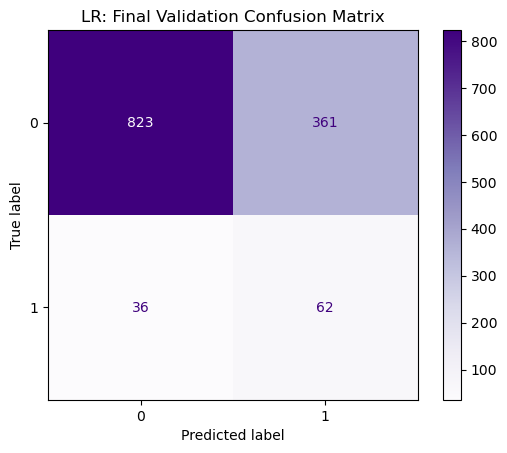

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_val = logreg_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Validation Confusion Matrix")
plt.show()

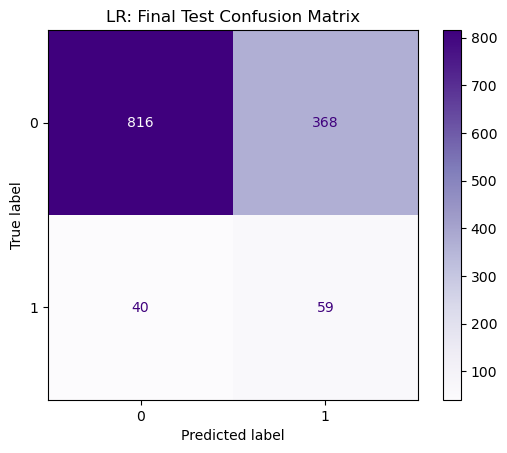

In [ ]:
y_pred_test = logreg_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("LR: Final Test Confusion Matrix")
plt.show()

<b> Random Forest </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
target_col = "AKI"

# This grabs every single column in your dataframe except the target
features_list = [col for col in df_final.columns if col != target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=4, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("RF (VAL)")
print(classification_report(y_val, rf_pipe.predict(X_val)))

RF (VAL)
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1184
           1       0.12      0.10      0.11        98

    accuracy                           0.88      1282
   macro avg       0.53      0.52      0.52      1282
weighted avg       0.87      0.88      0.87      1282



In [ ]:
from sklearn.metrics import classification_report

print("RF(TEST)")
print(classification_report(y_test, rf_pipe.predict(X_test)))

RF(TEST)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1184
           1       0.18      0.16      0.17        99

    accuracy                           0.88      1283
   macro avg       0.56      0.55      0.55      1283
weighted avg       0.87      0.88      0.88      1283



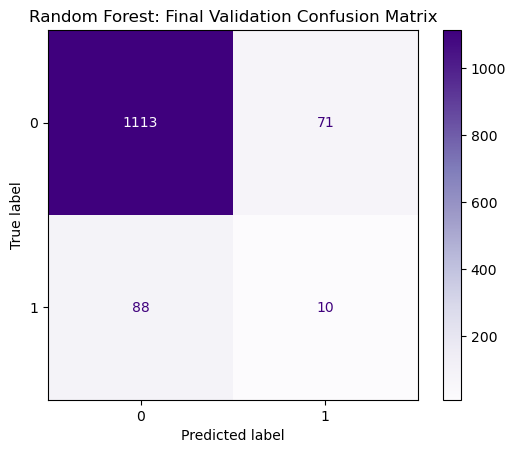

In [ ]:
y_pred_val = rf_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Validation Confusion Matrix")
plt.show()

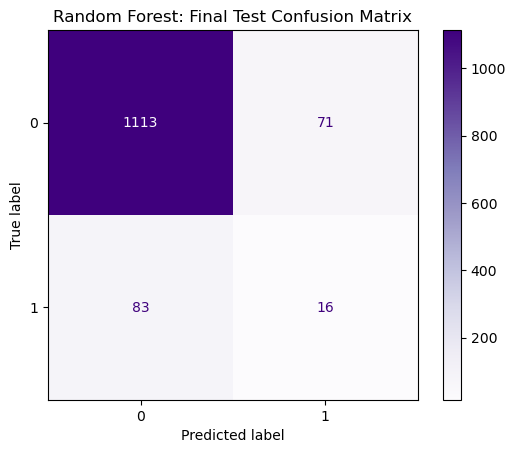

In [ ]:
y_pred_test = rf_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Random Forest: Final Test Confusion Matrix")
plt.show()

<b> Decision Tree </b>

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    # Encode categories (1, 2, 3) as numbers for the tree logic
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("dt", DecisionTreeClassifier(
        criterion="gini",          # Or "entropy" to measure information gain
        max_depth=5,               # Keep it shallow so you can read the rules
        min_samples_leaf=10,       # Prevents the tree from creating a rule for 1-2 patients
        class_weight="balanced",   # CRITICAL: Fixes the 0.02 recall issue
        random_state=42
    ))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import classification_report

print("DT (VAL)")
print(classification_report(y_val, dt_pipe.predict(X_val)))

DT (VAL)
              precision    recall  f1-score   support

           0       0.96      0.76      0.84      1184
           1       0.16      0.58      0.26        98

    accuracy                           0.74      1282
   macro avg       0.56      0.67      0.55      1282
weighted avg       0.90      0.74      0.80      1282



In [ ]:
from sklearn.metrics import classification_report

print("DT (TEST)")
print(classification_report(y_test, dt_pipe.predict(X_test)))

DT (TEST)
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      1184
           1       0.15      0.48      0.22        99

    accuracy                           0.74      1283
   macro avg       0.55      0.62      0.53      1283
weighted avg       0.88      0.74      0.80      1283



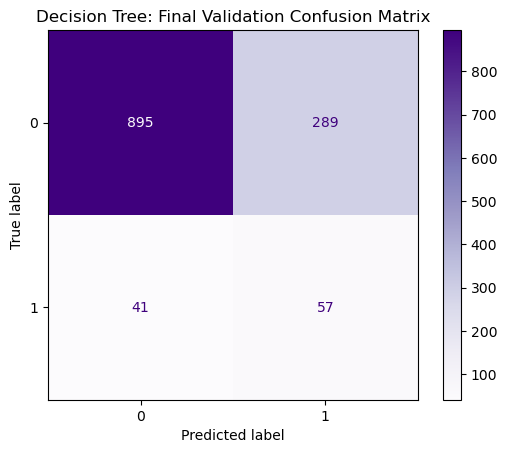

In [ ]:
y_pred_val = dt_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Validation Confusion Matrix")
plt.show()

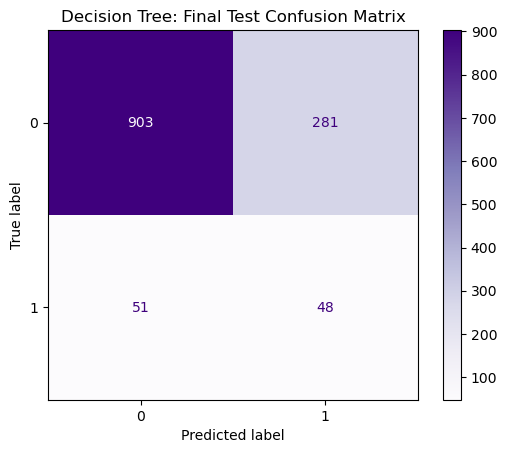

In [ ]:
y_pred_test = dt_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Decision Tree: Final Test Confusion Matrix")
plt.show()

<b> Gradient Boosting </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Height (m)','Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 10 features
Final Numerical List: 3 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Identify which columns need encoding (the cat_features we found earlier)
# Ensure these match your "cleaned" column names (lt_, gt_)
cat_features = [col for col in X_train.columns if X_train[col].dtype == 'category' or X_train[col].dtype == 'object']

gb_pipe = Pipeline([
    # Encode clinical categories (1, 2, 3) so GBM can read them
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,         # Increased slightly to capture medical complexity
        subsample=0.8,       # Helps prevent overfitting
        random_state=42
    ))
])

# Calculate weights to force the model to care about Moderate/Severe classes
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit the pipeline using the weights
# Note: 'model__' prefix tells the pipeline to pass weights to the GBM stage
gb_pipe.fit(X_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, gb_pipe.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.95      0.78      0.85      1184
           1       0.16      0.50      0.24        98

    accuracy                           0.76      1282
   macro avg       0.55      0.64      0.55      1282
weighted avg       0.89      0.76      0.81      1282



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, gb_pipe.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.94      0.78      0.86      1184
           1       0.14      0.42      0.21        99

    accuracy                           0.76      1283
   macro avg       0.54      0.60      0.53      1283
weighted avg       0.88      0.76      0.81      1283



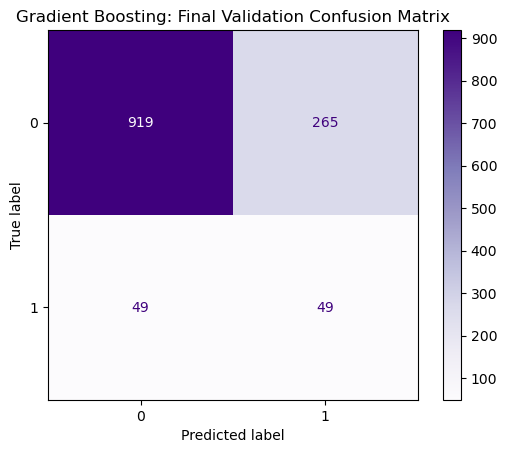

In [ ]:
y_pred_val = gb_pipe.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Validation Confusion Matrix")
plt.show()

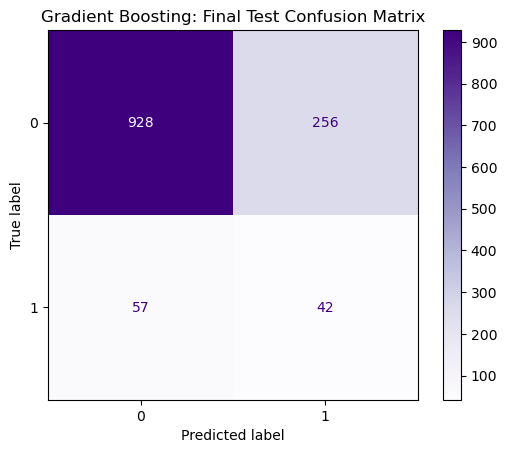

In [ ]:
y_pred_test = gb_pipe.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("Gradient Boosting: Final Test Confusion Matrix")
plt.show()

<b> XGB </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Height (m)','Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 10 features
Final Numerical List: 3 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Calculate weights for each row in the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the XGBoost Classifier for BINARY tasks
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',  # Changed for Binary Logic
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

# 3. Fit with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

print("GB (VAL)")
print(classification_report(y_val, xgb_model.predict(X_val)))

GB (VAL)
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1184
           1       0.18      0.22      0.20        98

    accuracy                           0.86      1282
   macro avg       0.56      0.57      0.56      1282
weighted avg       0.88      0.86      0.87      1282



In [ ]:
from sklearn.metrics import classification_report

print("GB (TEST)")
print(classification_report(y_test, xgb_model.predict(X_test)))

GB (TEST)
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1184
           1       0.14      0.16      0.15        99

    accuracy                           0.86      1283
   macro avg       0.53      0.54      0.53      1283
weighted avg       0.87      0.86      0.86      1283



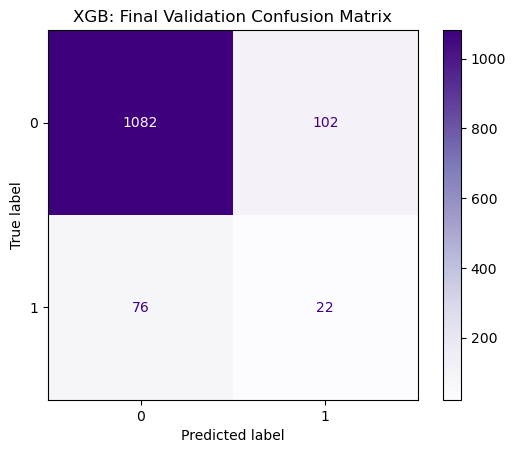

In [ ]:
y_pred_val = xgb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Validation Confusion Matrix")
plt.show()

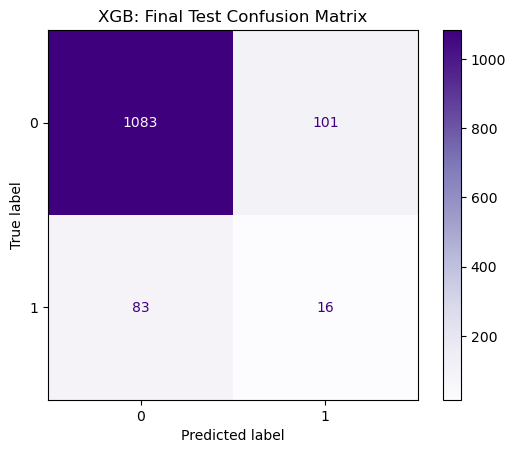

In [ ]:
y_pred_test = xgb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("XGB: Final Test Confusion Matrix")
plt.show()

<b> CatBoost </b>

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_finalv1 = clean_column_names(df_final)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_finalv1['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_finalv1.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Height (m)','Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 10 features
Final Numerical List: 3 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6699273	best: 0.6699273 (0)	total: 155ms	remaining: 2m 35s
100:	test: 0.7245113	best: 0.7280061 (59)	total: 15.5s	remaining: 2m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7280060673
bestIteration = 59

Shrink model to first 60 iterations.


In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.96      0.72      0.83      1184
           1       0.16      0.63      0.25        98

    accuracy                           0.72      1282
   macro avg       0.56      0.68      0.54      1282
weighted avg       0.90      0.72      0.78      1282



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      1184
           1       0.14      0.56      0.23        99

    accuracy                           0.71      1283
   macro avg       0.55      0.64      0.52      1283
weighted avg       0.89      0.71      0.77      1283



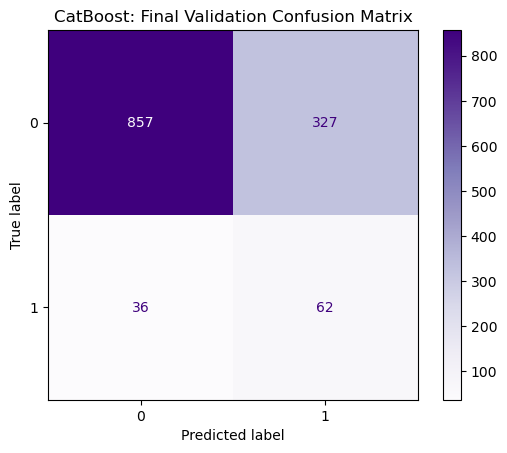

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

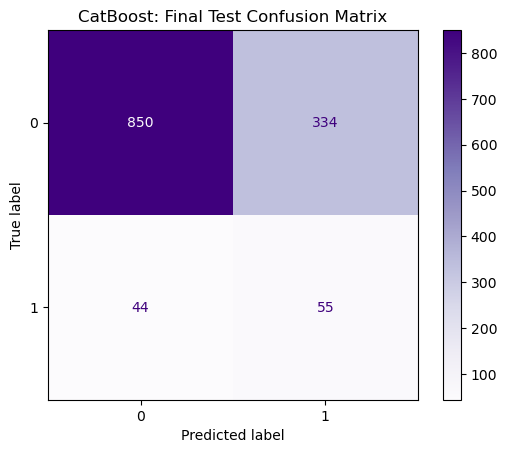

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

## Patients aged ≥ 60 with kidney disease

In [ ]:
df_new = df.loc[df['Age'] >= 60]

In [ ]:
df_new.shape

(16555, 230)

In [ ]:
df_new = df_new[df_new['Elevated Cr or CKD before scan 0N1Y'] == 1]

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4238 entries, 2 to 25294
Columns: 230 entries, RecordNo. to Baseline Cr ltet350_1
dtypes: float64(27), int64(131), object(72)
memory usage: 7.5+ MB


### Feature Selection & Dimensionality Reduction

In [ ]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",

    "Elevated Cr or CKD before scan 0N1Y"
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [ ]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean your remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_new.columns))
print("Not found in df_new.columns:", missing)

Not found in df_new.columns: []


In [ ]:
df_new = df_new.drop(columns=remove_columns, errors="ignore")

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4238 entries, 2 to 25294
Data columns (total 33 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              4238 non-null   int64  
 1   Patient Ethnicity Code                                           4238 non-null   int64  
 2   Patient Gender                                                   4238 non-null   int64  
 3   Weight                                                           3749 non-null   float64
 4   Height (m)                                                       3114 non-null   float64
 5   BMI                                                              3114 non-null   float64
 6   Procedure_code                                                   4238 non-null   int64  
 7   Contrast type_code                            

In [ ]:
df_new['AKI'].value_counts()

AKI
0    3686
1     552
Name: count, dtype: int64

### Preprocesing Data

In [ ]:
df_new.duplicated().sum()

3

In [ ]:
df_new = df_new.drop_duplicates()

In [ ]:
df_new.shape

(4235, 33)

In [ ]:
df_new.isnull().sum()

Age                                                                   0
Patient Ethnicity Code                                                0
Patient Gender                                                        0
Weight                                                              486
Height (m)                                                         1121
BMI                                                                1121
Procedure_code                                                        0
Contrast type_code                                                    0
Volume Vial                                                           0
Patient Type 1inpt 2OutptDaysx 3Emer                                  0
DM code, no DM-0, DM-1                                                0
HTN code, no HTN-0, HTN-1                                             0
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1       0
History of Ca                                                   

In [ ]:
from sklearn.impute import SimpleImputer

cols = ['Height (m)', 'Weight', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4235 entries, 2 to 25294
Data columns (total 33 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              4235 non-null   int64  
 1   Patient Ethnicity Code                                           4235 non-null   int64  
 2   Patient Gender                                                   4235 non-null   int64  
 3   Weight                                                           4235 non-null   float64
 4   Height (m)                                                       4235 non-null   float64
 5   BMI                                                              4235 non-null   float64
 6   Procedure_code                                                   4235 non-null   int64  
 7   Contrast type_code                            

In [ ]:
df_new['AKI'].value_counts()

AKI
0    3683
1     552
Name: count, dtype: int64

### Model Development Evaluation

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 26 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6148715	best: 0.6148715 (0)	total: 82.8ms	remaining: 1m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6956521739
bestIteration = 22

Shrink model to first 23 iterations.


Missing NaN values? --> Symmetric Tree Splitting

1. The "Branching" Decision

For every feature that has missing values, CatBoost tests two scenarios at every split in the decision tree:

Scenario A: Put all NaN values into the Left branch (with the smaller numbers).

Scenario B: Put all NaN values into the Right branch (with the larger numbers).

It chooses whichever option results in the lowest error for your AKI prediction. This allows the model to learn that "Missing" might actually be a strong signal for a specific outcome.

In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.92      0.66      0.77       368
           1       0.21      0.60      0.31        55

    accuracy                           0.65       423
   macro avg       0.56      0.63      0.54       423
weighted avg       0.82      0.65      0.71       423



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.91      0.63      0.75       369
           1       0.19      0.58      0.29        55

    accuracy                           0.63       424
   macro avg       0.55      0.61      0.52       424
weighted avg       0.82      0.63      0.69       424



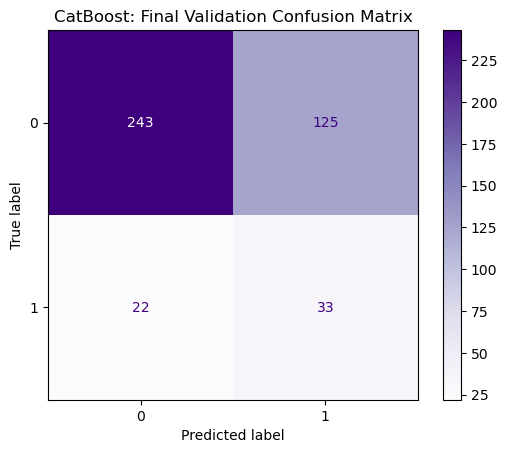

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

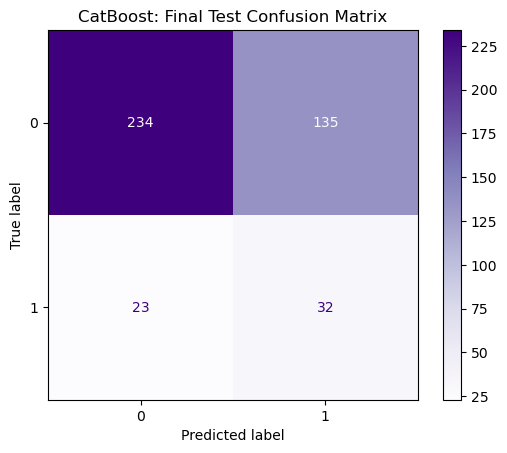

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Prepare a copy to avoid modifying original data
df_imputed = df_new.copy()

# 2. Define column groups
continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

# 3. Apply Imputation ONLY to Continuous Columns
# This replaces NaN with the Median, but ignores 'nd9' in categorical columns
cont_imputer = SimpleImputer(strategy='median')
df_imputed[continuous_cols] = cont_imputer.fit_transform(df_imputed[continuous_cols])

# 4. Prepare X and y
X = df_imputed.drop(columns=['AKI'])
y = df_imputed['AKI']

# 5. Update Discrete Mask based on X columns
# This tells MI which columns are labels (Categorical)
discrete_mask = [col not in continuous_cols for col in X.columns]

# 6. Calculate MI Scores
mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 7. Rank MI Results
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

# 8. Rank Correlation Results
correlations = X.corrwith(y).abs()
corr_results = pd.DataFrame({
    'Feature': X.columns,
    'Absolute Correlation': correlations.values
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

# --- Results ---
print("--- MI RESULTS (Imputed Continuous, Original Categorical) ---")
print(mi_results)
print('\n')
print("--- Corr RESULTS (Imputed Continuous, Original Categorical) ---")
print(corr_results)

--- MI RESULTS (Imputed Continuous, Original Categorical) ---
                                              Feature  MI Score
0   Cardiovascular disease (PVD or IHD or CVA): Ab...  0.007898
1                                                 Age  0.007094
2                                         Volume Vial  0.006042
3                                                 BMI  0.005889
4                                          Height (m)  0.005711
5   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.004259
6                              DM code, no DM-0, DM-1  0.004178
7   Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.003688
8                                  ProBNPmt300_1, nd9  0.003461
9                              Patient Ethnicity Code  0.001478
10                          HTN code, no HTN-0, HTN-1  0.001414
11   Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)  0.001172
12  HCT low=2, normal=1, high= 3, nd-9 (normal 38-...  0.001165
13                                     Pro

## Patients aged ≥ 60 with kidney disease but without diabetes

In [ ]:
df_new = df.loc[df['Age'] >= 60]

In [ ]:
df_new.shape

(16555, 230)

In [ ]:
df_new = df_new[df_new['Elevated Cr or CKD before scan 0N1Y'] == 1]

In [ ]:
df_new.shape

(4238, 230)

In [ ]:
df_new = df_new[df_new['DM code, no DM-0, DM-1'] == 0]

In [ ]:
df_new.shape

(2343, 230)

### Feature Selection & Dimensionality Reduction

In [ ]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",

    "Elevated Cr or CKD before scan 0N1Y", "DM code, no DM-0, DM-1"
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [ ]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean your remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_new.columns))
print("Not found in df_new.columns:", missing)

Not found in df_new.columns: []


In [ ]:
df_new = df_new.drop(columns=remove_columns, errors="ignore")

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2343 entries, 2 to 25294
Data columns (total 32 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              2343 non-null   int64  
 1   Patient Ethnicity Code                                           2343 non-null   int64  
 2   Patient Gender                                                   2343 non-null   int64  
 3   Weight                                                           1973 non-null   float64
 4   Height (m)                                                       1590 non-null   float64
 5   BMI                                                              1590 non-null   float64
 6   Procedure_code                                                   2343 non-null   int64  
 7   Contrast type_code                            

In [ ]:
df_new['AKI'].value_counts()

AKI
0    2103
1     240
Name: count, dtype: int64

### Preprocessing Data

In [ ]:
df_new.duplicated().sum()

3

In [ ]:
df_new = df_new.drop_duplicates()

In [ ]:
df_new.shape

(2340, 32)

In [ ]:
df_new.isnull().sum()

Age                                                                  0
Patient Ethnicity Code                                               0
Patient Gender                                                       0
Weight                                                             367
Height (m)                                                         750
BMI                                                                750
Procedure_code                                                       0
Contrast type_code                                                   0
Volume Vial                                                          0
Patient Type 1inpt 2OutptDaysx 3Emer                                 0
HTN code, no HTN-0, HTN-1                                            0
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1      0
History of Ca                                                        0
Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)                0
HCT lo

In [ ]:
df_new['AKI'].value_counts()

AKI
0    2100
1     240
Name: count, dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer

cols = ['Height (m)', 'Weight', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2340 entries, 2 to 25294
Data columns (total 32 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              2340 non-null   int64  
 1   Patient Ethnicity Code                                           2340 non-null   int64  
 2   Patient Gender                                                   2340 non-null   int64  
 3   Weight                                                           2340 non-null   float64
 4   Height (m)                                                       2340 non-null   float64
 5   BMI                                                              2340 non-null   float64
 6   Procedure_code                                                   2340 non-null   int64  
 7   Contrast type_code                            

### Model Development and Evaluation

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 25 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.3936508	best: 0.3936508 (0)	total: 47.1ms	remaining: 47.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5209325397
bestIteration = 8

Shrink model to first 9 iterations.


In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.90      0.55      0.68       210
           1       0.10      0.46      0.17        24

    accuracy                           0.54       234
   macro avg       0.50      0.51      0.43       234
weighted avg       0.82      0.54      0.63       234



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.92      0.56      0.70       210
           1       0.13      0.58      0.22        24

    accuracy                           0.56       234
   macro avg       0.53      0.57      0.46       234
weighted avg       0.84      0.56      0.65       234



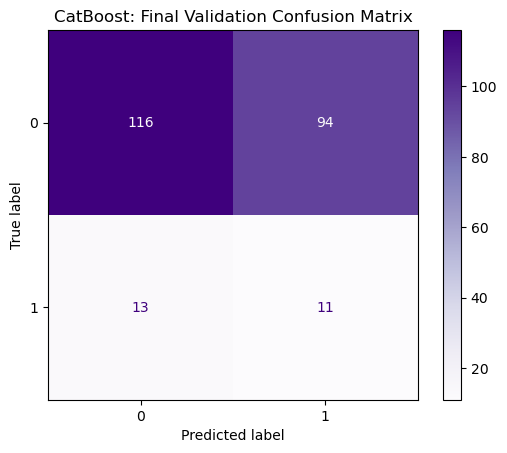

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

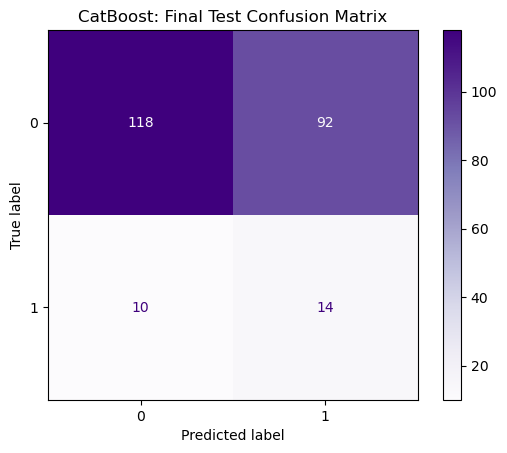

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Prepare a copy to avoid modifying original data
df_imputed = df_new.copy()

# 2. Define column groups
continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

# 3. Apply Imputation ONLY to Continuous Columns
# This replaces NaN with the Median, but ignores 'nd9' in categorical columns
cont_imputer = SimpleImputer(strategy='median')
df_imputed[continuous_cols] = cont_imputer.fit_transform(df_imputed[continuous_cols])

# 4. Prepare X and y
X = df_imputed.drop(columns=['AKI'])
y = df_imputed['AKI']

# 5. Update Discrete Mask based on X columns
# This tells MI which columns are labels (Categorical)
discrete_mask = [col not in continuous_cols for col in X.columns]

# 6. Calculate MI Scores
mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 7. Rank MI Results
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

# 8. Rank Correlation Results
correlations = X.corrwith(y).abs()
corr_results = pd.DataFrame({
    'Feature': X.columns,
    'Absolute Correlation': correlations.values
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

# --- Results ---
print("--- MI RESULTS (Imputed Continuous, Original Categorical) ---")
print(mi_results)
print('\n')
print("--- Corr RESULTS (Imputed Continuous, Original Categorical) ---")
print(corr_results)

--- MI RESULTS (Imputed Continuous, Original Categorical) ---
                                              Feature  MI Score
0                                                 Age  0.012327
1                                          Height (m)  0.011605
2   Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.005130
3   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.003227
4                                      Procedure_code  0.002269
5                Patient Type 1inpt 2OutptDaysx 3Emer  0.002246
6   Cardiovascular disease (PVD or IHD or CVA): Ab...  0.002023
7                            High Thyroxine gt_14.4_1  0.001914
8                Proteinuria lt_=0.5=1, gt_0.5=2, nd9  0.001903
9          Glucose_code: lt_4_2, 4-11_1, gt_11_3, nd9  0.001644
10                         High Lactate- No: 0, Yes:1  0.001264
11   Acidbase pH (lt_7.35=1, Normal2, gt_7.45=3, nd9)  0.001224
12                  Hypoalbuminemia No-0, Yes-1, nd-9  0.001127
13                                 ProBNPm

## Patients aged ≥ 60 with both kidney disease and diabetes

In [ ]:
df_new = df.loc[df['Age'] >= 60]

In [ ]:
df_new.shape

(16555, 230)

In [ ]:
df_new = df_new[df_new['Elevated Cr or CKD before scan 0N1Y'] == 1]

In [ ]:
df_new.shape

(4238, 230)

In [ ]:
df_new = df_new[df_new['DM code, no DM-0, DM-1'] == 1]

In [ ]:
df_new.shape

(1895, 230)

### Feature Selection & Dimensionality Reduction

In [ ]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",

    'Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1'
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [ ]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean your remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_new.columns))
print("Not found in df_new.columns:", missing)

Not found in df_new.columns: []


In [ ]:
df_new = df_new.drop(columns=remove_columns, errors="ignore")

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1895 entries, 10 to 25283
Data columns (total 32 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              1895 non-null   int64  
 1   Patient Ethnicity Code                                           1895 non-null   int64  
 2   Patient Gender                                                   1895 non-null   int64  
 3   Weight                                                           1776 non-null   float64
 4   Height (m)                                                       1524 non-null   float64
 5   BMI                                                              1524 non-null   float64
 6   Procedure_code                                                   1895 non-null   int64  
 7   Contrast type_code                           

### Preprocessing Data

In [ ]:
df_new.duplicated().sum()

0

In [ ]:
df_new = df_new.drop_duplicates()

In [ ]:
df_new.shape

(1895, 32)

In [ ]:
df_new.isnull().sum()

Age                                                                  0
Patient Ethnicity Code                                               0
Patient Gender                                                       0
Weight                                                             119
Height (m)                                                         371
BMI                                                                371
Procedure_code                                                       0
Contrast type_code                                                   0
Volume Vial                                                          0
Patient Type 1inpt 2OutptDaysx 3Emer                                 0
HTN code, no HTN-0, HTN-1                                            0
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1      0
History of Ca                                                        0
Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)                0
HCT lo

In [ ]:
df_new['AKI'].value_counts()

AKI
0    1583
1     312
Name: count, dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer

cols = ['Height (m)', 'Weight', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1895 entries, 10 to 25283
Data columns (total 32 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              1895 non-null   int64  
 1   Patient Ethnicity Code                                           1895 non-null   int64  
 2   Patient Gender                                                   1895 non-null   int64  
 3   Weight                                                           1895 non-null   float64
 4   Height (m)                                                       1895 non-null   float64
 5   BMI                                                              1895 non-null   float64
 6   Procedure_code                                                   1895 non-null   int64  
 7   Contrast type_code                           

### Model Development and Evaluation

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 25 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.5658432	best: 0.5658432 (0)	total: 73ms	remaining: 1m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6451612903
bestIteration = 16

Shrink model to first 17 iterations.


In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.89      0.57      0.69       158
           1       0.23      0.65      0.34        31

    accuracy                           0.58       189
   macro avg       0.56      0.61      0.52       189
weighted avg       0.78      0.58      0.64       189



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.94      0.57      0.71       159
           1       0.27      0.81      0.40        31

    accuracy                           0.61       190
   macro avg       0.60      0.69      0.56       190
weighted avg       0.83      0.61      0.66       190



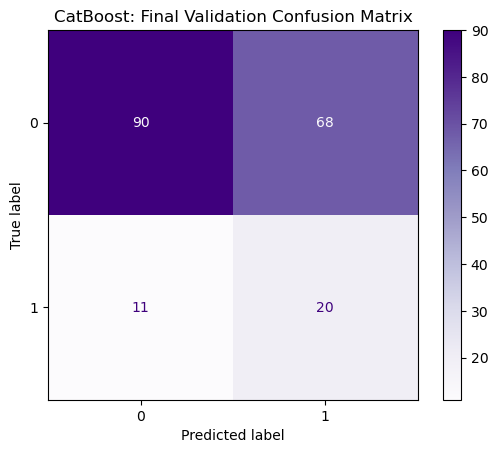

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

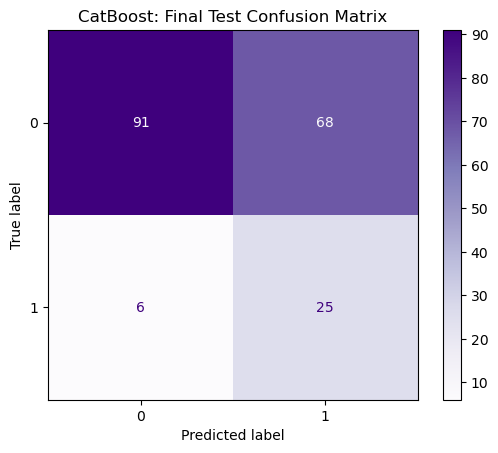

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Prepare a copy to avoid modifying original data
df_imputed = df_new.copy()

# 2. Define column groups
continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

# 3. Apply Imputation ONLY to Continuous Columns
# This replaces NaN with the Median, but ignores 'nd9' in categorical columns
cont_imputer = SimpleImputer(strategy='median')
df_imputed[continuous_cols] = cont_imputer.fit_transform(df_imputed[continuous_cols])

# 4. Prepare X and y
X = df_imputed.drop(columns=['AKI'])
y = df_imputed['AKI']

# 5. Update Discrete Mask based on X columns
# This tells MI which columns are labels (Categorical)
discrete_mask = [col not in continuous_cols for col in X.columns]

# 6. Calculate MI Scores
mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 7. Rank MI Results
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

# 8. Rank Correlation Results
correlations = X.corrwith(y).abs()
corr_results = pd.DataFrame({
    'Feature': X.columns,
    'Absolute Correlation': correlations.values
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

# --- Results ---
print("--- MI RESULTS (Imputed Continuous, Original Categorical) ---")
print(mi_results)
print('\n')
print("--- Corr RESULTS (Imputed Continuous, Original Categorical) ---")
print(corr_results)

--- MI RESULTS (Imputed Continuous, Original Categorical) ---
                                              Feature  MI Score
0   Cardiovascular disease (PVD or IHD or CVA): Ab...  0.012579
1                                              Weight  0.008805
2                                  ProBNPmt300_1, nd9  0.007786
3   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.007533
4                                          Height (m)  0.002802
5                                              SGLT2i  0.002760
6   Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.001739
7                            High Thyroxine gt_14.4_1  0.001341
8                Proteinuria lt_=0.5=1, gt_0.5=2, nd9  0.001197
9                              Patient Ethnicity Code  0.001174
10  HCT low=2, normal=1, high= 3, nd-9 (normal 38-...  0.001170
11                                      History of Ca  0.001143
12                         CRP lt_=10=1, gt_10=2, nd9  0.001049
13            WBC notdone9, 4-10=1, lt_4.0

## Patients aged ≥ 60 with Diabetes

In [ ]:
df_new = df.loc[df['Age'] >= 60]

In [ ]:
df_new.shape

(16555, 230)

In [ ]:
df_new = df_new[df_new['DM code, no DM-0, DM-1'] == 1]

In [ ]:
df_new.shape

(5317, 230)

### Feature Selection & Dimensionality Reduction

In [ ]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",

    "DM code, no DM-0, DM-1"
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [ ]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean your remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_new.columns))
print("Not found in df_new.columns:", missing)

Not found in df_new.columns: []


In [ ]:
df_new = df_new.drop(columns=remove_columns, errors="ignore")

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5317 entries, 0 to 25289
Data columns (total 33 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              5317 non-null   int64  
 1   Patient Ethnicity Code                                           5317 non-null   int64  
 2   Patient Gender                                                   5317 non-null   int64  
 3   Weight                                                           4768 non-null   float64
 4   Height (m)                                                       4055 non-null   float64
 5   BMI                                                              4055 non-null   float64
 6   Procedure_code                                                   5317 non-null   int64  
 7   Contrast type_code                            

### Preprocessing Data

In [ ]:
df_new.duplicated().sum()

1

In [ ]:
df_new = df_new.drop_duplicates()

In [ ]:
df_new.shape

(5316, 33)

In [ ]:
df_new.isnull().sum()

Age                                                                   0
Patient Ethnicity Code                                                0
Patient Gender                                                        0
Weight                                                              548
Height (m)                                                         1261
BMI                                                                1261
Procedure_code                                                        0
Contrast type_code                                                    0
Volume Vial                                                           0
Patient Type 1inpt 2OutptDaysx 3Emer                                  0
Elevated Cr or CKD before scan 0N1Y                                   0
HTN code, no HTN-0, HTN-1                                             0
Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1       0
History of Ca                                                   

In [ ]:
df_new['AKI'].value_counts()

AKI
0    4810
1     506
Name: count, dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer

cols = ['Height (m)', 'Weight', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5316 entries, 0 to 25289
Data columns (total 33 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              5316 non-null   int64  
 1   Patient Ethnicity Code                                           5316 non-null   int64  
 2   Patient Gender                                                   5316 non-null   int64  
 3   Weight                                                           5316 non-null   float64
 4   Height (m)                                                       5316 non-null   float64
 5   BMI                                                              5316 non-null   float64
 6   Procedure_code                                                   5316 non-null   int64  
 7   Contrast type_code                            

### Model Development and Evaluation

In [ ]:
# 1. Clean the column names in the main dataframe FIRST
def clean_column_names(df):
    df.columns = [str(col).replace('[', '_').replace(']', '_')
                           .replace('<', 'lt_').replace('>', 'gt_') 
                  for col in df.columns]
    return df

df_final = clean_column_names(df_new)

In [ ]:
#Set the variable 'y' to the target variable, which is the 'price' column
y = df_final['AKI']

#Set the variable 'X' to include the remaining predictor columns.
X = df_final.drop(columns=['AKI'])

In [ ]:
# 1. Start with the list you just generated
potential_cats = X.columns[X.dtypes != 'float64'].tolist()

# 2. Define the columns that are actually NUMBERS (even if they are integers)
# We want CatBoost to see the 'math' between Age 60 and 70.
continuous_features = ['Age', 'Calculated baseline creatinine', 'Weight', 'Height (m)', 'BMI', 'Volume Vial']

# 3. Final categorical list: anything in potential_cats that ISN'T a continuous number
cat_features = [col for col in potential_cats if col not in continuous_features]

# 4. Convert only the true categories to string
for col in cat_features:
    X[col] = X[col].astype(str)

print(f"Final Categorical List: {len(cat_features)} features")
print(f"Final Numerical List: {len(continuous_features)} features")

Final Categorical List: 26 features
Final Numerical List: 6 features


In [ ]:
# Convert your cat_features list to 'category' type
for col in cat_features:
    X[col] = X[col].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
from catboost import CatBoostClassifier

# Initialize the model for BINARY classification
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',       # Standard for binary classification
    auto_class_weights='Balanced', # Still CRITICAL for catching AKI cases
    eval_metric='AUC',             # AUC is excellent for binary medical evaluation
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50       # Prevents overfitting
)

# Fit the model
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True            # Ensures the final model is the one with highest F1
)

0:	test: 0.6887408	best: 0.6887408 (0)	total: 77.8ms	remaining: 1m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7489503078
bestIteration = 15

Shrink model to first 16 iterations.


In [ ]:
from sklearn.metrics import classification_report

print("CB (VAL)")
print(classification_report(y_val, cb_model.predict(X_val)))

CB (VAL)
              precision    recall  f1-score   support

           0       0.96      0.65      0.78       481
           1       0.19      0.76      0.30        51

    accuracy                           0.66       532
   macro avg       0.58      0.71      0.54       532
weighted avg       0.89      0.66      0.73       532



In [ ]:
from sklearn.metrics import classification_report

print("CB (TEST)")
print(classification_report(y_test, cb_model.predict(X_test)))

CB (TEST)
              precision    recall  f1-score   support

           0       0.96      0.66      0.78       482
           1       0.18      0.74      0.29        50

    accuracy                           0.67       532
   macro avg       0.57      0.70      0.54       532
weighted avg       0.89      0.67      0.74       532



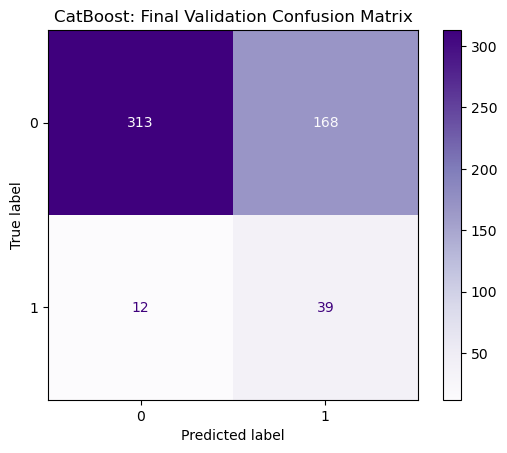

In [ ]:
y_pred_val = cb_model.predict(X_val)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_val, y_pred_val)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Validation Confusion Matrix")
plt.show()

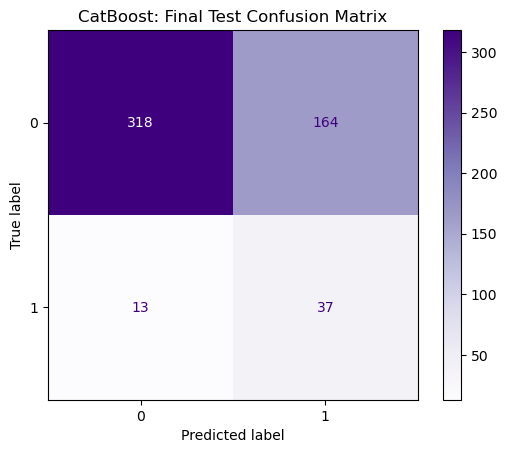

In [ ]:
y_pred_test = cb_model.predict(X_test)

# Confusion Matrix for Test Set
cm_rf = confusion_matrix(y_test, y_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title("CatBoost: Final Test Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Prepare a copy to avoid modifying original data
df_imputed = df_new.copy()

# 2. Define column groups
continuous_cols = ['Age', 'Weight', 'Height (m)', 'BMI', 'Volume Vial', 'Calculated baseline creatinine']

# 3. Apply Imputation ONLY to Continuous Columns
# This replaces NaN with the Median, but ignores 'nd9' in categorical columns
cont_imputer = SimpleImputer(strategy='median')
df_imputed[continuous_cols] = cont_imputer.fit_transform(df_imputed[continuous_cols])

# 4. Prepare X and y
X = df_imputed.drop(columns=['AKI'])
y = df_imputed['AKI']

# 5. Update Discrete Mask based on X columns
# This tells MI which columns are labels (Categorical)
discrete_mask = [col not in continuous_cols for col in X.columns]

# 6. Calculate MI Scores
mi_scores = mutual_info_classif(
    X, y, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 7. Rank MI Results
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

# 8. Rank Correlation Results
correlations = X.corrwith(y).abs()
corr_results = pd.DataFrame({
    'Feature': X.columns,
    'Absolute Correlation': correlations.values
}).sort_values(by='Absolute Correlation', ascending=False).reset_index(drop=True)

# --- Results ---
print("--- MI RESULTS (Imputed Continuous, Original Categorical) ---")
print(mi_results)
print('\n')
print("--- Corr RESULTS (Imputed Continuous, Original Categorical) ---")
print(corr_results)

--- MI RESULTS (Imputed Continuous, Original Categorical) ---
                                              Feature  MI Score
0                 Elevated Cr or CKD before scan 0N1Y  0.014756
1                                  ProBNPmt300_1, nd9  0.010139
2   Cardiovascular disease (PVD or IHD or CVA): Ab...  0.008113
3                                              Weight  0.008048
4   Procal_code (Grp 1-4: lt_0.5, 0.5-lt_2, 2-lt_1...  0.004396
5                                         Volume Vial  0.003970
6   Hb notdone9, 11.5-17=1, lt_8=2, 8-lt_11.5=3, g...  0.003351
7                Proteinuria lt_=0.5=1, gt_0.5=2, nd9  0.002559
8                              Patient Ethnicity Code  0.002178
9                                           Diuretics  0.002000
10  HCT low=2, normal=1, high= 3, nd-9 (normal 38-...  0.001878
11                  Hypoalbuminemia No-0, Yes-1, nd-9  0.001821
12                                     Procedure_code  0.001731
13                                 Contras